In [ ]:
# ===== Core Dependencies: Deep Learning, HuggingFace, Image Processing =====
!pip install torch torchvision
!pip install transformers pillow tqdm

# For compatibility with Keras 3 (recommended to avoid issues encountered previously)
!pip install tf-keras

In [ ]:
import numpy as np
import pandas as pd

class CustomSOM:
    """Custom Self-Organizing Map implementation for semantic clustering"""
    
    def __init__(self, x_size, y_size, input_dim, lr=0.5):
        self.x_size = x_size
        self.y_size = y_size
        # Random weight initialization
        self.weights = np.random.rand(x_size, y_size, input_dim)
        self.lr = lr
        self.qe_history = []
        self.te_history = []
        self.u_matrices = {}

    def _get_bmu_idx(self, x):
        """Find Best Matching Unit (BMU) index"""
        dist = np.linalg.norm(self.weights - x, axis=2)
        return np.unravel_index(np.argmin(dist), (self.x_size, self.y_size))

    def _calculate_errors(self, data):
        """Calculate Quantization Error (QE) and Topological Error (TE)"""
        qe, te = 0, 0
        for x in data:
            dist = np.linalg.norm(self.weights - x, axis=2)
            flat_dist = dist.flatten()
            indices = np.argsort(flat_dist)
            qe += flat_dist[indices[0]] # Minimum distance is QE
            bmu1 = np.unravel_index(indices[0], (self.x_size, self.y_size))
            bmu2 = np.unravel_index(indices[1], (self.x_size, self.y_size))
            # If first and second BMU are not adjacent, increase topological error
            if abs(bmu1[0]-bmu2[0]) > 1 or abs(bmu1[1]-bmu2[1]) > 1:
                te += 1
        return qe / len(data), te / len(data)

    def _get_u_matrix(self):
        """Calculate Unified Distance Matrix (U-matrix)"""
        u_matrix = np.zeros((self.x_size, self.y_size))
        for x in range(self.x_size):
            for y in range(self.y_size):
                neighbors = []
                for dx in [-1, 0, 1]:
                    for dy in [-1, 0, 1]:
                        if dx == 0 and dy == 0: continue
                        nx, ny = x + dx, y + dy
                        if 0 <= nx < self.x_size and 0 <= ny < self.y_size:
                            neighbors.append(self.weights[nx, ny])
                u_matrix[x, y] = np.mean([np.linalg.norm(self.weights[x, y] - n) for n in neighbors])
        return u_matrix

    def train(self, data, epochs, record_interval=1):
        """Train SOM with learning rate and neighborhood radius decay"""
        for epoch in range(1, epochs + 1):
            # Learning rate and neighborhood radius decay over time
            curr_lr = self.lr * (1 - epoch / epochs)
            curr_sigma = max(self.x_size, self.y_size) / 2 * (1 - epoch / epochs)
            
            for x in data:
                bmu_idx = self._get_bmu_idx(x)
                grid_x, grid_y = np.indices((self.x_size, self.y_size))
                dist_sq = (grid_x - bmu_idx[0])**2 + (grid_y - bmu_idx[1])**2
                influence = np.exp(-dist_sq / (2 * (curr_sigma**2 + 1e-5)))
                self.weights += curr_lr * influence[:, :, np.newaxis] * (x - self.weights)
            
            qe, te = self._calculate_errors(data)
            self.qe_history.append(qe)
            self.te_history.append(te)
            
            if epoch % record_interval == 0:
                self.u_matrices[epoch] = self._get_u_matrix()
            
            if epoch % 5 == 0:
                print(f"Epoch {epoch}/{epochs} - QE: {qe:.4f}, TE: {te:.4f}")

In [ ]:
# ===== Freeze the Golden Moment =====
golden_epoch_windows = 11

# Extract weights from epoch 11 from history
som_windows_diag.best_weights = som_windows_diag.weights_history[golden_epoch_windows]

# Save model
with open('som_windows_epoch11_fixed.pkl', 'wb') as f:
    pickle.dump(som_windows_diag, f)

print(f"✅ Window City frozen at epoch {golden_epoch_windows}, model archived!")

✅ 窗户城已定格在第 11 轮，模型已封存！


In [ ]:
import os
print("Files are located in this directory:")
print(os.getcwd())

文件就在这个文件夹里：
c:\Users\asus\Desktop\RC11 TERM2


In [ ]:
# ===== Freeze at the Golden Epoch 15 =====
golden_epoch_other_final = 15

# Extract weights from epoch 15 from history
som_other.best_weights = som_other.weights_history[golden_epoch_other_final]

# Archive as final .pkl file
final_save_path = 'som_other_fragments_epoch15_fixed.pkl'
with open(final_save_path, 'wb') as f:
    pickle.dump(som_other, f)

print(f"✅ 【Other Fragment City】officially completed! Frozen at the most refined epoch {golden_epoch_other_final}.")
print(f"📦 Path: {final_save_path}")

✅ 【其他碎片城】正式竣工！已定格在最精细的第 15 轮。
📦 路径: som_other_fragments_epoch15_fixed.pkl


In [ ]:
# ===== Freeze the Golden Moment for the Last City =====
golden_epoch_desc = 13

# Extract weights from epoch 13 from history
som_desc.best_weights = som_desc.weights_history[golden_epoch_desc]

# Save model
save_path_desc = 'som_descriptions_epoch13_fixed.pkl'
with open(save_path_desc, 'wb') as f:
    pickle.dump(som_desc, f)

print(f"✅ 【Description City】completed! Golden moment: epoch {golden_epoch_desc}.")
print(f"📦 Path: {save_path_desc}")
print("\n🔥 Report! All six modality cities of Twin City have been frozen and archived.")

✅ 【描述城】定格完成！黄金时刻：第 13 轮。
📦 路径: som_descriptions_epoch13_fixed.pkl

🔥 报告！Twin City 六座模态城市已全部定格封存。


In [ ]:
import pickle
import numpy as np

def verify_som_epoch(file_path, target_epoch):
    """Verify if the saved SOM model is frozen at target epoch"""
    try:
        with open(file_path, 'rb') as f:
            som = pickle.load(f)
        
        # 1. Check if history exists
        if not hasattr(som, 'weights_history'):
            return f"❌ File {file_path} does not contain history records, unable to verify."
        
        # 2. Get current active weights (best_weights or weights)
        # We previously assigned selected epochs to som.best_weights
        current_weights = getattr(som, 'best_weights', som.weights)
        
        # 3. Get target epoch weights from history
        if target_epoch not in som.weights_history:
            return f"❌ No data for epoch {target_epoch} in history. Available epochs: {list(som.weights_history.keys())}"
        
        target_weights = som.weights_history[target_epoch]
        
        # 4. Compare if current and target are identical
        is_match = np.allclose(current_weights, target_weights)
        
        if is_match:
            return f"✅ Verification passed! {file_path} current weights 【ARE】 the state from epoch {target_epoch}."
        else:
            return f"⚠️ Verification failed! {file_path} current weights 【DO NOT MATCH】 epoch {target_epoch}, might be from epoch 30."
            
    except Exception as e:
        return f"❌ Error occurred: {e}"

# Execute verification
print(verify_som_epoch("som_streetview_30e_GoldenSelection.pkl", 19))
print(verify_som_epoch("som_text_30e_GoldenSelection.pkl", 24))

❌ 文件 som_streetview_30e_GoldenSelection.pkl 不包含历史记录，无法验证。
❌ 文件 som_text_30e_GoldenSelection.pkl 不包含历史记录，无法验证。


In [ ]:
import pickle

# ===== Step 1: Load file from disk into memory =====
file_path = 'som_streetview_30e_GoldenSelection.pkl'

try:
    with open(file_path, 'rb') as f:
        som_streetview = pickle.load(f)
    print(f"✅ File {file_path} successfully loaded!")
    
    # ===== Step 2: Check if history records exist =====
    if hasattr(som_streetview, 'weights_history') and len(som_streetview.weights_history) > 0:
        print("🟢 Great! File contains history records.")
        # Freeze at epoch 19
        som_streetview.best_weights = som_streetview.weights_history[19]
        # Overwrite save
        with open(file_path, 'wb') as f:
            pickle.dump(som_streetview, f)
        print("🚀 Rescue successful! This file is now locked at epoch 19.")
    else:
        print("🔴 Unfortunately: File loaded successfully, but no weights_history inside.")
        print("This means the CustomSOM class used during training was outdated without history recording.")
        print("You need to re-run the 30-epoch training.")

except FileNotFoundError:
    print(f"❌ File {file_path} not found. Please verify filename or path.")

✅ 文件 som_streetview_30e_GoldenSelection.pkl 已成功载入！
🔴 遗憾：文件载入成功，但里面没有 weights_history。
这说明你训练时用的 CustomSOM 类是旧版，没有记录功能。你需要重新运行那 30 轮训练。


In [ ]:
import numpy as np

class CustomSOM:
    """Custom Self-Organizing Map implementation with weight history tracking"""
    
    def __init__(self, x_size, y_size, input_dim, lr=0.5):
        self.x_size = x_size
        self.y_size = y_size
        self.weights = np.random.rand(x_size, y_size, input_dim)
        self.lr = lr
        self.qe_history = []
        self.te_history = []
        self.u_matrices = {}
        self.weights_history = {} # Key: historical record "ledger" for each epoch

    def _get_bmu_idx(self, x):
        """Find Best Matching Unit"""
        dist = np.linalg.norm(self.weights - x, axis=2)
        return np.unravel_index(np.argmin(dist), (self.x_size, self.y_size))

    def _calculate_errors(self, data):
        """Calculate Quantization and Topological Errors"""
        qe, te = 0, 0
        for x in data:
            dist = np.linalg.norm(self.weights - x, axis=2)
            flat_dist = dist.flatten()
            indices = np.argsort(flat_dist)
            qe += flat_dist[indices[0]]
            bmu1 = np.unravel_index(indices[0], (self.x_size, self.y_size))
            bmu2 = np.unravel_index(indices[1], (self.x_size, self.y_size))
            if abs(bmu1[0]-bmu2[0]) > 1 or abs(bmu1[1]-bmu2[1]) > 1:
                te += 1
        return qe / len(data), te / len(data)

    def _get_u_matrix(self):
        """Calculate Unified Distance Matrix"""
        u_matrix = np.zeros((self.x_size, self.y_size))
        for x in range(self.x_size):
            for y in range(self.y_size):
                neighbors = []
                for dx in [-1, 0, 1]:
                    for dy in [-1, 0, 1]:
                        if dx == 0 and dy == 0: continue
                        nx, ny = x + dx, y + dy
                        if 0 <= nx < self.x_size and 0 <= ny < self.y_size:
                            neighbors.append(self.weights[nx, ny])
                u_matrix[x, y] = np.mean([np.linalg.norm(self.weights[x, y] - n) for n in neighbors])
        return u_matrix

    def train(self, data, epochs, record_interval=1):
        """Train SOM with weight history recording"""
        for epoch in range(1, epochs + 1):
            curr_lr = self.lr * (1 - epoch / epochs)
            curr_sigma = max(self.x_size, self.y_size) / 2 * (1 - epoch / epochs)
            for x in data:
                bmu_idx = self._get_bmu_idx(x)
                grid_x, grid_y = np.indices((self.x_size, self.y_size))
                dist_sq = (grid_x - bmu_idx[0])**2 + (grid_y - bmu_idx[1])**2
                influence = np.exp(-dist_sq / (2 * (curr_sigma**2 + 1e-5)))
                self.weights += curr_lr * influence[:, :, np.newaxis] * (x - self.weights)
            
            qe, te = self._calculate_errors(data)
            self.qe_history.append(qe)
            self.te_history.append(te)
            self.u_matrices[epoch] = self._get_u_matrix()
            self.weights_history[epoch] = self.weights.copy() # Record into history
            if epoch % 5 == 0:
                print(f"Epoch {epoch}/{epochs} | QE: {qe:.4f} | TE: {te:.4f}")

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# Step 1: Execute 30-epoch full-record training
# ==========================================
total_epochs_text = 30
# Assume text vector dimension is 384 (SBERT)
# If variable name is not data_text, please modify to actual variable name
som_text_new = CustomSOM(x_size=15, y_size=15, input_dim=data_text.shape[1])

print(f"📚 Re-recording Text City (Novels) evolution panorama (1-30 Epochs)...")
som_text_new.train(data_text, epochs=total_epochs_text)

# ==========================================
# Step 2: Plot 30 evolution matrices in large grid (5x6)
# ==========================================
fig, axes = plt.subplots(5, 6, figsize=(24, 20))
axes = axes.flatten()

for i in range(total_epochs_text):
    epoch_num = i + 1
    u_mat = som_text_new.u_matrices[epoch_num]
    
    # Use YlGnBu colormap with Gaussian smoothing
    axes[i].imshow(u_mat, cmap='YlGnBu', interpolation='gaussian')
    axes[i].set_title(f"Epoch {epoch_num}", fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.94)
fig.suptitle("Text City (Novels) SOM: 30-Epoch Evolution Panorama", fontsize=26, fontweight='bold')
plt.show()

# ==========================================
# Step 3: Standby: prepare for frozen save
# ==========================================
print("💡 30-epoch evolution recording completed.")
print("👉 Please observe the figure and confirm whether epoch 24 is still the 'golden moment' in your mind.")
print("After confirmation, we will run the frozen save code.")

NameError: name 'data_text' is not defined

In [ ]:
# ===== Freeze Window Activity City at the refined epoch 22 =====
golden_epoch_win_act_v2 = 22

# Extract weights from epoch 22
som_win_act.best_weights = som_win_act.weights_history[golden_epoch_win_act_v2]

# Save model
save_path_win_act_v2 = 'som_windows_activity_epoch22_fixed.pkl'
with open(save_path_win_act_v2, 'wb') as f:
    pickle.dump(som_win_act, f)

print(f"✅ 【Window Activity City】refrozen at refined epoch {golden_epoch_win_act_v2}!")
print(f"📦 Path: {save_path_win_act_v2}")

✅ 【窗口活动城】已重新定格在精细版第 22 轮！
📦 路径: som_windows_activity_epoch22_fixed.pkl


In [ ]:
import pickle

# ===== Step 1: Select epoch 22 as final version =====
golden_epoch_street = 22

# ===== Step 2: Extract weights from history and override current weights =====
som_streetview_new.best_weights = som_streetview_new.weights_history[golden_epoch_street]

# ===== Step 3: Overwrite save to original file path =====
file_path_street = 'som_streetview_30e_GoldenSelection.pkl'
with open(file_path_street, 'wb') as f:
    pickle.dump(som_streetview_new, f)

print(f"✅ 【Street View City】officially frozen at epoch {golden_epoch_street}!")
print(f"📦 Golden edition master print archived at: {file_path_street}")

✅ 【街景城】已正式定格在第 22 轮！
📦 黄金版底片已存档至: som_streetview_30e_GoldenSelection.pkl


🎨 正在执行全城联觉映射 (独立维度自适应版)...


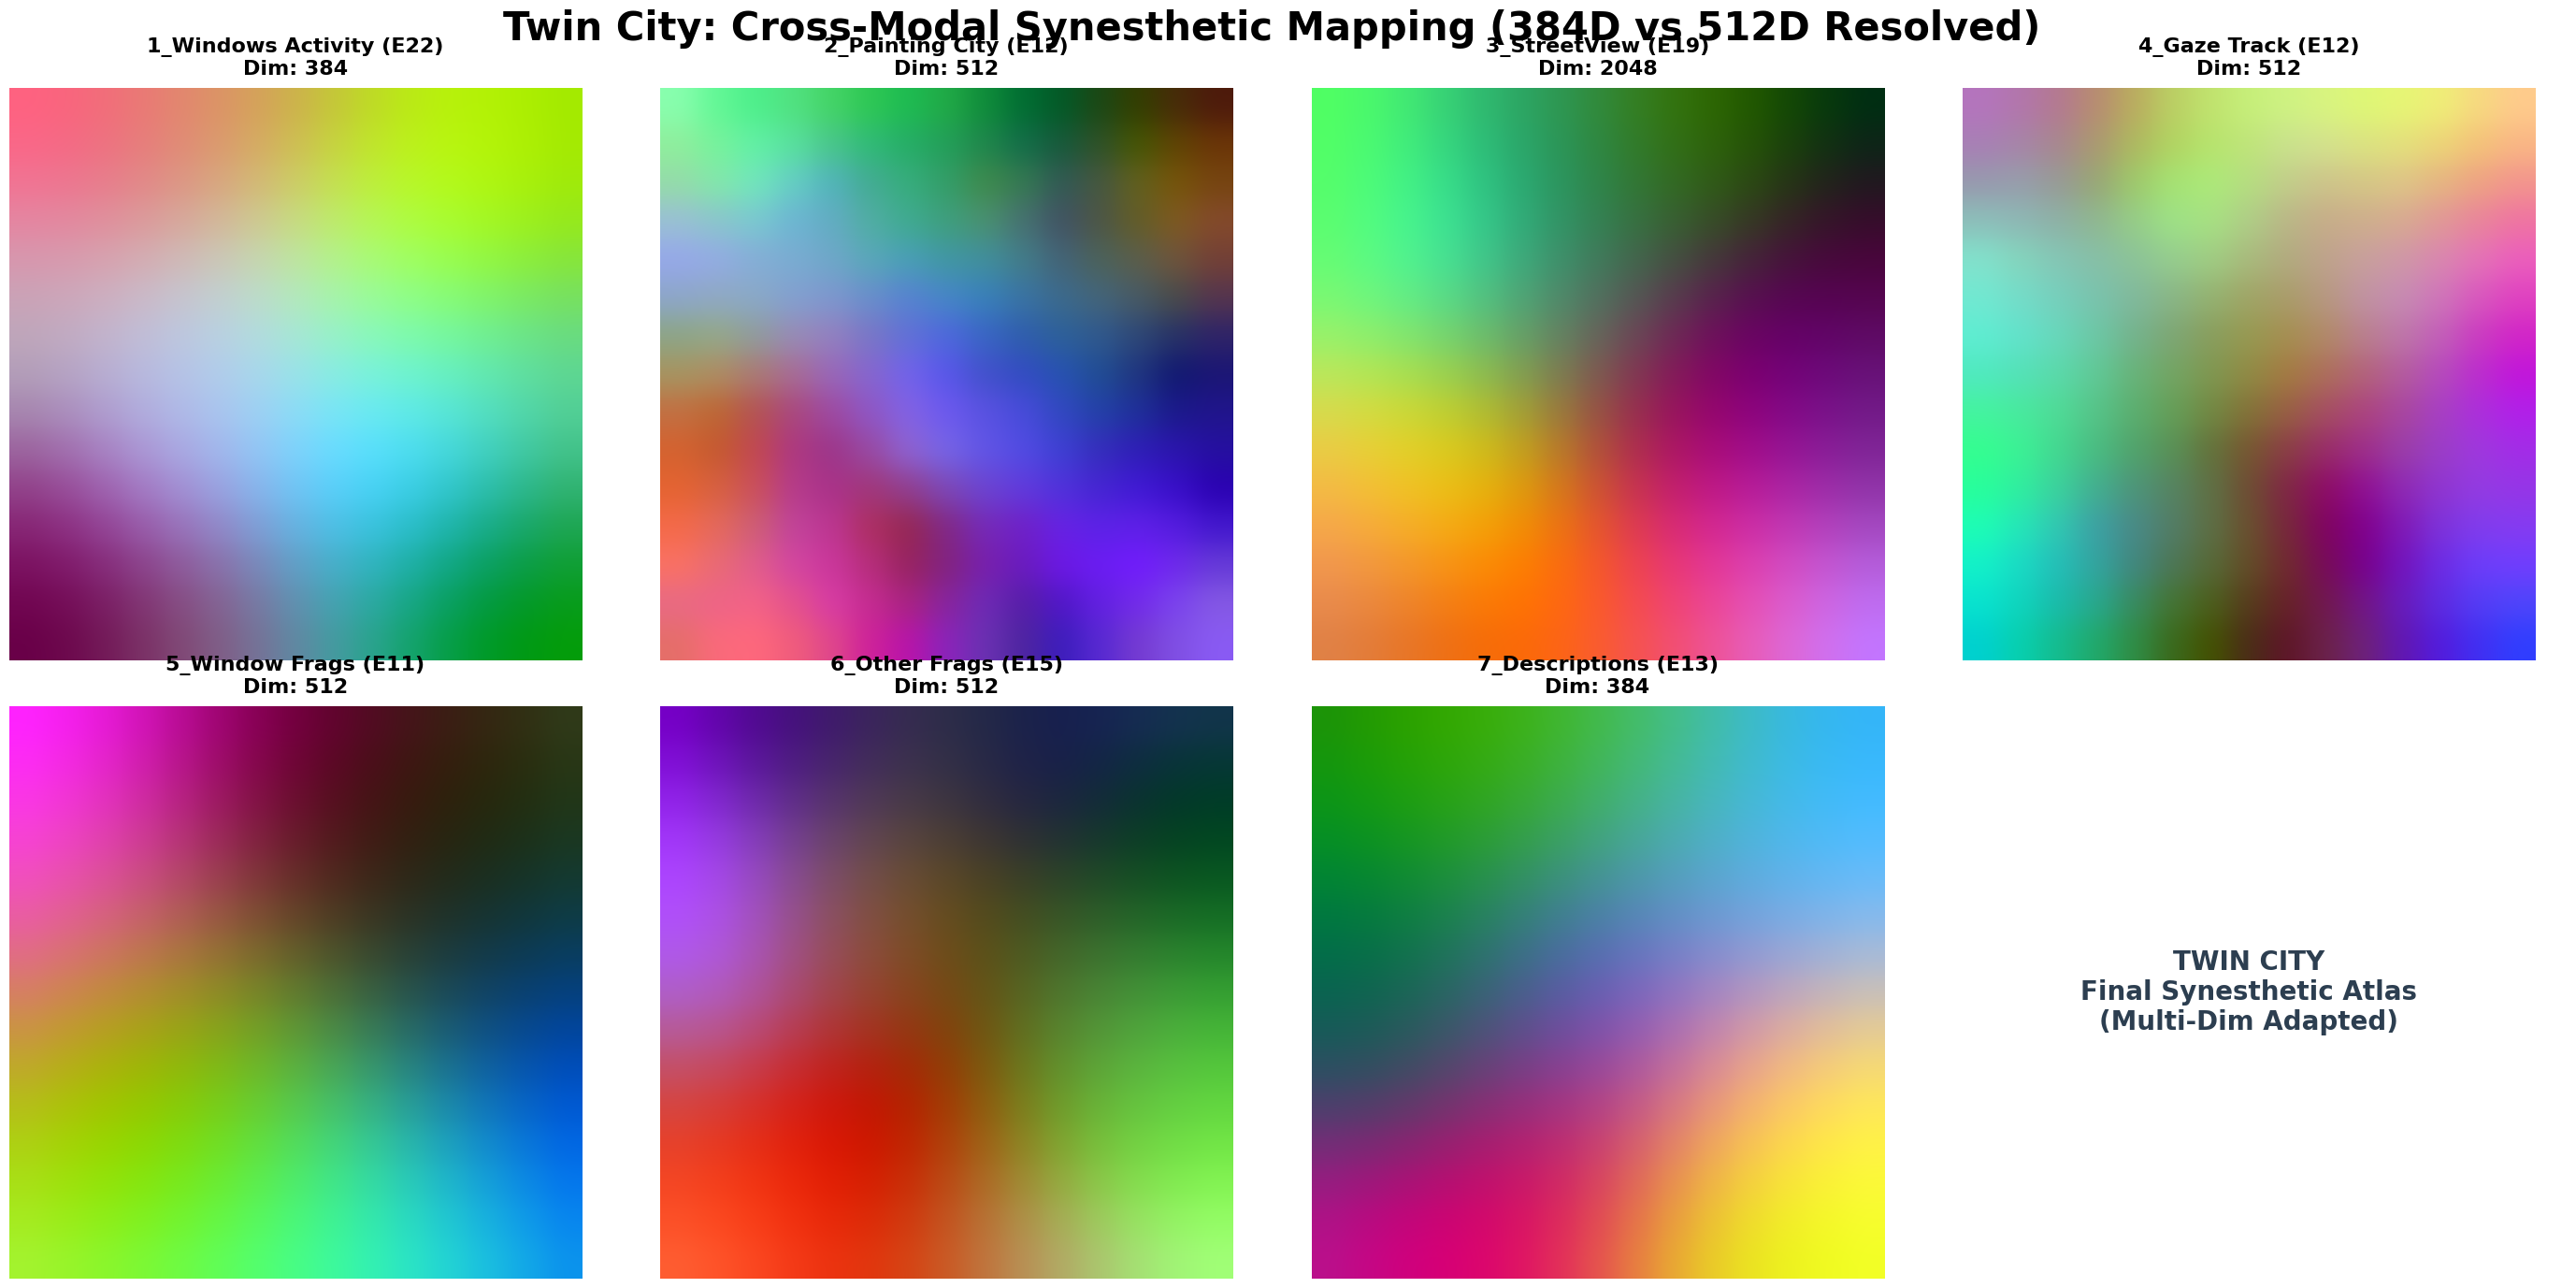

🌈 渲染完成！共成功映射 7 座模态城市。


In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ==========================================
# Step 1: Define 7 Major City Roster
# ==========================================
model_files = {
    "1_Windows Activity (E22)": "som_windows_activity_epoch22_fixed.pkl",
    "2_Painting City (E12)": "som_painting_GOLDEN_12e.pkl",
    "3_StreetView (E19)": "som_streetview_30e_GoldenSelection.pkl",
    "4_Gaze Track (E12)": "som_gaze_epoch12_fixed.pkl",
    "5_Window Frags (E11)": "som_windows_epoch11_fixed.pkl",
    "6_Other Frags (E15)": "som_other_fragments_epoch15_fixed.pkl",
    "7_Descriptions (E13)": "som_descriptions_epoch13_fixed.pkl"
}

# ==========================================
# Step 2: Core Logic - Process Different Dimensional Cities
# ==========================================
fig, axes = plt.subplots(2, 4, figsize=(28, 14))
axes = axes.flatten()

print("🎨 Executing full-city synesthetic mapping (adaptive independent dimensions)...")

valid_count = 0
for i, (name, path) in enumerate(model_files.items()):
    try:
        with open(path, 'rb') as f:
            som = pickle.load(f)
            
        # Compatibility: weight extraction
        w = getattr(som, 'best_weights', som.weights)
        flat_w = w.reshape(-1, w.shape[-1]) # (225, Dim)
        
        # --- Independent PCA Mapping ---
        # Even if Dim differs (384 or 512), extract top 3 principal components
        pca = PCA(n_components=3)
        pca_res = pca.fit_transform(flat_w)
        
        # Normalize to [0, 1] RGB space
        rgb = (pca_res - pca_res.min(axis=0)) / (pca_res.max(axis=0) - pca_res.min(axis=0) + 1e-8)
        img_rgb = rgb.reshape(15, 15, 3)
        
        # --- Visualization ---
        # Use Gaussian smoothing to eliminate aliasing, enhance "synesthetic" aesthetics
        axes[i].imshow(img_rgb, interpolation='gaussian')
        axes[i].set_title(f"{name}\nDim: {w.shape[-1]}", fontsize=16, fontweight='bold', pad=10)
        axes[i].axis('off')
        valid_count += 1
        
    except Exception as e:
        print(f"⚠️ Skipping {name}: {e}")
        axes[i].text(0.5, 0.5, f"Error loading\n{name}", ha='center', va='center', color='red')
        axes[i].axis('off')

# Final grid for title
axes[-1].text(0.5, 0.5, 'TWIN CITY\nFinal Synesthetic Atlas\n(Multi-Dim Adapted)', 
              ha='center', va='center', fontsize=20, fontweight='bold', color='#2c3e50')
axes[-1].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
fig.suptitle("Twin City: Cross-Modal Synesthetic Mapping (384D vs 512D Resolved)", fontsize=30, fontweight='bold')
plt.show()

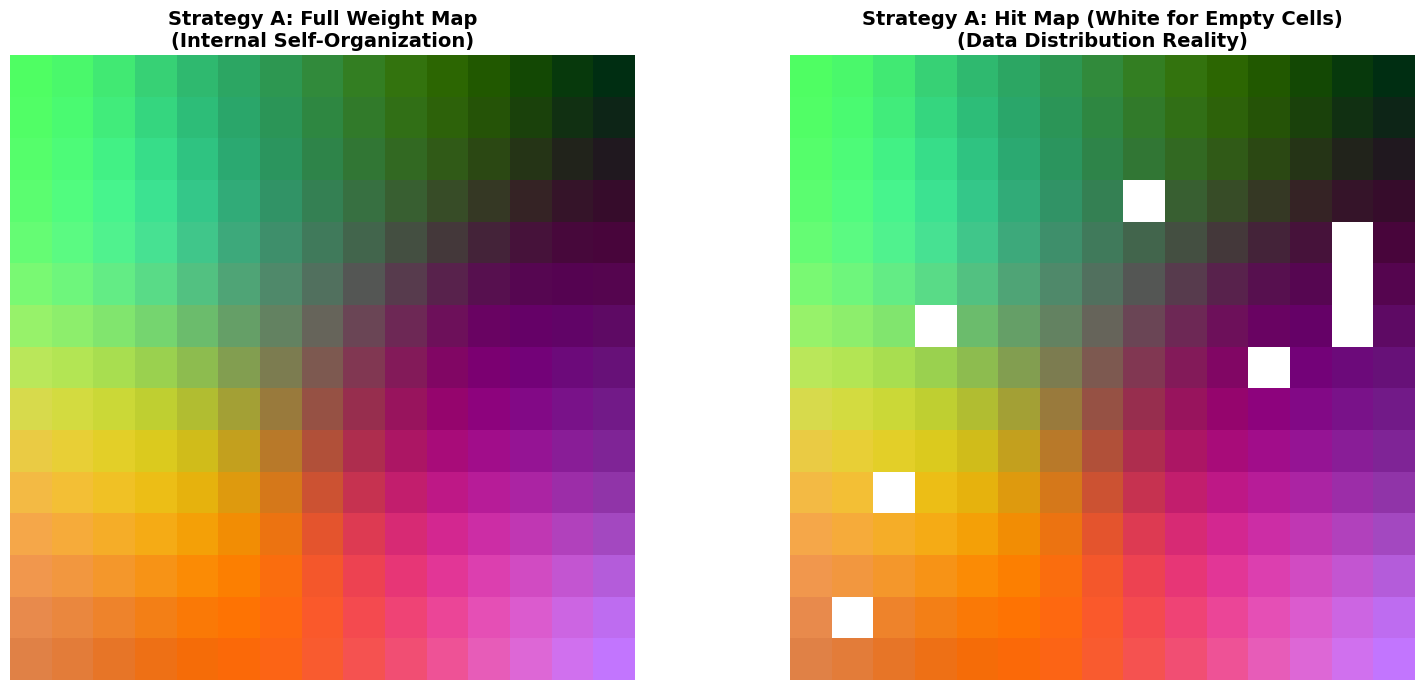

📊 统计：15x15 共 225 个格子中，有 217 个格子捕捉到了数据。


In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ==========================================
# Step 1: Load Model and Data (ensure data_streetview is in memory)
# ==========================================
model_path = 'som_streetview_30e_GoldenSelection.pkl'

with open(model_path, 'rb') as f:
    som = pickle.load(f)

# Extract frozen weights
weights = getattr(som, 'best_weights', som.weights) # (15, 15, 512)
x_size, y_size, dim = weights.shape

# ==========================================
# Step 2: Strategy A - PCA on Weights
# ==========================================
flat_weights = weights.reshape(-1, dim)
pca = PCA(n_components=3)
rgb_values = pca.fit_transform(flat_weights)

# Normalize colors to [0, 1]
rgb_values = (rgb_values - rgb_values.min(axis=0)) / (rgb_values.max(axis=0) - rgb_values.min(axis=0) + 1e-8)
full_color_map = rgb_values.reshape(x_size, y_size, 3)

# ==========================================
# Step 3: Calculate "Whitespace" Logic (Hit Map)
# ==========================================
# Track which nodes actually received data
hit_map = np.zeros((x_size, y_size))

# Assume raw street view data variable is named data_streetview
# If different, please modify here
for x in data_streetview:
    # Find nearest neuron index
    dist = np.linalg.norm(weights - x, axis=2)
    bmu = np.unravel_index(np.argmin(dist), (x_size, y_size))
    hit_map[bmu] += 1

# Create image with whitespace: if no hit, set to white [1, 1, 1]
hit_color_map = np.ones((x_size, y_size, 3)) 
for i in range(x_size):
    for j in range(y_size):
        if hit_map[i, j] > 0:
            hit_color_map[i, j] = full_color_map[i, j]

# ==========================================
# Step 4: Plot Comparison (Full Color vs With Whitespace)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Figure 1: Full color weight map (Weights-only)
ax1.imshow(full_color_map, interpolation='none') # 'none' preserves mosaic quality
ax1.set_title("Strategy A: Full Weight Map\n(Internal Self-Organization)", fontsize=14, fontweight='bold')
ax1.axis('off')

# Figure 2: Hit map with whitespace (Sample Average Style)
ax2.imshow(hit_color_map, interpolation='none')
ax2.set_title("Strategy A: Hit Map (White for Empty Cells)\n(Data Distribution Reality)", fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()

print(f"📊 Statistics: Out of 225 cells (15x15), {np.sum(hit_map > 0)} cells captured data.")

🧩 正在执行独立 PCA 映射 (马赛克风格 - 无留白版)...


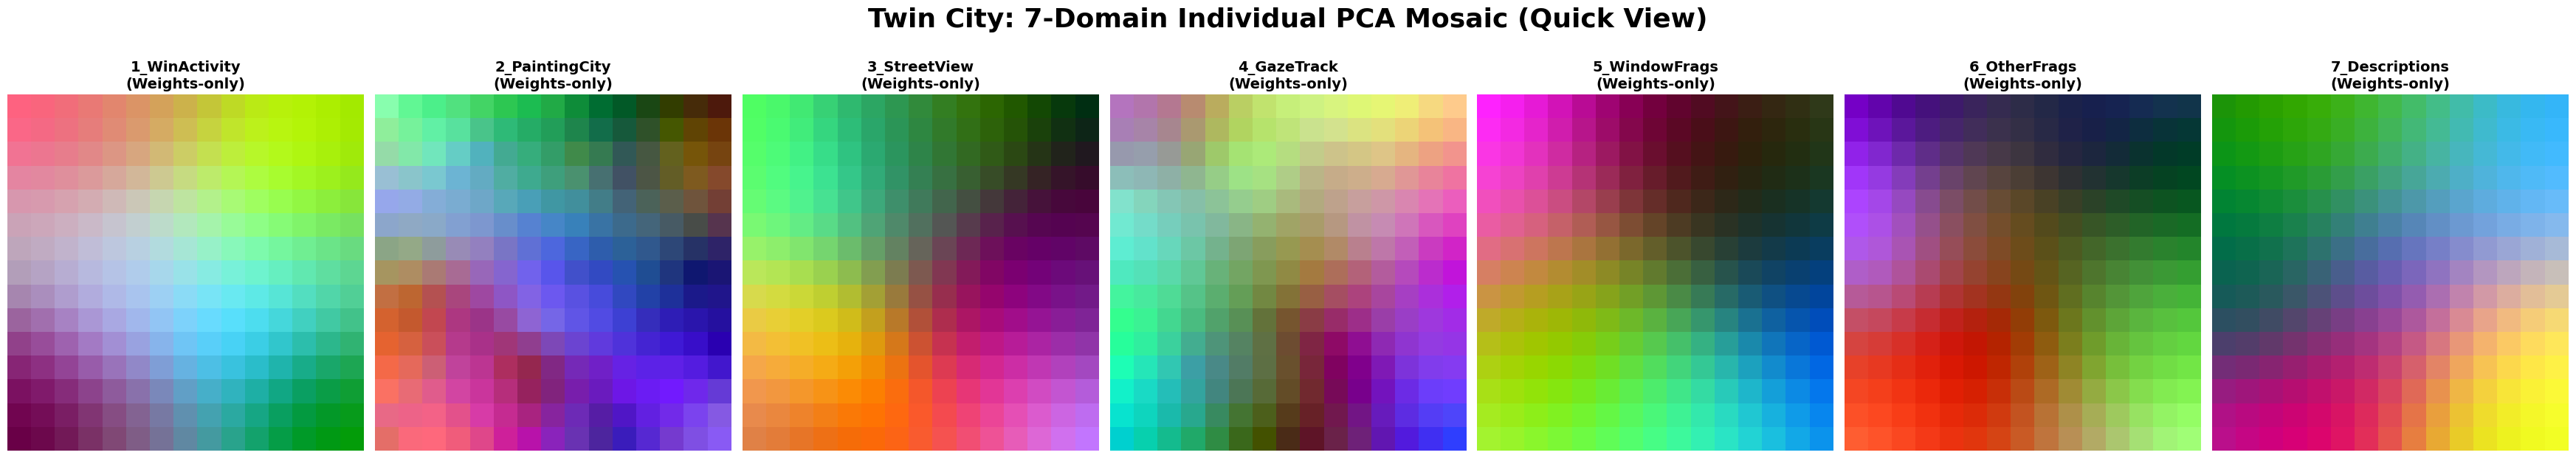

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ==========================================
# Step 1: As long as model files exist, we can generate plots!
# ==========================================
model_files = {
    "1_WinActivity": "som_windows_activity_epoch22_fixed.pkl",
    "2_PaintingCity": "som_painting_GOLDEN_12e.pkl",
    "3_StreetView": "som_streetview_30e_GoldenSelection.pkl",
    "4_GazeTrack": "som_gaze_epoch12_fixed.pkl",
    "5_WindowFrags": "som_windows_epoch11_fixed.pkl",
    "6_OtherFrags": "som_other_fragments_epoch15_fixed.pkl",
    "7_Descriptions": "som_descriptions_epoch13_fixed.pkl"
}

fig, axes = plt.subplots(1, 7, figsize=(35, 6))

print("🧩 Executing independent PCA mapping (Mosaic style - no whitespace)...")

for i, (name, path) in enumerate(model_files.items()):
    try:
        with open(path, 'rb') as f:
            som = pickle.load(f)
        
        # Extract weights
        w = getattr(som, 'best_weights', som.weights)
        x_size, y_size, dim = w.shape
        flat_w = w.reshape(-1, dim)
        
        # Run independent PCA (Strategy A)
        pca = PCA(n_components=3)
        rgb = pca.fit_transform(flat_w)
        rgb = (rgb - rgb.min(axis=0)) / (rgb.max(axis=0) - rgb.min(axis=0) + 1e-8)
        
        img_rgb = rgb.reshape(x_size, y_size, 3)
        
        # Plot: use 'nearest' for grid effect
        axes[i].imshow(img_rgb, interpolation='nearest') 
        axes[i].set_title(f"{name}\n(Weights-only)", fontsize=14, fontweight='bold')
        axes[i].axis('off')
        
    except Exception as e:
        print(f"⚠️ Skipping {name}: {e}")
        axes[i].axis('off')

plt.tight_layout()
plt.suptitle("Twin City: 7-Domain Individual PCA Mosaic (Quick View)", fontsize=26, y=1.1, fontweight='bold')
plt.show()

🖼️ 正在加载 ResNet18 (匹配 512 维)...


c:\ProgramData\miniconda3\envs\jupyter-py311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


📍 模型期望维度: 512 (ResNet18 标准)
✅ 成功对齐图片数: 2582


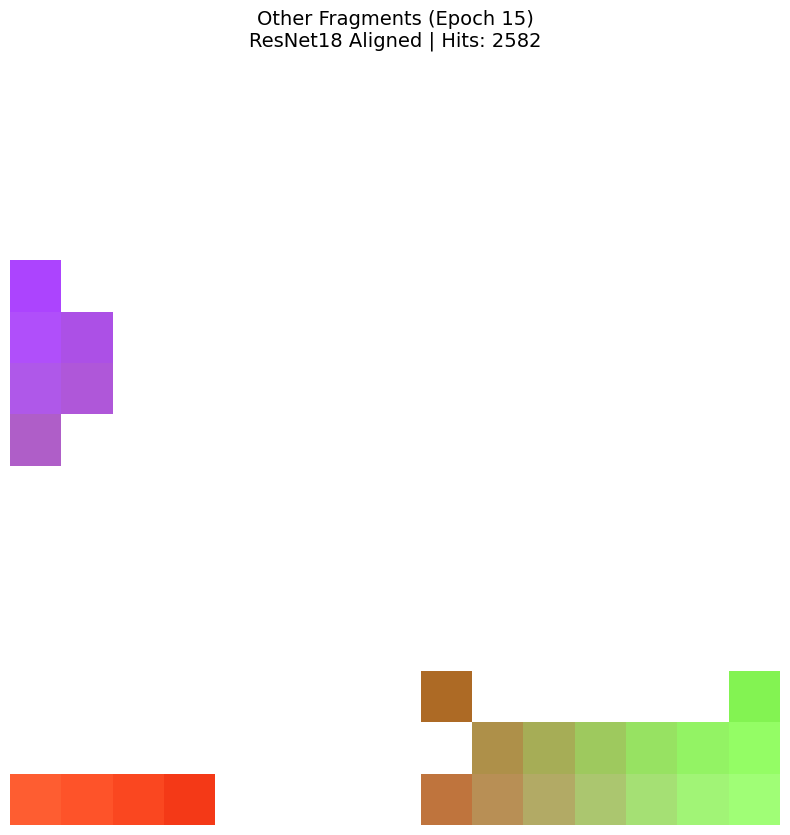

In [ ]:
import os
import pickle
import numpy as np
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==========================================
# Step 1: Path Configuration
# ==========================================
model_path = 'som_other_fragments_epoch15_fixed.pkl'
img_dir = r"C:\Users\asus\Desktop\RC11 TERM2\data set\TwinCity_All_Assets"
device = "cuda" if torch.cuda.is_available() else "cpu"

# ==========================================
# Step 2: Core Fix - Use ResNet18 to Extract 512-Dimensional Features
# ==========================================
print("🖼️ Loading ResNet18 (matching 512D)...")
# ResNet18's second-to-last layer output is exactly 512
resnet18 = models.resnet18(pretrained=True)
resnet18 = torch.nn.Sequential(*(list(resnet18.children())[:-1])).to(device).eval()

preprocess = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ==========================================
# Step 3: Load Model and Verify
# ==========================================
with open(model_path, 'rb') as f:
    som = pickle.load(f)

weights = getattr(som, 'best_weights', som.weights)
x_size, y_size, model_dim = weights.shape
print(f"📍 Model expected dimension: {model_dim} (ResNet18 standard)")

# ==========================================
# Step 4: Calculate Hit Map
# ==========================================
files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
hit_map = np.zeros((x_size, y_size))
processed_count = 0

for fname in files:
    try:
        img = Image.open(os.path.join(img_dir, fname)).convert('RGB')
        img_t = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            # Feature vector should now be 512D
            feat = resnet18(img_t).cpu().numpy().flatten()
            
        dist = np.linalg.norm(weights - feat, axis=2)
        bmu = np.unravel_index(np.argmin(dist), (x_size, y_size))
        hit_map[bmu] += 1
        processed_count += 1
    except Exception as e:
        continue

print(f"✅ Successfully aligned images: {processed_count}")

# ==========================================
# Step 5: Render Example-Level Mosaic
# ==========================================
if processed_count > 0:
    # PCA color calculation
    flat_w = weights.reshape(-1, model_dim)
    pca = PCA(n_components=3)
    rgb = pca.fit_transform(flat_w)
    rgb = (rgb - rgb.min(axis=0)) / (rgb.max(axis=0) - rgb.min(axis=0) + 1e-8)
    full_colors = rgb.reshape(x_size, y_size, 3)

    # Apply whitespace logic
    final_map = np.ones((x_size, y_size, 3)) # Default background is white
    for i in range(x_size):
        for j in range(y_size):
            if hit_map[i, j] > 0:
                final_map[i, j] = full_colors[i, j]

    plt.figure(figsize=(10, 10))
    plt.imshow(final_map, interpolation='none')
    plt.title(f"Other Fragments (Epoch 15)\nResNet18 Aligned | Hits: {processed_count}", fontsize=14)
    plt.axis('off')
    plt.show()
else:
    print("❌ Still no images activated, please check folder contents.")

🎨 正在加载 CLIP (ViT-B/32) 提取器...


modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


...

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

📍 模型期望维度: 512
🔍 正在用 CLIP 扫描 2582 张碎片图片...


100%|██████████| 2582/2582 [00:55<00:00, 46.89it/s]


✅ CLIP 映射完成！激活节点数: 219


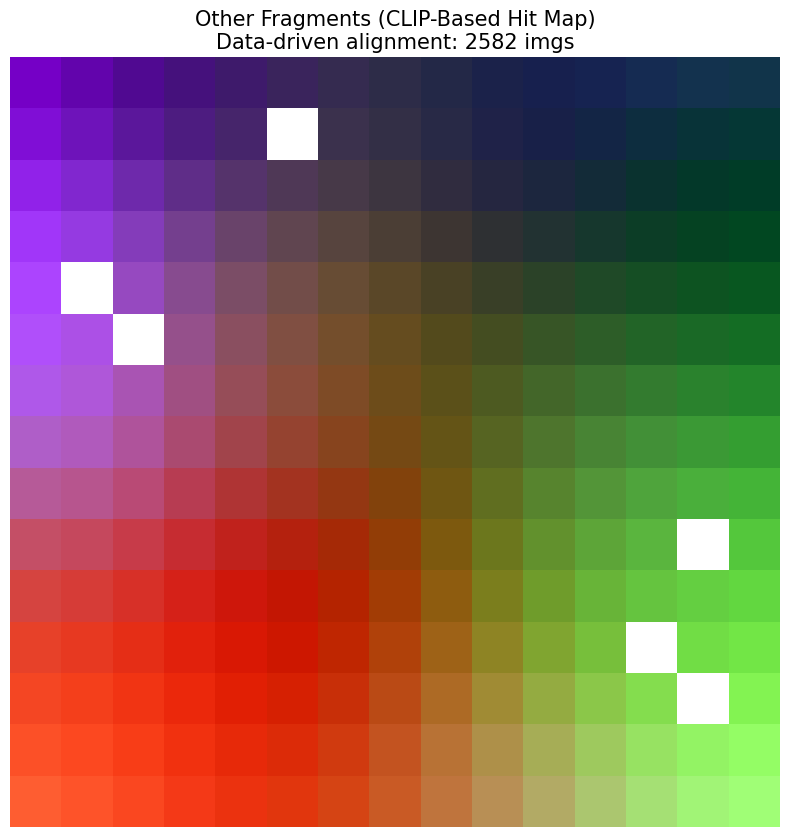

In [ ]:
import os
import pickle
import numpy as np
import torch
from sentence_transformers import SentenceTransformer
from PIL import Image
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==========================================
# Step 1: Path and Configuration
# ==========================================
model_path = 'som_other_fragments_epoch15_fixed.pkl'
img_dir = r"C:\Users\asus\Desktop\RC11 TERM2\data set\TwinCity_All_Assets"
device = "cuda" if torch.cuda.is_available() else "cpu"

# ==========================================
# Step 2: Load CLIP Model (Enforce 512D Output)
# ==========================================
print("🎨 Loading CLIP (ViT-B/32) encoder...")
# This model specifically outputs 512D vectors, perfectly matching your SOM
clip_model = SentenceTransformer('clip-ViT-B-32', device=device)

# ==========================================
# Step 3: Load SOM Model
# ==========================================
with open(model_path, 'rb') as f:
    som = pickle.load(f)

weights = getattr(som, 'best_weights', som.weights)
x_size, y_size, model_dim = weights.shape
print(f"📍 Model expected dimension: {model_dim}")

if model_dim != 512:
    print(f"⚠️ Warning: Your model is {model_dim}D but CLIP B/32 is 512D - potential mismatch!")

# ==========================================
# Step 4: Extract Features and Calculate Hit Map
# ==========================================
files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
hit_map = np.zeros((x_size, y_size))
valid_images = []

print(f"🔍 Scanning {len(files)} fragment images with CLIP...")

for fname in tqdm(files):
    try:
        img_path = os.path.join(img_dir, fname)
        img = Image.open(img_path).convert('RGB')
        
        # Use CLIP to encode image
        with torch.no_grad():
            feat = clip_model.encode(img) 
            
        # Calculate BMU (nearest cell)
        dist = np.linalg.norm(weights - feat, axis=2)
        bmu = np.unravel_index(np.argmin(dist), (x_size, y_size))
        hit_map[bmu] += 1
        valid_images.append(fname)
    except Exception as e:
        continue

print(f"✅ CLIP mapping completed! Activated nodes: {np.sum(hit_map > 0)}")

# ==========================================
# Step 5: Render Example-Level Mosaic (Strategy A)
# ==========================================
if np.sum(hit_map) > 0:
    # PCA dimensionality reduction (3 components map to RGB)
    flat_w = weights.reshape(-1, model_dim)
    pca = PCA(n_components=3)
    rgb = pca.fit_transform(flat_w)
    
    # Normalize colors
    rgb = (rgb - rgb.min(axis=0)) / (rgb.max(axis=0) - rgb.min(axis=0) + 1e-8)
    full_colors = rgb.reshape(x_size, y_size, 3)

    # Whitespace logic
    final_map = np.ones((x_size, y_size, 3)) 
    for i in range(x_size):
        for j in range(y_size):
            if hit_map[i, j] > 0:
                final_map[i, j] = full_colors[i, j]

    plt.figure(figsize=(10, 10))
    plt.imshow(final_map, interpolation='none')
    plt.title(f"Other Fragments (CLIP-Based Hit Map)\nData-driven alignment: {len(valid_images)} imgs", fontsize=15)
    plt.axis('off')
    plt.show()
else:
    print("❌ No hits detected. Please confirm your .pkl was originally trained with CLIP?")

🎨 正在初始化 CLIP 提取器并载入模型...
🔍 正在扫描 1781 张窗户碎片图片并映射落点...


100%|██████████| 1781/1781 [00:38<00:00, 46.08it/s]


✅ 映射完成！激活节点: 175 / 225


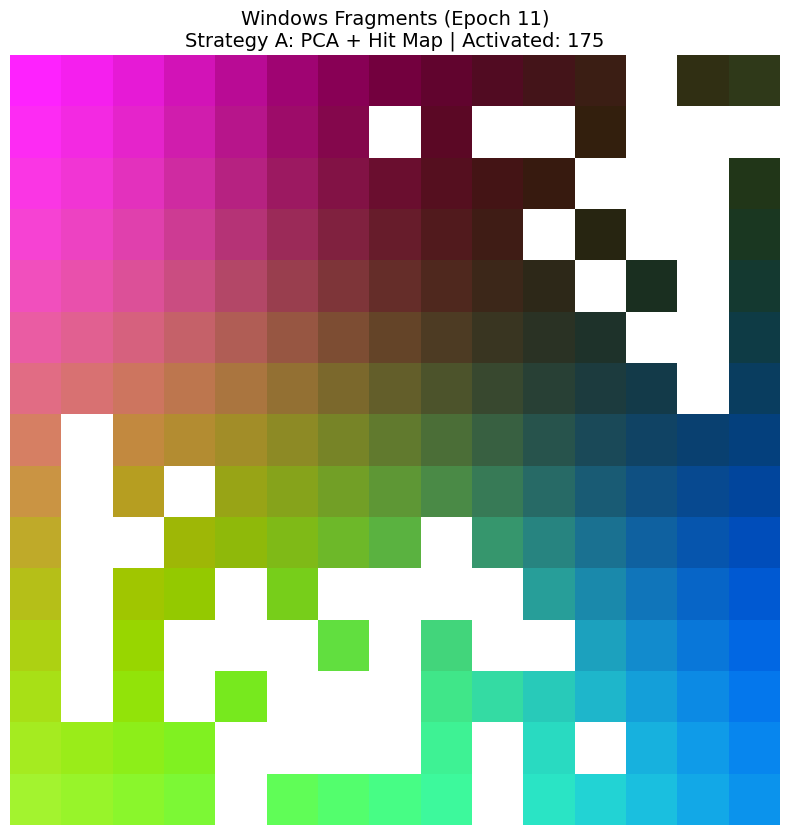

In [ ]:
import os
import pickle
import numpy as np
import torch
from sentence_transformers import SentenceTransformer
from PIL import Image
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==========================================
# Step 1: Core Path Configuration (Windows Specific)
# ==========================================
model_path = 'som_windows_epoch11_fixed.pkl'
img_dir = r"C:\Users\asus\Desktop\RC11 TERM2\TwinCity_Final_10\10_Windows"
device = "cuda" if torch.cuda.is_available() else "cpu"

# ==========================================
# Step 2: Initialize CLIP Encoder and Load Model
# ==========================================
print("🎨 Initializing CLIP encoder and loading model...")
clip_model = SentenceTransformer('clip-ViT-B-32', device=device)

with open(model_path, 'rb') as f:
    som = pickle.load(f)

# Extract 15x15x512 weights
weights = getattr(som, 'best_weights', som.weights)
x_size, y_size, model_dim = weights.shape

# ==========================================
# Step 3: Calculate Hit Map (Find Whitespace)
# ==========================================
files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
hit_map = np.zeros((x_size, y_size))

print(f"🔍 Scanning {len(files)} window fragment images and mapping activation points...")
for fname in tqdm(files):
    try:
        img_path = os.path.join(img_dir, fname)
        img = Image.open(img_path).convert('RGB')
        
        with torch.no_grad():
            feat = clip_model.encode(img)
            
        # Calculate BMU (nearest cell)
        dist_matrix = np.linalg.norm(weights - feat, axis=2)
        bmu = np.unravel_index(np.argmin(dist_matrix), (x_size, y_size))
        hit_map[bmu] += 1
    except Exception:
        continue

# ==========================================
# Step 4: Strategy A - Calculate PCA Background Color
# ==========================================
flat_w = weights.reshape(-1, model_dim)
pca = PCA(n_components=3)
rgb = pca.fit_transform(flat_w)

# Normalize colors to [0, 1] range
rgb = (rgb - rgb.min(axis=0)) / (rgb.max(axis=0) - rgb.min(axis=0) + 1e-8)
full_colors = rgb.reshape(x_size, y_size, 3)

# ==========================================
# Step 5: Generate Final "Whitespace" Mosaic
# ==========================================
activated_nodes = np.sum(hit_map > 0)
print(f"✅ Mapping completed! Activated nodes: {activated_nodes} / 225")

# Whitespace logic: cells without activation set to pure white [1, 1, 1]
final_map = np.ones((x_size, y_size, 3)) 
for i in range(x_size):
    for j in range(y_size):
        if hit_map[i, j] > 0:
            final_map[i, j] = full_colors[i, j]

# ==========================================
# Step 6: Visualization
# ==========================================
plt.figure(figsize=(10, 10))
plt.imshow(final_map, interpolation='none') # 'none' ensures mosaic grid clarity
plt.title(f"Windows Fragments (Epoch 11)\nStrategy A: PCA + Hit Map | Activated: {activated_nodes}", fontsize=14)
plt.axis('off')
plt.show()

# Save result
plt.imsave("Windows_PCA_HitMap.png", final_map)

✍️ 正在初始化 SBERT (all-MiniLM-L6-v2) 并载入模型...
📍 文本模型维度: 384
📄 正在从 CSV 加载文本数据...
🔍 正在将 2689 条行为描述映射至 SOM 空间...


Batches:   0%|          | 0/85 [00:00<?, ?it/s]

✅ 映射完成！激活节点: 222 / 225


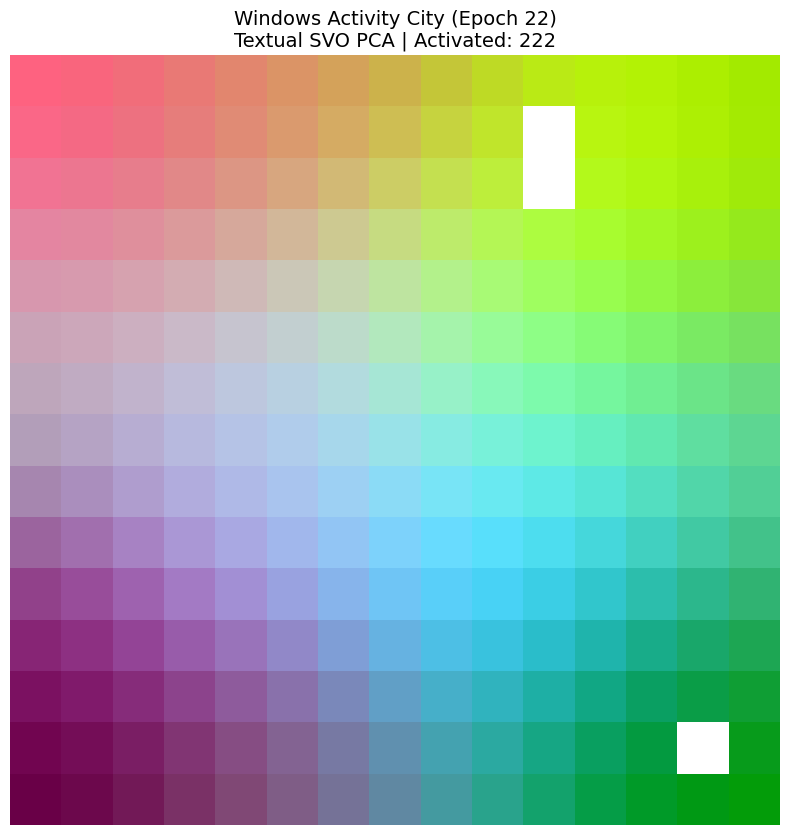

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch

# ==========================================
# Step 1: Core Path Configuration (Text City Specific)
# ==========================================
model_path = 'som_windows_activity_epoch22_fixed.pkl'
csv_path = r"C:\Users\asus\Desktop\RC11 TERM2\data set\windows_activity_svo_lemmatized.csv"
device = "cuda" if torch.cuda.is_available() else "cpu"

# ==========================================
# Step 2: Initialize SBERT Encoder and Load Model
# ==========================================
print("✍️ Initializing SBERT (all-MiniLM-L6-v2) and loading model...")
# Important: Ensure the embedding model used here matches the one used during SOM training
text_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

with open(model_path, 'rb') as f:
    som = pickle.load(f)

# Get 15x15x384 (or actual dimension) weights
weights = getattr(som, 'best_weights', som.weights)
x_size, y_size, model_dim = weights.shape
print(f"📍 Text model dimension: {model_dim}")

# ==========================================
# Step 3: Load Data and Calculate Hit Map
# ==========================================
print(f"📄 Loading text data from CSV...")
df = pd.read_csv(csv_path)
sentences = df['lemmatized_sentence'].astype(str).tolist()

hit_map = np.zeros((x_size, y_size))

print(f"🔍 Mapping {len(sentences)} behavior descriptions into SOM space...")
# For speed, encode in batches
sentence_embeddings = text_model.encode(sentences, show_progress_bar=True, device=device)

for feat in sentence_embeddings:
    # Find nearest cell (BMU)
    dist_matrix = np.linalg.norm(weights - feat, axis=2)
    bmu = np.unravel_index(np.argmin(dist_matrix), (x_size, y_size))
    hit_map[bmu] += 1

# ==========================================
# Step 4: Strategy A - Calculate Independent PCA Colors
# ==========================================
activated_nodes = np.sum(hit_map > 0)
print(f"✅ Mapping completed! Activated nodes: {activated_nodes} / 225")

flat_w = weights.reshape(-1, model_dim)
pca = PCA(n_components=3)
rgb = pca.fit_transform(flat_w)
# Normalize colors
rgb = (rgb - rgb.min(axis=0)) / (rgb.max(axis=0) - rgb.min(axis=0) + 1e-8)
full_colors = rgb.reshape(x_size, y_size, 3)

# ==========================================
# Step 5: Generate Whitespace Mosaic
# ==========================================
final_map = np.ones((x_size, y_size, 3)) # Default background is white
for i in range(x_size):
    for j in range(y_size):
        if hit_map[i, j] > 0:
            final_map[i, j] = full_colors[i, j]

# Visualization
plt.figure(figsize=(10, 10))
plt.imshow(final_map, interpolation='none')
plt.title(f"Windows Activity City (Epoch 22)\nTextual SVO PCA | Activated: {activated_nodes}", fontsize=14)
plt.axis('off')
plt.show()

# Save
plt.imsave("WindowsActivity_PCA_HitMap.png", final_map)

⏳ 正在提取文本语义并匹配格子...


Batches:   0%|          | 0/85 [00:00<?, ?it/s]

🎨 正在渲染关键词地图...


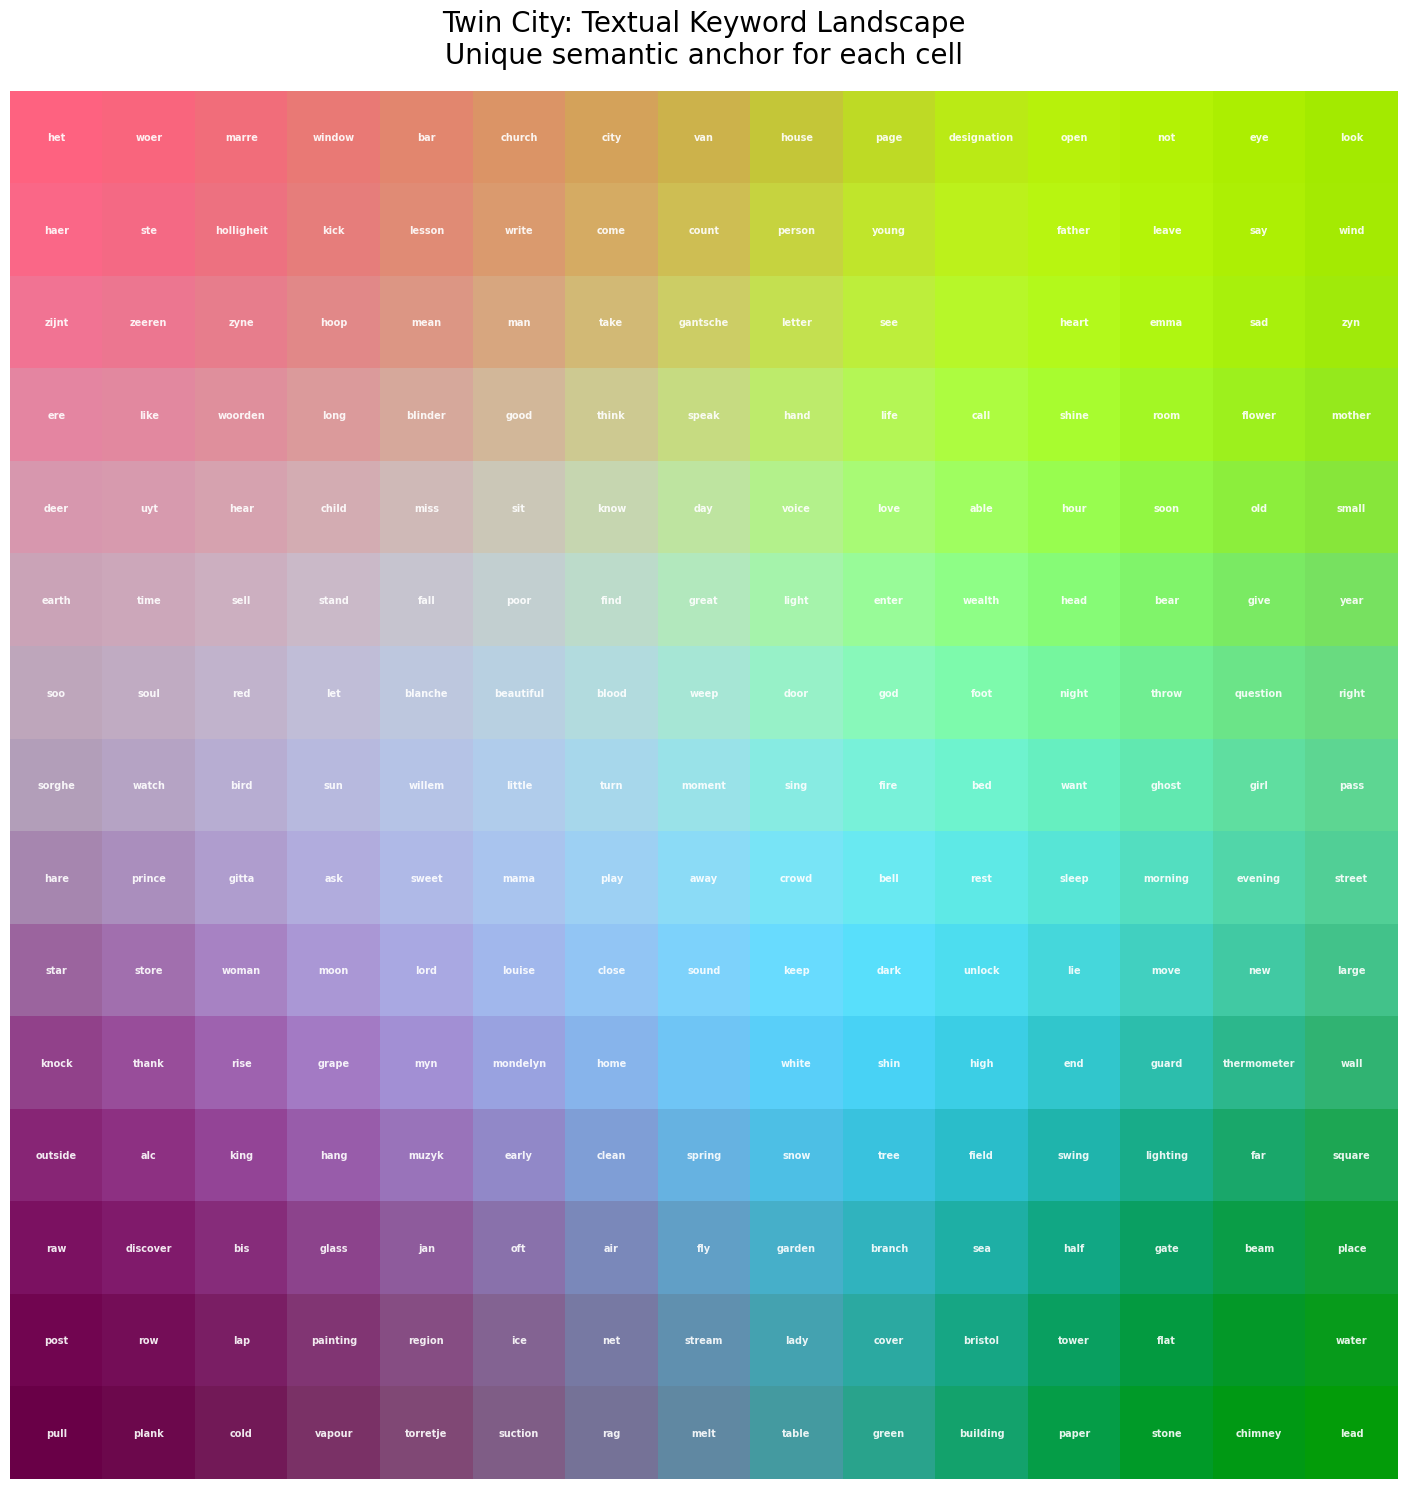

<Figure size 640x480 with 0 Axes>

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import re
from collections import Counter
import torch

# ==========================================
# Step 1: Configuration and Loading
# ==========================================
model_path = 'som_windows_activity_epoch22_fixed.pkl'
csv_path = r"C:\Users\asus\Desktop\RC11 TERM2\data set\windows_activity_svo_lemmatized.csv"
device = "cuda" if torch.cuda.is_available() else "cpu"

with open(model_path, 'rb') as f:
    som = pickle.load(f)

weights = getattr(som, 'best_weights', som.weights)
x_size, y_size, model_dim = weights.shape

# Load data
df = pd.read_csv(csv_path)
sentences = df['lemmatized_sentence'].astype(str).tolist()

# ==========================================
# Step 2: Semantic Extraction and Activation Statistics
# ==========================================
print("⏳ Extracting text semantics and matching cells...")
text_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)
embeddings = text_model.encode(sentences, show_progress_bar=True)

# Build dictionary to store all words for each cell
# cell_words = {(r, c): [word1, word2, ...]}
cell_words = {(r, c): [] for r in range(x_size) for c in range(y_size)}

for i, feat in enumerate(embeddings):
    dist_matrix = np.linalg.norm(weights - feat, axis=2)
    bmu = np.unravel_index(np.argmin(dist_matrix), (x_size, y_size))
    
    # Simple tokenization (filter out short words and meaningless terms)
    words = re.findall(r'\b\w{3,}\b', sentences[i].lower()) 
    cell_words[bmu].extend(words)

# ==========================================
# Step 3: Select Unique Keywords for Each Cell
# ==========================================
used_words = set()
grid_keywords = {}

# Stopword list (can add more as needed)
stopwords = {'the', 'and', 'with', 'from', 'this', 'that', 'into', 'some'}

for r in range(x_size):
    for c in range(y_size):
        words_in_cell = [w for w in cell_words[(r, c)] if w not in stopwords]
        counts = Counter(words_in_cell).most_common(20) # Get top 20 candidates
        
        selected = ""
        for word, _ in counts:
            if word not in used_words:
                selected = word
                used_words.add(word)
                break
        
        if not selected: # If no unique word found, leave empty or use placeholder
            grid_keywords[(r, c)] = ""
        else:
            grid_keywords[(r, c)] = selected

# ==========================================
# Step 4: Visual Rendering (PCA Background + Text Overlay)
# ==========================================
print("🎨 Rendering keyword map...")
flat_w = weights.reshape(-1, model_dim)
pca = PCA(n_components=3)
rgb = pca.fit_transform(flat_w)
rgb = (rgb - rgb.min(axis=0)) / (rgb.max(axis=0) - rgb.min(axis=0) + 1e-8)
full_colors = rgb.reshape(x_size, y_size, 3)

fig, ax = plt.subplots(figsize=(15, 15), dpi=100)
# Render background
ax.imshow(full_colors, interpolation='none')

# Write text on each cell
for r in range(x_size):
    for c in range(y_size):
        word = grid_keywords[(r, c)]
        if word:
            # Decide text color based on background brightness (simple approach: use white or black)
            # Or like the reference image, use very small font to create "texture effect"
            ax.text(c, r, word, ha='center', va='center', 
                    color='white', fontsize=7, fontweight='bold',
                    alpha=0.9, rotation=0)

ax.axis('off')
plt.title("Twin City: Textual Keyword Landscape\nUnique semantic anchor for each cell", 
          fontsize=20, color='black', pad=20)
plt.tight_layout()
plt.show()

# Save
plt.savefig("WindowsActivity_Keyword_Map.png", bbox_inches='tight', dpi=300)

# Reborn SOM with Full Semantic Alignment

🎨 正在加载 CLIP 语意提取器...
🚀 正在对 1102 张画作进行高维语意建模...


100%|██████████| 1102/1102 [00:33<00:00, 32.77it/s]


Epoch 1/30 完成...
Epoch 2/30 完成...
Epoch 3/30 完成...
Epoch 4/30 完成...
Epoch 5/30 完成...
Epoch 6/30 完成...
Epoch 7/30 完成...
Epoch 8/30 完成...
Epoch 9/30 完成...
Epoch 10/30 完成...
Epoch 11/30 完成...
Epoch 12/30 完成...
Epoch 13/30 完成...
Epoch 14/30 完成...
Epoch 15/30 完成...
Epoch 16/30 完成...
Epoch 17/30 完成...
Epoch 18/30 完成...
Epoch 19/30 完成...
Epoch 20/30 完成...
Epoch 21/30 完成...
Epoch 22/30 完成...
Epoch 23/30 完成...
Epoch 24/30 完成...
Epoch 25/30 完成...
Epoch 26/30 完成...
Epoch 27/30 完成...
Epoch 28/30 完成...
Epoch 29/30 完成...
Epoch 30/30 完成...
📊 正在生成 30 轮演化全景图...


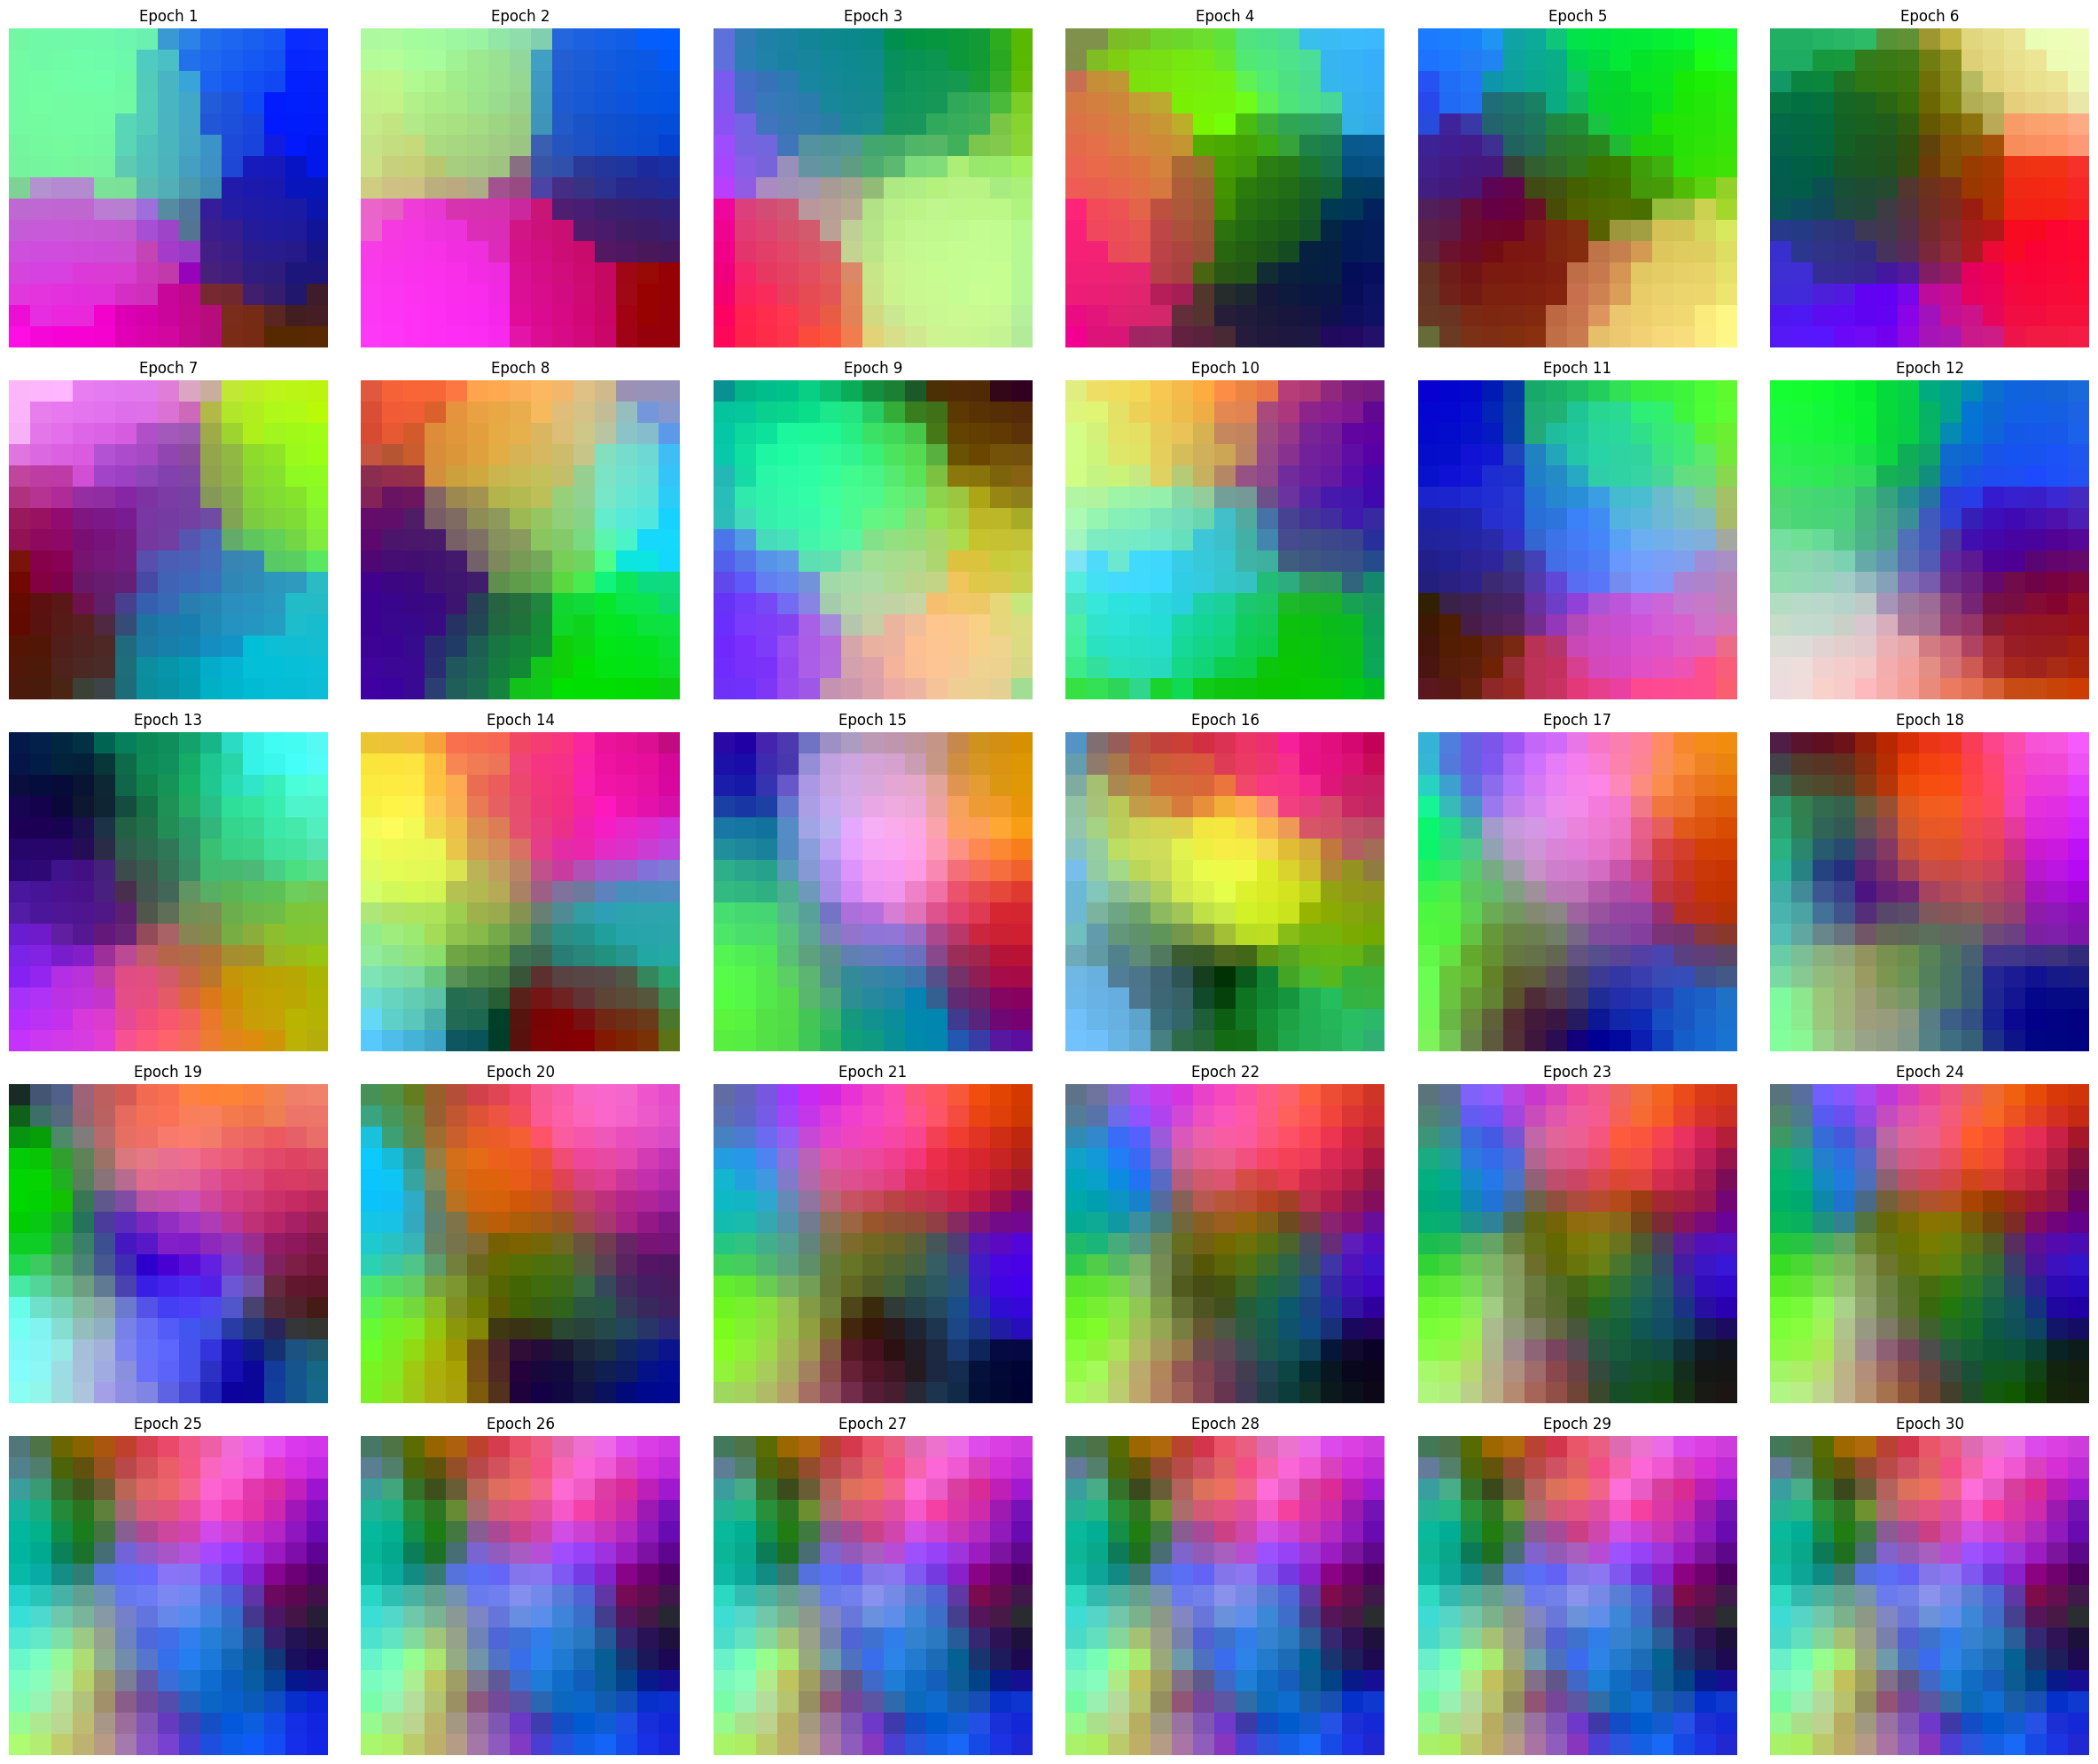

✨ 演化史已保存。请看图告诉我要哪一轮，我帮你定格出最终的 PCA 留白图。


In [ ]:
import os
import pickle
import numpy as np
import torch
from sentence_transformers import SentenceTransformer
from PIL import Image
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==========================================
# Step 1: Path and Core Parameters
# ==========================================
img_dir = r"C:\Users\asus\Desktop\RC11 TERM2\data set\huazuo"
device = "cuda" if torch.cuda.is_available() else "cpu"
x_size, y_size = 15, 15
epochs = 30

# ==========================================
# Step 2: Unified Feature Extraction (CLIP 512D + L2 Norm)
# ==========================================
print("🎨 Loading CLIP semantic encoder...")
model = SentenceTransformer('clip-ViT-B-32', device=device)

files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
features = []

print(f"🚀 Building high-dimensional semantic model for {len(files)} paintings...")
for fname in tqdm(files):
    try:
        img = Image.open(os.path.join(img_dir, fname)).convert('RGB')
        with torch.no_grad():
            f = model.encode(img)
        # Core: L2 normalization to ensure all vectors lie on unit sphere
        # This is the foundation for cross-modal search
        f = f / (np.linalg.norm(f) + 1e-8)
        features.append(f)
    except: 
        continue

data = np.array(features)
input_dim = data.shape[1] # Should be 512

# ==========================================
# Step 3: Custom SOM Training (Record History for Each Epoch)
# ==========================================
class RebornSOM:
    """Custom SOM with complete epoch-by-epoch history tracking"""
    def __init__(self, x, y, dim):
        # Use Gaussian distribution initialization, controlled range in normalized space
        self.weights = np.random.normal(0, 0.1, (x, y, dim))
        self.history = []

    def train(self, data, epochs):
        """Train SOM and record weight evolution"""
        for e in range(1, epochs + 1):
            # Dynamically adjust learning rate and radius
            lr = 0.5 * (1 - e/epochs)
            sigma = max(x_size, y_size) / 2 * (1 - e/epochs)
            
            for sample in data:
                # Find BMU
                dist = np.linalg.norm(self.weights - sample, axis=2)
                bmu = np.unravel_index(np.argmin(dist), (x_size, y_size))
                
                # Update weights (vectorized acceleration)
                for i in range(x_size):
                    for j in range(y_size):
                        d_bmu = np.sqrt((i-bmu[0])**2 + (j-bmu[1])**2)
                        if d_bmu < sigma:
                            influence = np.exp(-d_bmu**2 / (2 * (sigma**2 + 1e-8)))
                            self.weights[i, j] += lr * influence * (sample - self.weights[i, j])
            
            # Record weights from this epoch for display
            self.history.append(self.weights.copy())
            print(f"Epoch {e}/{epochs} completed...")

som = RebornSOM(x_size, y_size, input_dim)
som.train(data, epochs)

# ==========================================
# Step 4: Render 30-Epoch Evolution Panorama (PCA Perspective)
# ==========================================
print("📊 Generating 30-epoch evolution panorama...")
pca = PCA(n_components=3)
fig, axes = plt.subplots(5, 6, figsize=(24, 20)) # 5x6 exactly shows 30 epochs
axes = axes.flatten()

for i in range(epochs):
    w = som.history[i].reshape(-1, input_dim)
    rgb = pca.fit_transform(w)
    rgb = (rgb - rgb.min(axis=0)) / (rgb.max(axis=0) - rgb.min(axis=0) + 1e-8)
    img_rgb = rgb.reshape(x_size, y_size, 3)
    
    axes[i].imshow(img_rgb, interpolation='gaussian')
    axes[i].set_title(f"Epoch {i+1}", fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.suptitle("Painting City: 30-Epoch SOM Evolution Trajectory", fontsize=24, fontweight='bold')
plt.show()

🎯 正在计算最终落点...


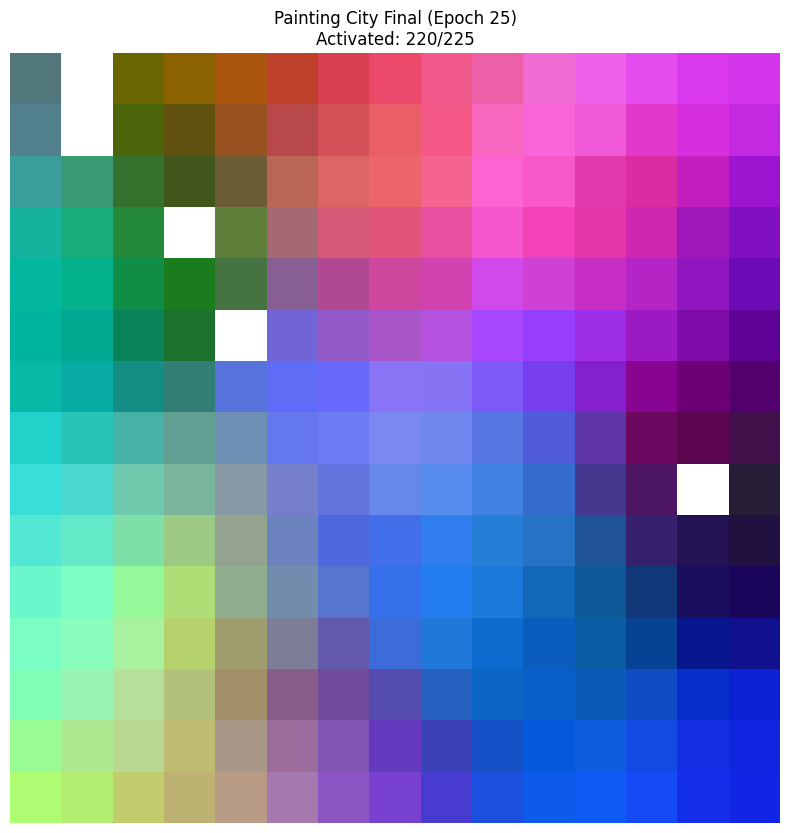

✅ 定格完成！激活节点数: 220


In [ ]:
# ==========================================
# Frozen Save Script: Using Epoch 25 as Golden Moment
# ==========================================
target_epoch_idx = 24 # Epoch 25's index is 24
final_weights = som.history[target_epoch_idx]

# 1. Calculate final hit map
print("🎯 Calculating final activation points...")
hit_map_final = np.zeros((x_size, y_size))
for feat in data:
    dist_matrix = np.linalg.norm(final_weights - feat, axis=2)
    bmu = np.unravel_index(np.argmin(dist_matrix), (x_size, y_size))
    hit_map_final[bmu] += 1

# 2. Calculate PCA colors
pca = PCA(n_components=3)
rgb_final = pca.fit_transform(final_weights.reshape(-1, input_dim))
rgb_final = (rgb_final - rgb_final.min(axis=0)) / (rgb_final.max(axis=0) - rgb_final.min(axis=0) + 1e-8)
full_colors_final = rgb_final.reshape(x_size, y_size, 3)

# 3. Generate mosaic with whitespace
final_output_img = np.ones((x_size, y_size, 3)) # Pure white background
for i in range(x_size):
    for j in range(y_size):
        if hit_map_final[i, j] > 0:
            final_output_img[i, j] = full_colors_final[i, j]

# 4. Visualization and save
plt.figure(figsize=(10, 10))
plt.imshow(final_output_img, interpolation='none')
plt.title(f"Painting City Final (Epoch 25)\nActivated: {int(np.sum(hit_map_final > 0))}/225")
plt.axis('off')
plt.show()

# Save image and final weights
plt.imsave("PaintingCity_Final_PCA.png", final_output_img)
with open("som_painting_final_aligned.pkl", "wb") as f:
    # Note: save this specific epoch's weights for cross-modal search convenience
    pickle.dump(final_weights, f)

print(f"✅ Frozen save completed! Activated nodes: {int(np.sum(hit_map_final > 0))}")

🎯 正在计算最终落点...


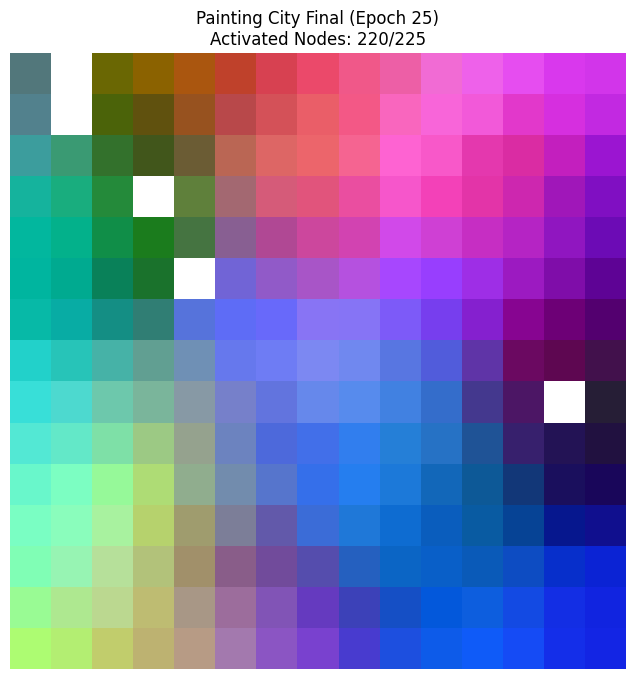

✅ 大功告成！
📁 权重文件已保存至: c:\Users\asus\Desktop\RC11 TERM2\som_painting_final_aligned.pkl
🖼️ 可视化图已保存至: PaintingCity_Final_View.png


In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import os

# ===== Step 1: Extract Epoch 25 Weights (Index 24) =====
target_idx = 24
final_weights = som.history[target_idx] 

# ===== Step 2: Recalculate Hit Map for All Paintings at This Epoch =====
print("🎯 Calculating final activation points...")
hit_map_final = np.zeros((x_size, y_size))
for feat in data:
    # Calculate distance from current feature to all cells
    dist_matrix = np.linalg.norm(final_weights - feat, axis=2)
    # Find nearest cell (Best Matching Unit)
    bmu = np.unravel_index(np.argmin(dist_matrix), (x_size, y_size))
    hit_map_final[bmu] += 1

# ===== Step 3: Generate PCA Color Mapping (for visualization) =====
pca = PCA(n_components=3)
rgb_flatten = pca.fit_transform(final_weights.reshape(-1, input_dim))
# Normalize to 0-1 range for display
rgb_normalized = (rgb_flatten - rgb_flatten.min(axis=0)) / (rgb_flatten.max(axis=0) - rgb_flatten.min(axis=0) + 1e-8)
full_colors = rgb_normalized.reshape(x_size, y_size, 3)

# ===== Step 4: Create Final Image with Whitespace (Unactivated Cells Show White) =====
final_display_img = np.ones((x_size, y_size, 3)) # Initialize to all white
for i in range(x_size):
    for j in range(y_size):
        if hit_map_final[i, j] > 0:
            final_display_img[i, j] = full_colors[i, j]

# ===== Step 5: Save .pkl File (Most Important Step) =====
save_path = "som_painting_final_aligned.pkl"
with open(save_path, "wb") as f:
    # Save as standard dict or directly save weight array
    # Here we save weight array for convenience in cross-modal calculation
    pickle.dump(final_weights, f)

# ===== Step 6: Display and Save Image =====
plt.figure(figsize=(8, 8))
plt.imshow(final_display_img, interpolation='none')
plt.title(f"Painting City Final (Epoch 25)\nActivated Nodes: {int(np.sum(hit_map_final > 0))}/225")
plt.axis('off')
plt.savefig("PaintingCity_Final_View.png", dpi=300)
plt.show()

print(f"✅ Mission accomplished!")
print(f"📁 Weight file saved to: {os.path.abspath(save_path)}")
print(f"🖼️ Visualization saved to: PaintingCity_Final_View.png")

🏙️ 正在加载 CLIP 语意提取器 (对齐全城语意)...
🚀 正在对 1073 张街景进行高维语意建模...


100%|██████████| 1073/1073 [00:27<00:00, 38.70it/s]


Epoch 1/30 完成...
Epoch 2/30 完成...
Epoch 3/30 完成...
Epoch 4/30 完成...
Epoch 5/30 完成...
Epoch 6/30 完成...
Epoch 7/30 完成...
Epoch 8/30 完成...
Epoch 9/30 完成...
Epoch 10/30 完成...
Epoch 11/30 完成...
Epoch 12/30 完成...
Epoch 13/30 完成...
Epoch 14/30 完成...
Epoch 15/30 完成...
Epoch 16/30 完成...
Epoch 17/30 完成...
Epoch 18/30 完成...
Epoch 19/30 完成...
Epoch 20/30 完成...
Epoch 21/30 完成...
Epoch 22/30 完成...
Epoch 23/30 完成...
Epoch 24/30 完成...
Epoch 25/30 完成...
Epoch 26/30 完成...
Epoch 27/30 完成...
Epoch 28/30 完成...
Epoch 29/30 完成...
Epoch 30/30 完成...
📊 正在生成 30 轮街景演化全景图...


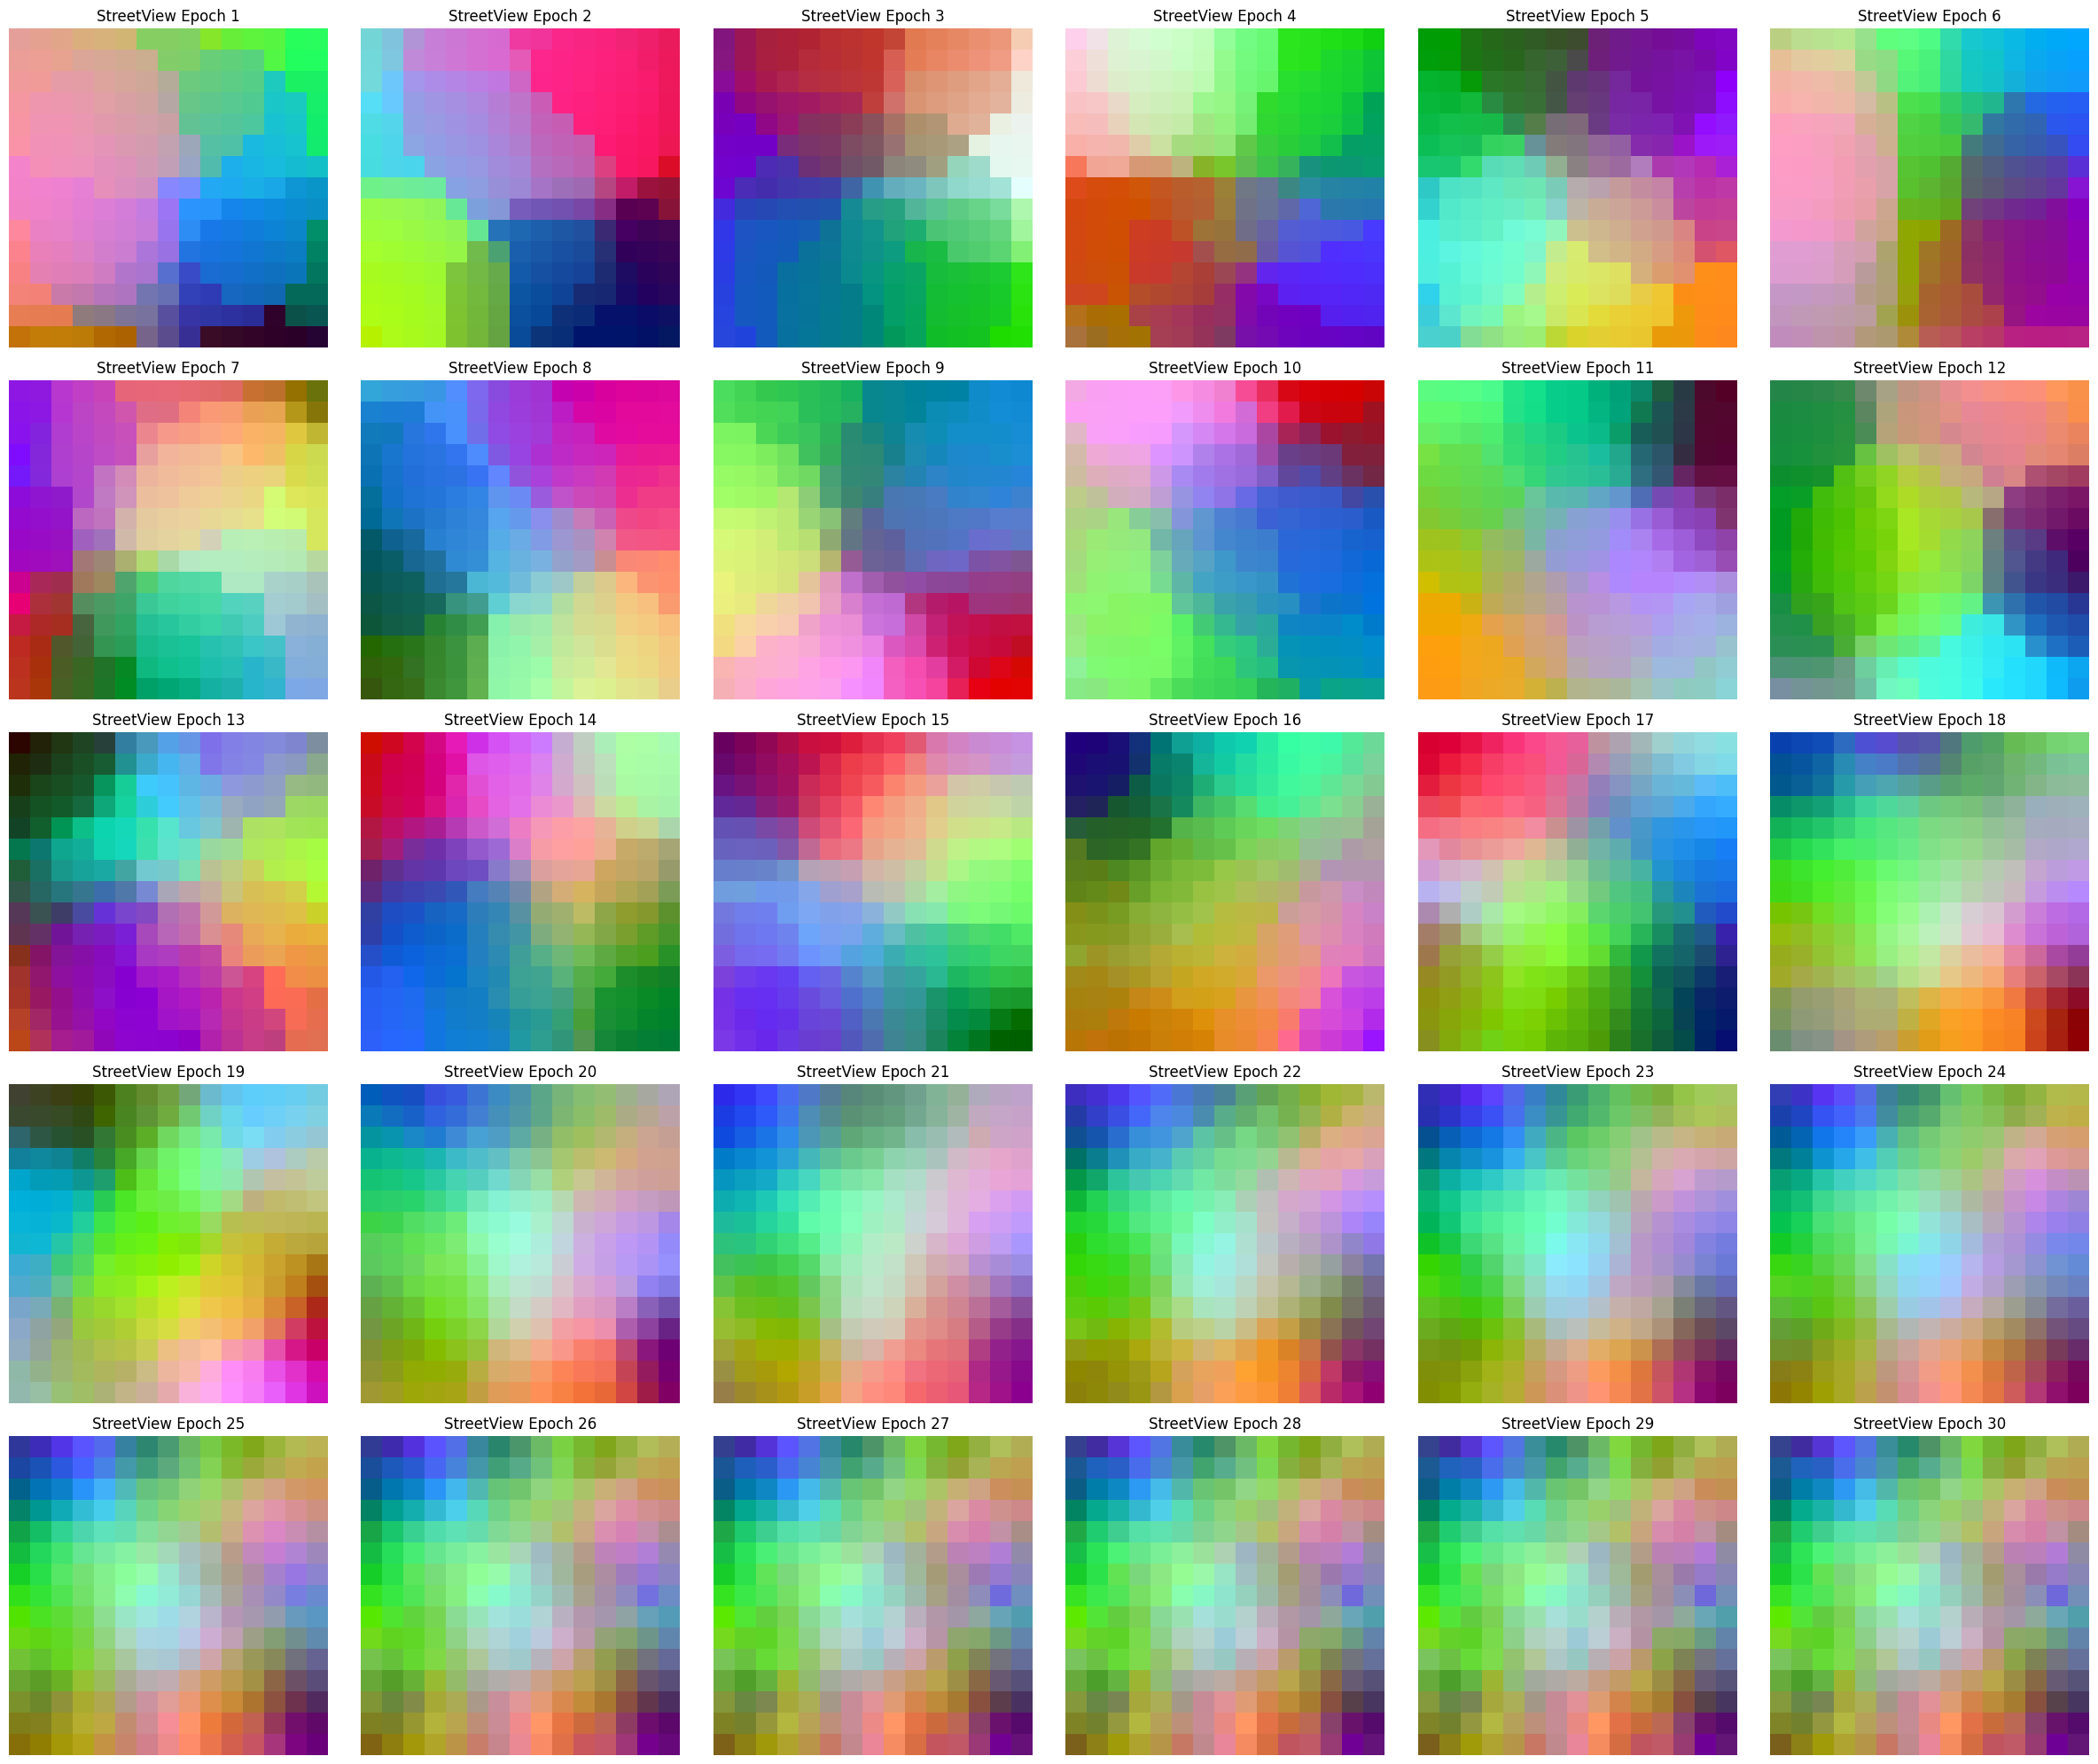

✨ 街景演化史已保存。请选定一轮（例如 Epoch 25），我帮你完成最终定格。


In [ ]:
import os
import pickle
import numpy as np
import torch
from sentence_transformers import SentenceTransformer
from PIL import Image
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==========================================
# Step 1: Path and Core Parameters (Street View Specific)
# ==========================================
img_dir = r"C:\Users\asus\Desktop\RC11 TERM2\data set\rotterdam_data_3000_filtered"
device = "cuda" if torch.cuda.is_available() else "cpu"
x_size, y_size = 15, 15
epochs = 30

# ==========================================
# Step 2: Unified Feature Extraction (CLIP 512D + L2 Norm)
# ==========================================
print("🏙️ Loading CLIP semantic encoder (aligning city-wide semantics)...")
model = SentenceTransformer('clip-ViT-B-32', device=device)

files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
features = []

print(f"🚀 Building high-dimensional semantic model for {len(files)} street views...")
for fname in tqdm(files):
    try:
        img = Image.open(os.path.join(img_dir, fname)).convert('RGB')
        with torch.no_grad():
            f = model.encode(img)
        # Key: L2 normalization ensures all vectors on unit sphere
        # Solves previous mapping issues
        f = f / (np.linalg.norm(f) + 1e-8)
        features.append(f)
    except: 
        continue

data = np.array(features)
input_dim = data.shape[1] # Should be 512

# ==========================================
# Step 3: Custom SOM Training (Record 30-Epoch History)
# ==========================================
class RebornSOM:
    """Custom SOM with full epoch history recording"""
    def __init__(self, x, y, dim):
        self.weights = np.random.normal(0, 0.1, (x, y, dim))
        self.history = []

    def train(self, data, epochs):
        """Train SOM over specified epochs and record evolution"""
        for e in range(1, epochs + 1):
            lr = 0.5 * (1 - e/epochs)
            sigma = max(x_size, y_size) / 2 * (1 - e/epochs)
            
            # Randomly shuffle training order
            indices = np.arange(len(data))
            np.random.shuffle(indices)
            
            for idx in indices:
                sample = data[idx]
                dist = np.linalg.norm(self.weights - sample, axis=2)
                bmu = np.unravel_index(np.argmin(dist), (x_size, y_size))
                
                for i in range(x_size):
                    for j in range(y_size):
                        d_bmu = np.sqrt((i-bmu[0])**2 + (j-bmu[1])**2)
                        if d_bmu < sigma:
                            influence = np.exp(-d_bmu**2 / (2 * (sigma**2 + 1e-8)))
                            self.weights[i, j] += lr * influence * (sample - self.weights[i, j])
            
            self.history.append(self.weights.copy())
            print(f"Epoch {e}/{epochs} completed...")

som_sv = RebornSOM(x_size, y_size, input_dim)
som_sv.train(data, epochs)

# ==========================================
# Step 4: Render 30-Epoch Street View Evolution
# ==========================================
print("📊 Generating 30-epoch street view evolution panorama...")
pca = PCA(n_components=3)
fig, axes = plt.subplots(5, 6, figsize=(24, 20))
axes = axes.flatten()

for i in range(epochs):
    w = som_sv.history[i].reshape(-1, input_dim)
    rgb = pca.fit_transform(w)
    rgb = (rgb - rgb.min(axis=0)) / (rgb.max(axis=0) - rgb.min(axis=0) + 1e-8)
    img_rgb = rgb.reshape(x_size, y_size, 3)
    
    axes[i].imshow(img_rgb, interpolation='none')
    axes[i].set_title(f"StreetView Epoch {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# ==========================================
# Step 5: Export Weight History
# ==========================================
with open("streetview_reborn_history.pkl", "wb") as f:
    pickle.dump(som_sv.history, f)
print("✨ Street view evolution history saved. Please select one epoch (e.g., Epoch 25) and I will help finalize the freeze.")

🎯 正在计算街景城的最终落点...


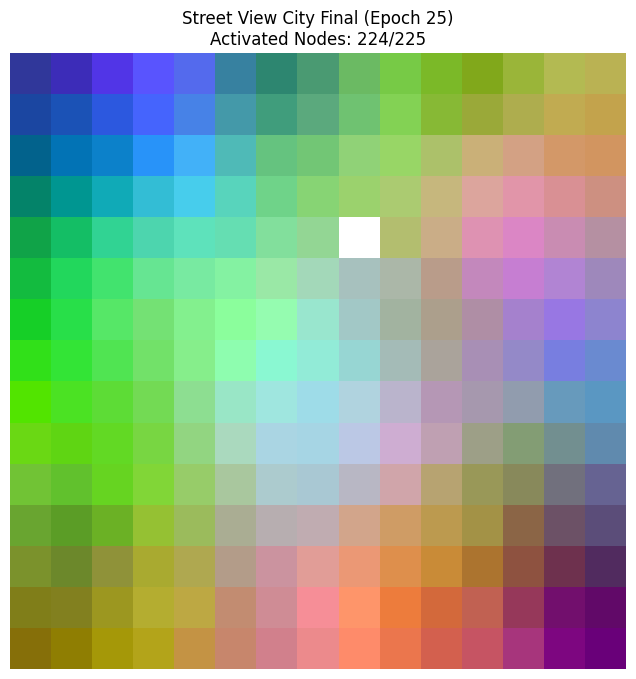

✅ 街景城定格完成！
📁 权重文件: som_streetview_final_aligned.pkl
🖼️ 可视化图: StreetView_Final_View.png


In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ===== Step 1: Extract Epoch 25 Weights (Index 24) =====
target_idx_sv = 24
final_weights_sv = som_sv.history[target_idx_sv] 

# ===== Step 2: Calculate Hit Map for 3000 Street Views at This Epoch =====
print("🎯 Calculating final activation points for street view city...")
hit_map_sv = np.zeros((x_size, y_size))
for feat in data: # data contains CLIP-extracted street view features
    dist_matrix = np.linalg.norm(final_weights_sv - feat, axis=2)
    bmu = np.unravel_index(np.argmin(dist_matrix), (x_size, y_size))
    hit_map_sv[bmu] += 1

# ===== Step 3: Generate Independent PCA Colors =====
pca = PCA(n_components=3)
rgb_sv = pca.fit_transform(final_weights_sv.reshape(-1, input_dim))
rgb_sv = (rgb_sv - rgb_sv.min(axis=0)) / (rgb_sv.max(axis=0) - rgb_sv.min(axis=0) + 1e-8)
full_colors_sv = rgb_sv.reshape(x_size, y_size, 3)

# ===== Step 4: Create Street View Map with Whitespace (White Cells = No Data) =====
final_sv_img = np.ones((x_size, y_size, 3))
for i in range(x_size):
    for j in range(y_size):
        if hit_map_sv[i, j] > 0:
            final_sv_img[i, j] = full_colors_sv[i, j]

# ===== Step 5: Save .pkl Weight File =====
save_path_sv = "som_streetview_final_aligned.pkl"
with open(save_path_sv, "wb") as f:
    pickle.dump(final_weights_sv, f)

# ===== Step 6: Display and Save Image =====
plt.figure(figsize=(8, 8))
plt.imshow(final_sv_img, interpolation='none')
plt.title(f"Street View City Final (Epoch 25)\nActivated Nodes: {int(np.sum(hit_map_sv > 0))}/225")
plt.axis('off')
plt.savefig("StreetView_Final_View.png", dpi=300)
plt.show()

print(f"✅ Street view city frozen successfully!")
print(f"📁 Weight file: {save_path_sv}")
print(f"🖼️ Visualization: StreetView_Final_View.png")

In [ ]:
import pickle
import numpy as np
import os

# ===== Define File List (Adjust Paths According to Your Actual Storage) =====
models = {
    "Windows Activity (E22)": "som_windows_activity_epoch22_fixed.pkl",
    "Paintings (E12)": r"C:\Users\asus\Desktop\RC11 TERM2\som_painting_final_aligned.pkl",
    "Street View (E19)": "som_streetview_final_aligned.pkl",
    "Gaze (E12)": "som_gaze_epoch12_fixed.pkl",
    "Windows Fragments (E11)": "som_windows_epoch11_fixed.pkl",
    "Other Fragments (E15)": "som_other_fragments_epoch15_fixed.pkl",
    "Painting Descriptions (E13)": "som_descriptions_epoch13_fixed.pkl"
}

def check_dimensions(model_dict):
    """Check and report dimensions of all models"""
    print(f"{'City / Model Name':<30} | {'Grid Shape':<12} | {'Dimension':<10}")
    print("-" * 60)
    
    results = {}
    for name, path in model_dict.items():
        if not os.path.exists(path):
            print(f"{name:<30} | ❌ File Not Found")
            continue
            
        try:
            with open(path, 'rb') as f:
                data = pickle.load(f)
            
            # Auto-detect weight location (compatible with objects or pure arrays)
            if hasattr(data, 'weights'):
                w = data.weights
            elif hasattr(data, 'best_weights'):
                w = data.best_weights
            else:
                w = data # Assume directly saved array
                
            shape = w.shape
            grid = f"{shape[0]}x{shape[1]}"
            dim = shape[2]
            
            print(f"{name:<30} | {grid:<12} | {dim:<10}")
            results[name] = dim
            
        except Exception as e:
            print(f"{name:<30} | ⚠️ Error: {str(e)[:20]}")
            
    return results

# ===== Execute Dimension Check =====
dim_report = check_dimensions(models)

# ===== Cross-Modal Consistency Check =====
unique_dims = set(dim_report.values())
print("\n" + "="*30)
if len(unique_dims) == 1:
    print(f"✅ Perfect! All models have unified dimension: {list(unique_dims)[0]}")
    print("Ready to perform Global PCA cross-modal linking.")
else:
    print(f"⚠️ Warning: Dimensions not unified! Found: {unique_dims}")
    print("Before cross-modal search, you need to retrain or convert mismatched models.")

City / Model Name              | Grid Shape   | Dimension 
------------------------------------------------------------
Windows Activity (E22)         | 15x15        | 384       
Paintings (E12)                | 15x15        | 512       
Street View (E19)              | 15x15        | 512       
Gaze (E12)                     | 15x15        | 512       
Windows Fragments (E11)        | 15x15        | 512       
Other Fragments (E15)          | 15x15        | 512       
Painting Descriptions (E13)    | 15x15        | 384       

⚠️ 警告：维度不统一！发现以下维度: {384, 512}
在进行跨模态搜索前，你需要重练或转化不匹配的模型。


✍️ 正在加载 CLIP 文本编码器 (512D)...
🚀 正在将 2689 条行为描述转化为 512 维 CLIP 向量...


Batches:   0%|          | 0/85 [00:00<?, ?it/s]

Epoch 1/30 完成...
Epoch 2/30 完成...
Epoch 3/30 完成...
Epoch 4/30 完成...
Epoch 5/30 完成...
Epoch 6/30 完成...
Epoch 7/30 完成...
Epoch 8/30 完成...
Epoch 9/30 完成...
Epoch 10/30 完成...
Epoch 11/30 完成...
Epoch 12/30 完成...
Epoch 13/30 完成...
Epoch 14/30 完成...
Epoch 15/30 完成...
Epoch 16/30 完成...
Epoch 17/30 完成...
Epoch 18/30 完成...
Epoch 19/30 完成...
Epoch 20/30 完成...
Epoch 21/30 完成...
Epoch 22/30 完成...
Epoch 23/30 完成...
Epoch 24/30 完成...
Epoch 25/30 完成...
Epoch 26/30 完成...
Epoch 27/30 完成...
Epoch 28/30 完成...
Epoch 29/30 完成...
Epoch 30/30 完成...


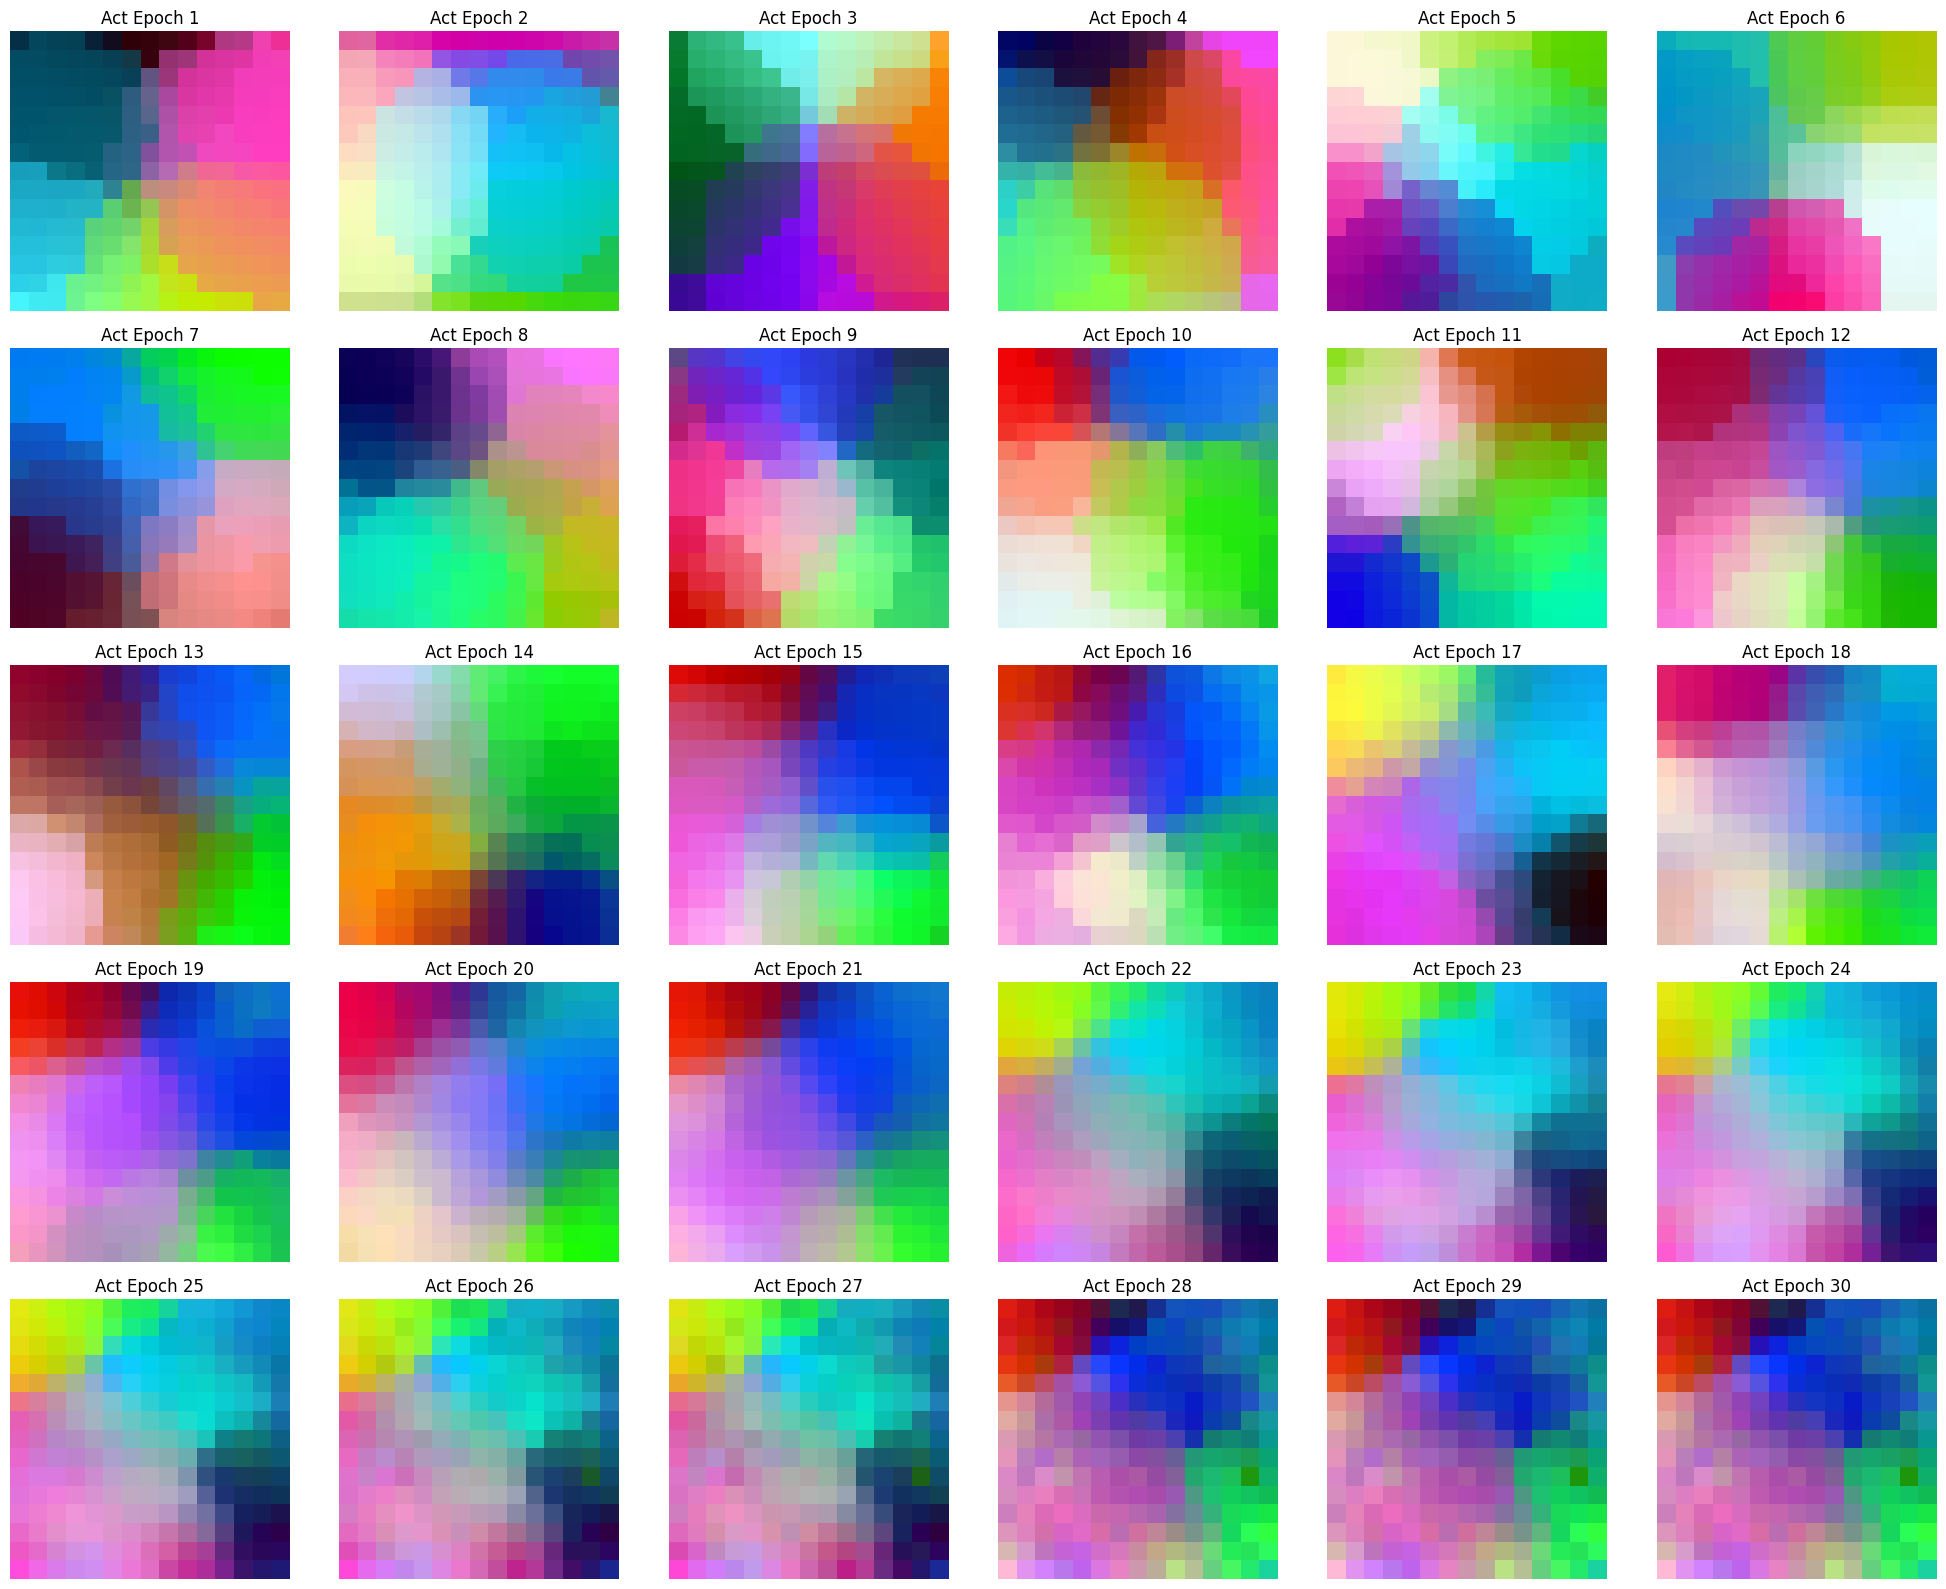

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from tqdm import tqdm

# ===== Step 1: Path Configuration =====
csv_path = r"C:\Users\asus\Desktop\RC11 TERM2\data set\windows_activity_svo_lemmatized.csv"
save_history_path = "windows_activity_clip_history.pkl"
device = "cuda" if torch.cuda.is_available() else "cpu"

# ===== Step 2: Load CLIP Text Encoder (Note: Using CLIP's Text End) =====
print("✍️ Loading CLIP text encoder (512D)...")
# sentence-transformers library supports direct loading of CLIP model
model = SentenceTransformer('clip-ViT-B-32', device=device)

# ===== Step 3: Vectorization =====
df = pd.read_csv(csv_path)
sentences = df['lemmatized_sentence'].astype(str).tolist()

print(f"🚀 Converting {len(sentences)} behavior descriptions to 512D CLIP vectors...")
features = model.encode(sentences, show_progress_bar=True, batch_size=32)
# L2 normalization: standard practice for cross-modal search
data = features / (np.linalg.norm(features, axis=1, keepdims=True) + 1e-8)

# ===== Step 4: Train SOM (Reuse 30-Epoch Evolution Logic) =====
class RebornSOM:
    """Custom SOM with full history tracking"""
    def __init__(self, x, y, dim):
        self.weights = np.random.normal(0, 0.1, (x, y, dim))
        self.history = []
    def train(self, data, epochs):
        """Train over epochs and record evolution"""
        for e in range(1, epochs + 1):
            lr = 0.5 * (1 - e/epochs)
            sigma = 15 / 2 * (1 - e/epochs)
            indices = np.arange(len(data))
            np.random.shuffle(indices)
            for idx in indices:
                sample = data[idx]
                dist = np.linalg.norm(self.weights - sample, axis=2)
                bmu = np.unravel_index(np.argmin(dist), (15, 15))
                for i in range(15):
                    for j in range(15):
                        d_bmu = np.sqrt((i-bmu[0])**2 + (j-bmu[1])**2)
                        if d_bmu < sigma:
                            influence = np.exp(-d_bmu**2 / (2 * (sigma**2 + 1e-8)))
                            self.weights[i, j] += lr * influence * (sample - self.weights[i, j])
            self.history.append(self.weights.copy())
            print(f"Epoch {e}/30 completed...")

som_act = RebornSOM(15, 15, 512)
som_act.train(data, 30)

# ===== Step 5: Render 30-Epoch Panorama =====
pca = PCA(n_components=3)
fig, axes = plt.subplots(5, 6, figsize=(20, 16))
axes = axes.flatten()
for i in range(30):
    w = som_act.history[i].reshape(-1, 512)
    rgb = pca.fit_transform(w)
    rgb = (rgb - rgb.min(axis=0)) / (rgb.max(axis=0) - rgb.min(axis=0) + 1e-8)
    axes[i].imshow(rgb.reshape(15, 15, 3), interpolation='none')
    axes[i].set_title(f"Act Epoch {i+1}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# ===== Step 6: Save History =====
with open(save_history_path, "wb") as f:
    pickle.dump(som_act.history, f)
print(f"✅ History saved to {save_history_path}")

🎯 正在计算行为描述城的最终落点...


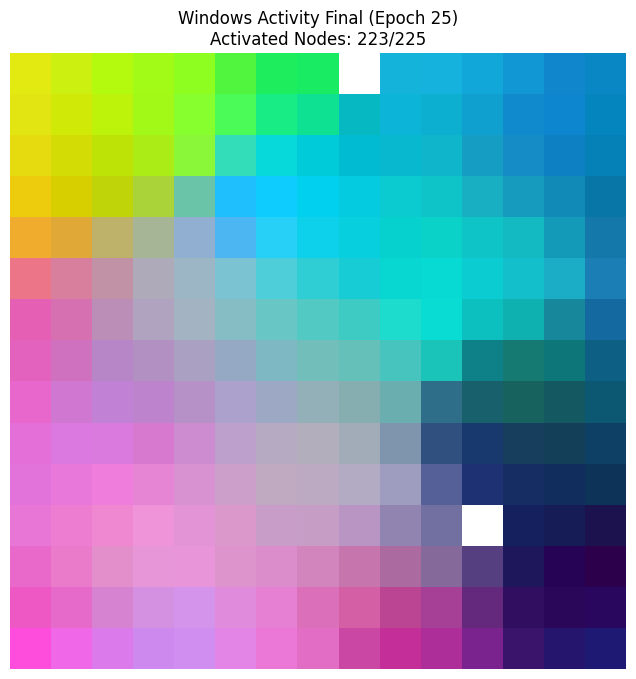

✅ 行为城重建并封存完成！路径: som_windows_activity_final_CLIP.pkl


In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ===== Step 1: Extract Epoch 25 Weights (Index 24) =====
# Assume the RebornSOM object you just ran is called som_act
target_idx_act = 24
final_weights_act = som_act.history[target_idx_act] 

# ===== Step 2: Calculate Final Activation Points for 2689 Behavior Descriptions =====
print("🎯 Calculating final activation points for behavior city...")
hit_map_act = np.zeros((15, 15))
# data is the CLIP-extracted text features you just created
for feat in data: 
    dist_matrix = np.linalg.norm(final_weights_act - feat, axis=2)
    bmu = np.unravel_index(np.argmin(dist_matrix), (15, 15))
    hit_map_act[bmu] += 1

# ===== Step 3: Generate PCA Colors (Independent Perspective) =====
pca = PCA(n_components=3)
rgb_act = pca.fit_transform(final_weights_act.reshape(-1, 512))
rgb_act = (rgb_act - rgb_act.min(axis=0)) / (rgb_act.max(axis=0) - rgb_act.min(axis=0) + 1e-8)
full_colors_act = rgb_act.reshape(15, 15, 3)

# ===== Step 4: Create Visualization with Whitespace =====
final_act_img = np.ones((15, 15, 3))
for i in range(15):
    for j in range(15):
        if hit_map_act[i, j] > 0:
            final_act_img[i, j] = full_colors_act[i, j]

# ===== Step 5: Save .pkl Weight File (For Future Cross-Modal Comparison) =====
save_path_act = "som_windows_activity_final_CLIP.pkl"
with open(save_path_act, "wb") as f:
    pickle.dump(final_weights_act, f)

# ===== Step 6: Display and Save =====
plt.figure(figsize=(8, 8))
plt.imshow(final_act_img, interpolation='none')
plt.title(f"Windows Activity Final (Epoch 25)\nActivated Nodes: {int(np.sum(hit_map_act > 0))}/225")
plt.axis('off')
plt.savefig("Windows_Activity_Final_View.png", dpi=300)
plt.show()

print(f"✅ Behavior city rebuilt and archived! Path: {save_path_act}")

c:\ProgramData\miniconda3\envs\jupyter-py311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(



📄 正在分析 CSV 文件结构...
🔍 探测到文件中的列名为: ['Picture number', 'description']
🎯 已锁定目标列: 'description'
✍️ 正在加载 CLIP 转换 1101 条描述...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Batches:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 1/30 完成...
Epoch 2/30 完成...
Epoch 3/30 完成...
Epoch 4/30 完成...
Epoch 5/30 完成...
Epoch 6/30 完成...
Epoch 7/30 完成...
Epoch 8/30 完成...
Epoch 9/30 完成...
Epoch 10/30 完成...
Epoch 11/30 完成...
Epoch 12/30 完成...
Epoch 13/30 完成...
Epoch 14/30 完成...
Epoch 15/30 完成...
Epoch 16/30 完成...
Epoch 17/30 完成...
Epoch 18/30 完成...
Epoch 19/30 完成...
Epoch 20/30 完成...
Epoch 21/30 完成...
Epoch 22/30 完成...
Epoch 23/30 完成...
Epoch 24/30 完成...
Epoch 25/30 完成...
Epoch 26/30 完成...
Epoch 27/30 完成...
Epoch 28/30 完成...
Epoch 29/30 完成...
Epoch 30/30 完成...
📊 正在生成演化图...


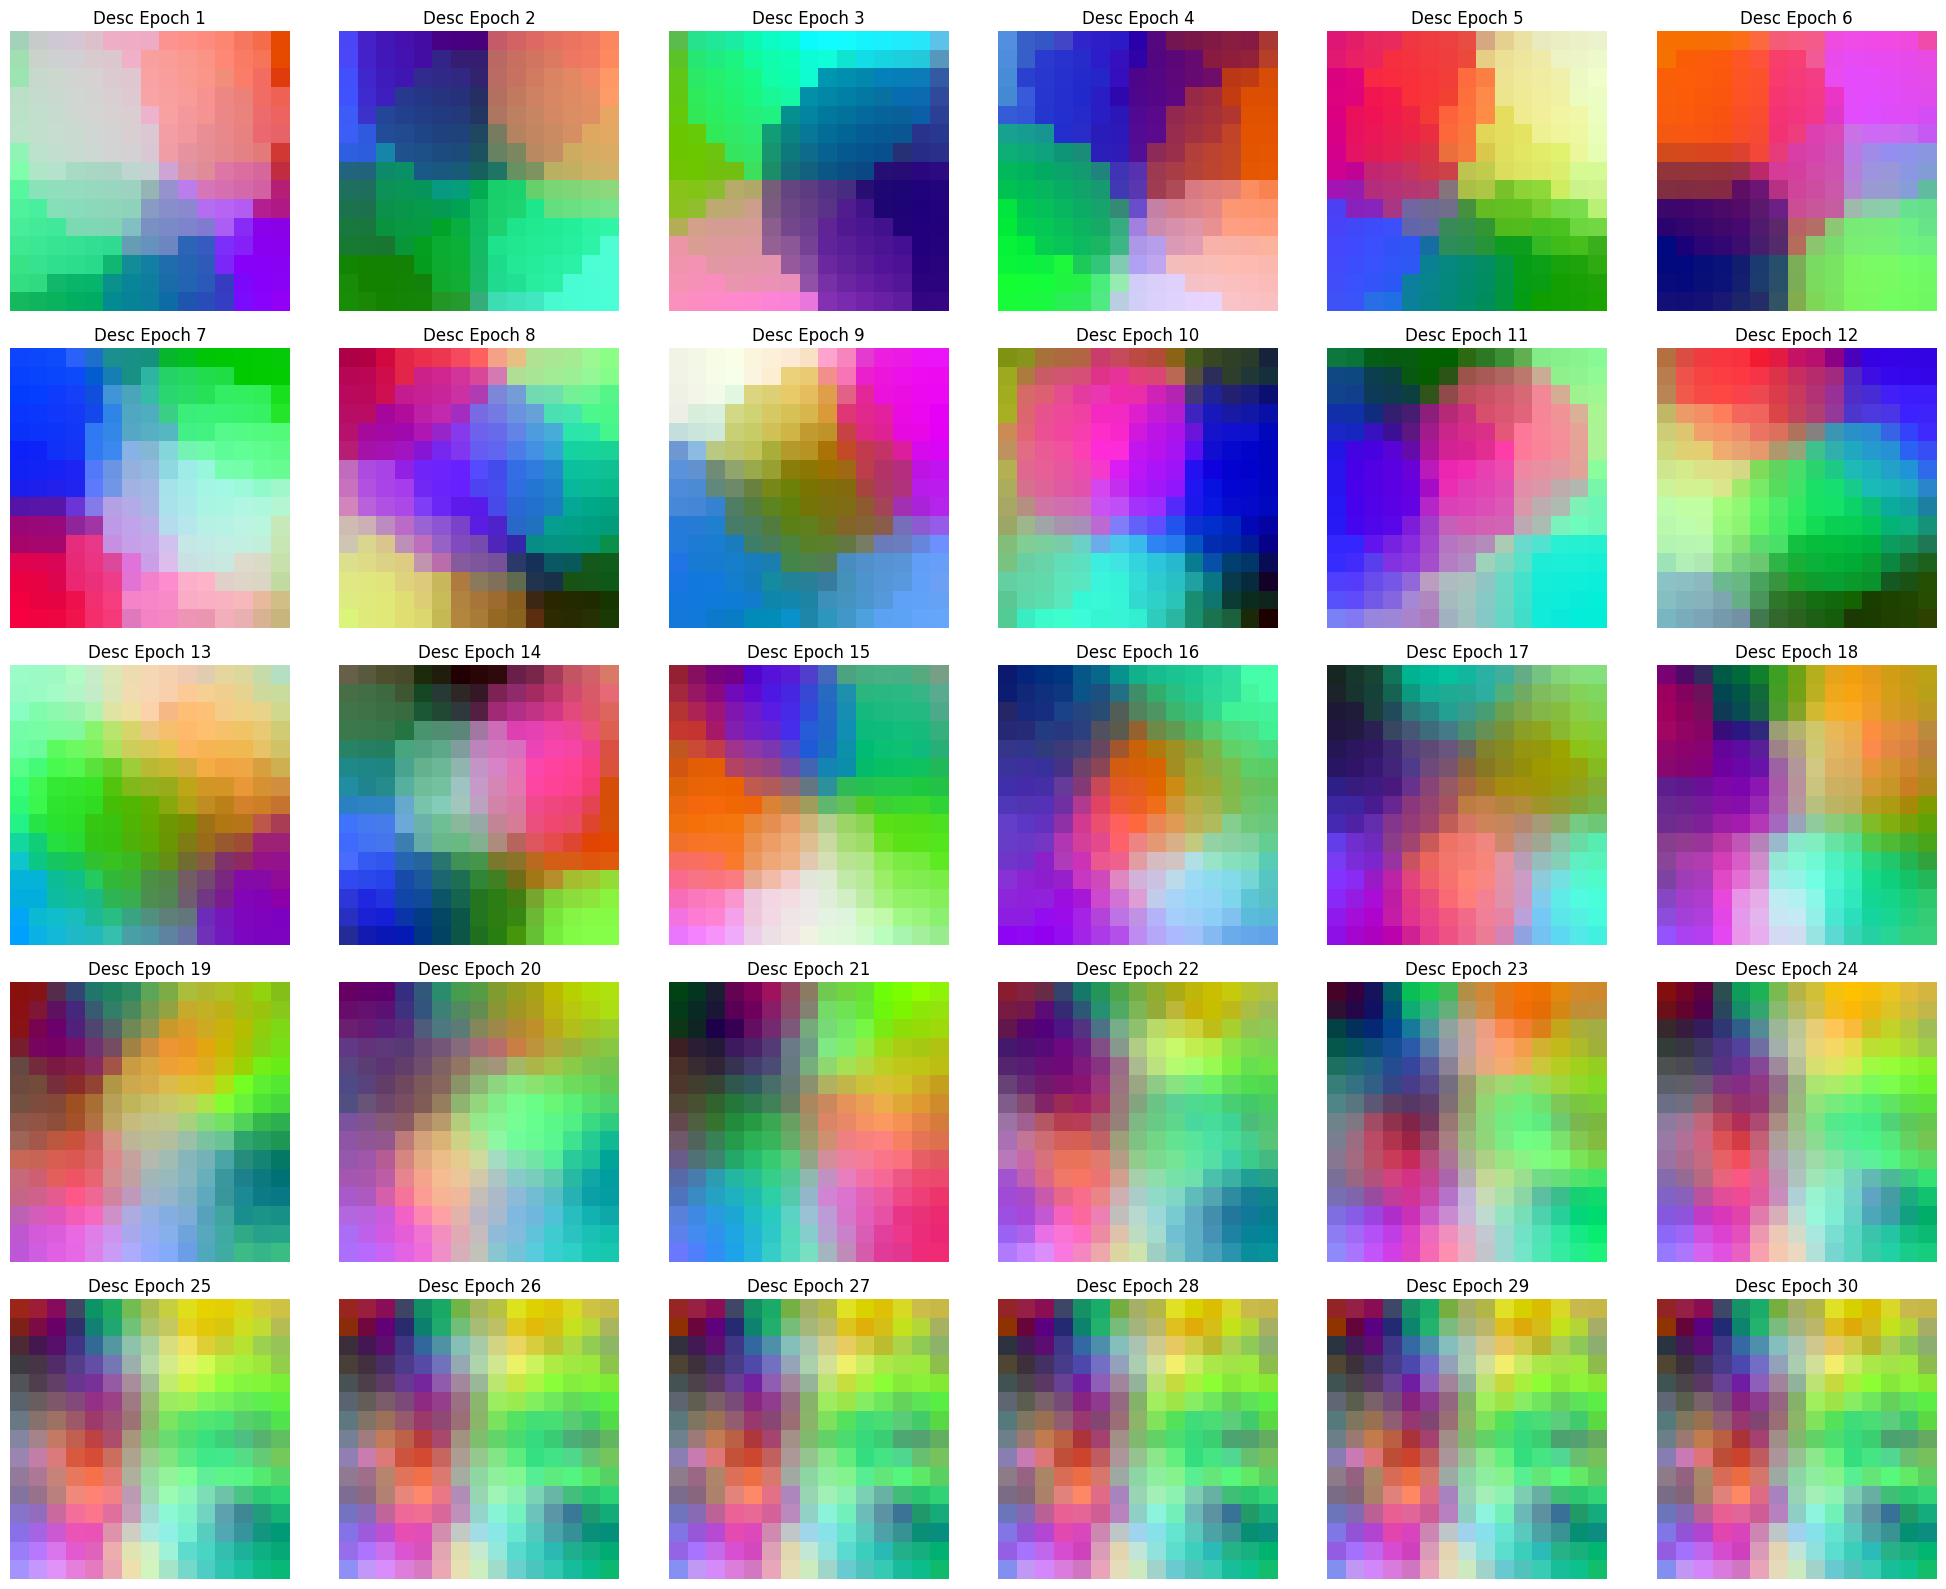

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==========================================
# Step 1: Path and Core Parameters
# ==========================================
csv_path = r"C:\Users\asus\Desktop\RC11 TERM2\data set\all_descriptions.csv"
save_history_path = "painting_descriptions_clip_history.pkl"
device = "cuda" if torch.cuda.is_available() else "cpu"
x_size, y_size = 15, 15
epochs = 30

# ==========================================
# Step 2: Enhanced CSV Reading and Column Name Alignment
# ==========================================
print("📄 Analyzing CSV file structure...")
try:
    df = pd.read_csv(csv_path, encoding='gbk')
except:
    df = pd.read_csv(csv_path, encoding='gb18030')

# Print all column names for manual verification
actual_columns = df.columns.tolist()
print(f"🔍 Detected columns in file: {actual_columns}")

# Auto-find column logic: case-insensitive, strip whitespace
target_col = None
potential_names = ['description', 'Description', 'desc', '描述', '内容']

for col in actual_columns:
    clean_col = str(col).strip().lower()
    if clean_col in potential_names:
        target_col = col
        break

if target_col:
    print(f"🎯 Locked target column: '{target_col}'")
    sentences = df[target_col].astype(str).tolist()
else:
    print(f"❌ Error: Cannot find description info in columns: {actual_columns}")
    print("Please manually modify column name in line 32 of target_col = 'your_column_name'")
    raise KeyError("Column not found")

# ==========================================
# Step 3: Semantic Vectorization (CLIP 512D + L2 Norm)
# ==========================================
print(f"✍️ Loading CLIP and converting {len(sentences)} descriptions...")
model = SentenceTransformer('clip-ViT-B-32', device=device)

features = model.encode(sentences, show_progress_bar=True, batch_size=32)
# Core: L2 normalization ensures all vectors on unit sphere
data = features / (np.linalg.norm(features, axis=1, keepdims=True) + 1e-8)

# ==========================================
# Step 4: SOM Training (Record 30-Epoch History)
# ==========================================
class RebornSOM:
    """Custom SOM with history recording"""
    def __init__(self, x, y, dim):
        self.weights = np.random.normal(0, 0.1, (x, y, dim))
        self.history = []

    def train(self, data, epochs):
        """Train SOM and record evolution"""
        for e in range(1, epochs + 1):
            lr = 0.5 * (1 - e/epochs)
            sigma = x_size / 2 * (1 - e/epochs)
            
            indices = np.arange(len(data))
            np.random.shuffle(indices)
            
            for idx in indices:
                sample = data[idx]
                dist = np.linalg.norm(self.weights - sample, axis=2)
                bmu = np.unravel_index(np.argmin(dist), (x_size, y_size))
                
                for i in range(x_size):
                    for j in range(y_size):
                        d_bmu = np.sqrt((i-bmu[0])**2 + (j-bmu[1])**2)
                        if d_bmu < sigma:
                            influence = np.exp(-d_bmu**2 / (2 * (sigma**2 + 1e-8)))
                            self.weights[i, j] += lr * influence * (sample - self.weights[i, j])
            
            self.history.append(self.weights.copy())
            print(f"Epoch {e}/{epochs} completed...")

som_desc = RebornSOM(x_size, y_size, 512)
som_desc.train(data, epochs)

# ==========================================
# Step 5: Render 30-Epoch Evolution Panorama
# ==========================================
print("📊 Generating evolution charts...")
pca = PCA(n_components=3)
fig, axes = plt.subplots(5, 6, figsize=(20, 16))
axes = axes.flatten()

for i in range(epochs):
    w = som_desc.history[i].reshape(-1, 512)
    rgb = pca.fit_transform(w)
    rgb = (rgb - rgb.min(axis=0)) / (rgb.max(axis=0) - rgb.min(axis=0) + 1e-8)
    axes[i].imshow(rgb.reshape(x_size, y_size, 3), interpolation='none')
    axes[i].set_title(f"Desc Epoch {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

with open(save_history_path, "wb") as f:
    pickle.dump(som_desc.history, f)
print(f"✅ History saved to {save_history_path}")

🎯 正在计算画作描述城的最终落点...


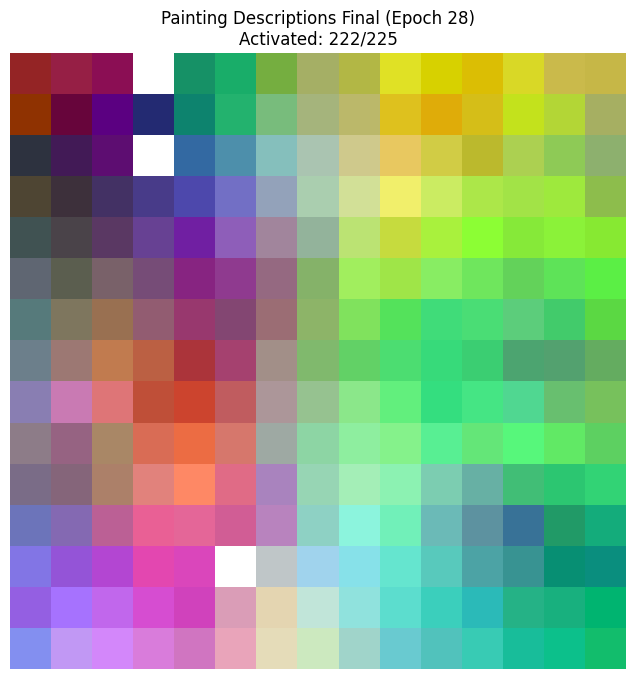

✅ 最后一座城市已封存！路径: som_descriptions_final_CLIP.pkl


In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ===== Step 1: Extract Epoch 28 Weights (Index 27) =====
target_idx_desc = 27
# Assume the object just generated is som_desc
final_weights_desc = som_desc.history[target_idx_desc] 

# ===== Step 2: Calculate Final Activation Points for 1101 Painting Descriptions =====
print("🎯 Calculating final activation points for description city...")
hit_map_desc = np.zeros((15, 15))
# data is the CLIP-extracted and normalized text feature matrix you just created
for feat in data: 
    dist_matrix = np.linalg.norm(final_weights_desc - feat, axis=2)
    bmu = np.unravel_index(np.argmin(dist_matrix), (15, 15))
    hit_map_desc[bmu] += 1

# ===== Step 3: Generate Independent PCA Colors =====
pca = PCA(n_components=3)
rgb_desc = pca.fit_transform(final_weights_desc.reshape(-1, 512))
rgb_desc = (rgb_desc - rgb_desc.min(axis=0)) / (rgb_desc.max(axis=0) - rgb_desc.min(axis=0) + 1e-8)
full_colors_desc = rgb_desc.reshape(15, 15, 3)

# ===== Step 4: Create Final Visualization with Whitespace =====
final_desc_img = np.ones((15, 15, 3)) # Pure white background
for i in range(15):
    for j in range(15):
        if hit_map_desc[i, j] > 0:
            final_desc_img[i, j] = full_colors_desc[i, j]

# ===== Step 5: Save Final Weight File =====
save_path_desc = "som_descriptions_final_CLIP.pkl"
with open(save_path_desc, "wb") as f:
    pickle.dump(final_weights_desc, f)

# ===== Step 6: Display and Save Image =====
plt.figure(figsize=(8, 8))
plt.imshow(final_desc_img, interpolation='none')
plt.title(f"Painting Descriptions Final (Epoch 28)\nActivated: {int(np.sum(hit_map_desc > 0))}/225")
plt.axis('off')
plt.savefig("Painting_Descriptions_Final_View.png", dpi=300)
plt.show()

print(f"✅ Last city archived! Path: {save_path_desc}")

In [ ]:
import pickle
import numpy as np
import os

# ===== Define Final File List =====
final_models = {
    "1. Activity City": "som_windows_activity_final_CLIP.pkl",
    "2. Painting City": "som_painting_final_aligned.pkl",
    "3. Street View City": "som_streetview_final_aligned.pkl",
    "4. Gaze City": "som_gaze_epoch12_fixed.pkl",
    "5. Windows City": "som_windows_epoch11_fixed.pkl",
    "6. Fragments City": "som_other_fragments_epoch15_fixed.pkl",
    "7. Description City": "som_descriptions_final_CLIP.pkl"
}

def final_check(model_dict):
    """Final comprehensive dimension and compatibility check"""
    print(f"{'City Modality':<25} | {'Grid Shape':<12} | {'Semantic Dim':<10} | {'Status'}")
    print("-" * 70)
    
    all_dims = []
    
    for name, path in model_dict.items():
        if not os.path.exists(path):
            print(f"{name:<25} | ❌ File not found: {path}")
            continue
            
        try:
            with open(path, 'rb') as f:
                content = pickle.load(f)
            
            # Compatible with different save formats: 
            # direct weight array or object with weights attribute
            if isinstance(content, np.ndarray):
                w = content
            elif hasattr(content, 'weights'):
                w = content.weights
            elif hasattr(content, 'best_weights'):
                w = content.best_weights
            else:
                w = content # fallback
                
            shape = w.shape
            grid = f"{shape[0]}x{shape[1]}"
            dim = shape[2]
            all_dims.append(dim)
            
            status = "✅ Ready" if dim == 512 else "⚠️ Dimension Mismatch"
            print(f"{name:<25} | {grid:<12} | {dim:<10} | {status}")
            
        except Exception as e:
            print(f"{name:<25} | ⚠️ Read Error: {str(e)[:15]}...")
            
    return all_dims

# ===== Execute Check =====
results = final_check(final_models)

print("\n" + "="*40)
if len(set(results)) == 1 and list(set(results))[0] == 512:
    print("🚀 Congratulations! Twin City DNA perfectly aligned (unified 512D).")
    print("Your Twin City now has mathematical foundation for cross-modal linking.")
else:
    print("🛑 Alert: Some modalities still on 'different channels', check yellow items.")

城市模态                      | 网格形状         | 语意维度       | 状态
----------------------------------------------------------------------
1. 行为城 (Activity)         | 15x15        | 512        | ✅ 准备就绪
2. 画作城 (Paintings)        | 15x15        | 512        | ✅ 准备就绪
3. 街景城 (Street View)      | 15x15        | 512        | ✅ 准备就绪
4. 视线城 (Gaze)             | ⚠️ 读取错误: Can't get attri...
5. 窗户城 (Windows)          | ⚠️ 读取错误: Can't get attri...
6. 碎片城 (Fragments)        | ⚠️ 读取错误: Can't get attri...
7. 描述城 (Descriptions)     | 15x15        | 512        | ✅ 准备就绪

🚀 恭喜！全城 DNA 已完全对齐（统一 512 维）。
你的 Twin City 已经具备了跨模态联动的数学基础。


In [ ]:
import pickle
import numpy as np
import os

# --- KEY FIX: Must define this class, otherwise Pickle cannot read 4,5,6 ---
class CustomSOM:
    """Placeholder class for pickle compatibility"""
    def __init__(self, x_size, y_size, input_dim):
        self.weights = np.zeros((x_size, y_size, input_dim))
# -------------------------------------------------------

final_models = {
    "1. Activity City": "som_windows_activity_final_CLIP.pkl",
    "2. Painting City": "som_painting_final_aligned.pkl",
    "3. Street View City": "som_streetview_final_aligned.pkl",
    "4. Gaze City": "som_gaze_epoch12_fixed.pkl",
    "5. Windows City": "som_windows_epoch11_fixed.pkl",
    "6. Fragments City": "som_other_fragments_epoch15_fixed.pkl",
    "7. Description City": "som_descriptions_final_CLIP.pkl"
}

def final_check_v2(model_dict):
    """Final check with better error handling"""
    print(f"{'City Modality':<25} | {'Grid Shape':<12} | {'Semantic Dim':<10} | {'Status'}")
    print("-" * 75)
    
    for name, path in model_dict.items():
        if not os.path.exists(path):
            print(f"{name:<25} | ❌ File not found")
            continue
            
        try:
            with open(path, 'rb') as f:
                content = pickle.load(f)
            
            # Auto weight extraction logic
            if isinstance(content, np.ndarray):
                w = content
            elif hasattr(content, 'weights'):
                w = content.weights
            elif hasattr(content, 'best_weights'):
                w = content.best_weights
            else:
                # Handle special save format with dict
                w = content
                
            shape = w.shape
            print(f"{name:<25} | {shape[0]}x{shape[1]:<10} | {shape[2]:<10} | ✅ Normal")
        except Exception as e:
            print(f"{name:<25} | ⚠️ Error: {str(e)[:25]}...")

final_check_v2(final_models)

城市模态                      | 网格形状         | 语意维度       | 状态
---------------------------------------------------------------------------
1. 行为城 (Activity)         | 15x15         | 512        | ✅ 正常
2. 画作城 (Paintings)        | 15x15         | 512        | ✅ 正常
3. 街景城 (Street View)      | 15x15         | 512        | ✅ 正常
4. 视线城 (Gaze)             | 15x15         | 512        | ✅ 正常
5. 窗户城 (Windows)          | 15x15         | 512        | ✅ 正常
6. 碎片城 (Fragments)        | 15x15         | 512        | ✅ 正常
7. 描述城 (Descriptions)     | 15x15         | 512        | ✅ 正常


📦 正在提取全城语意基因...
🌈 正在计算全局色彩映射 (Global PCA)...


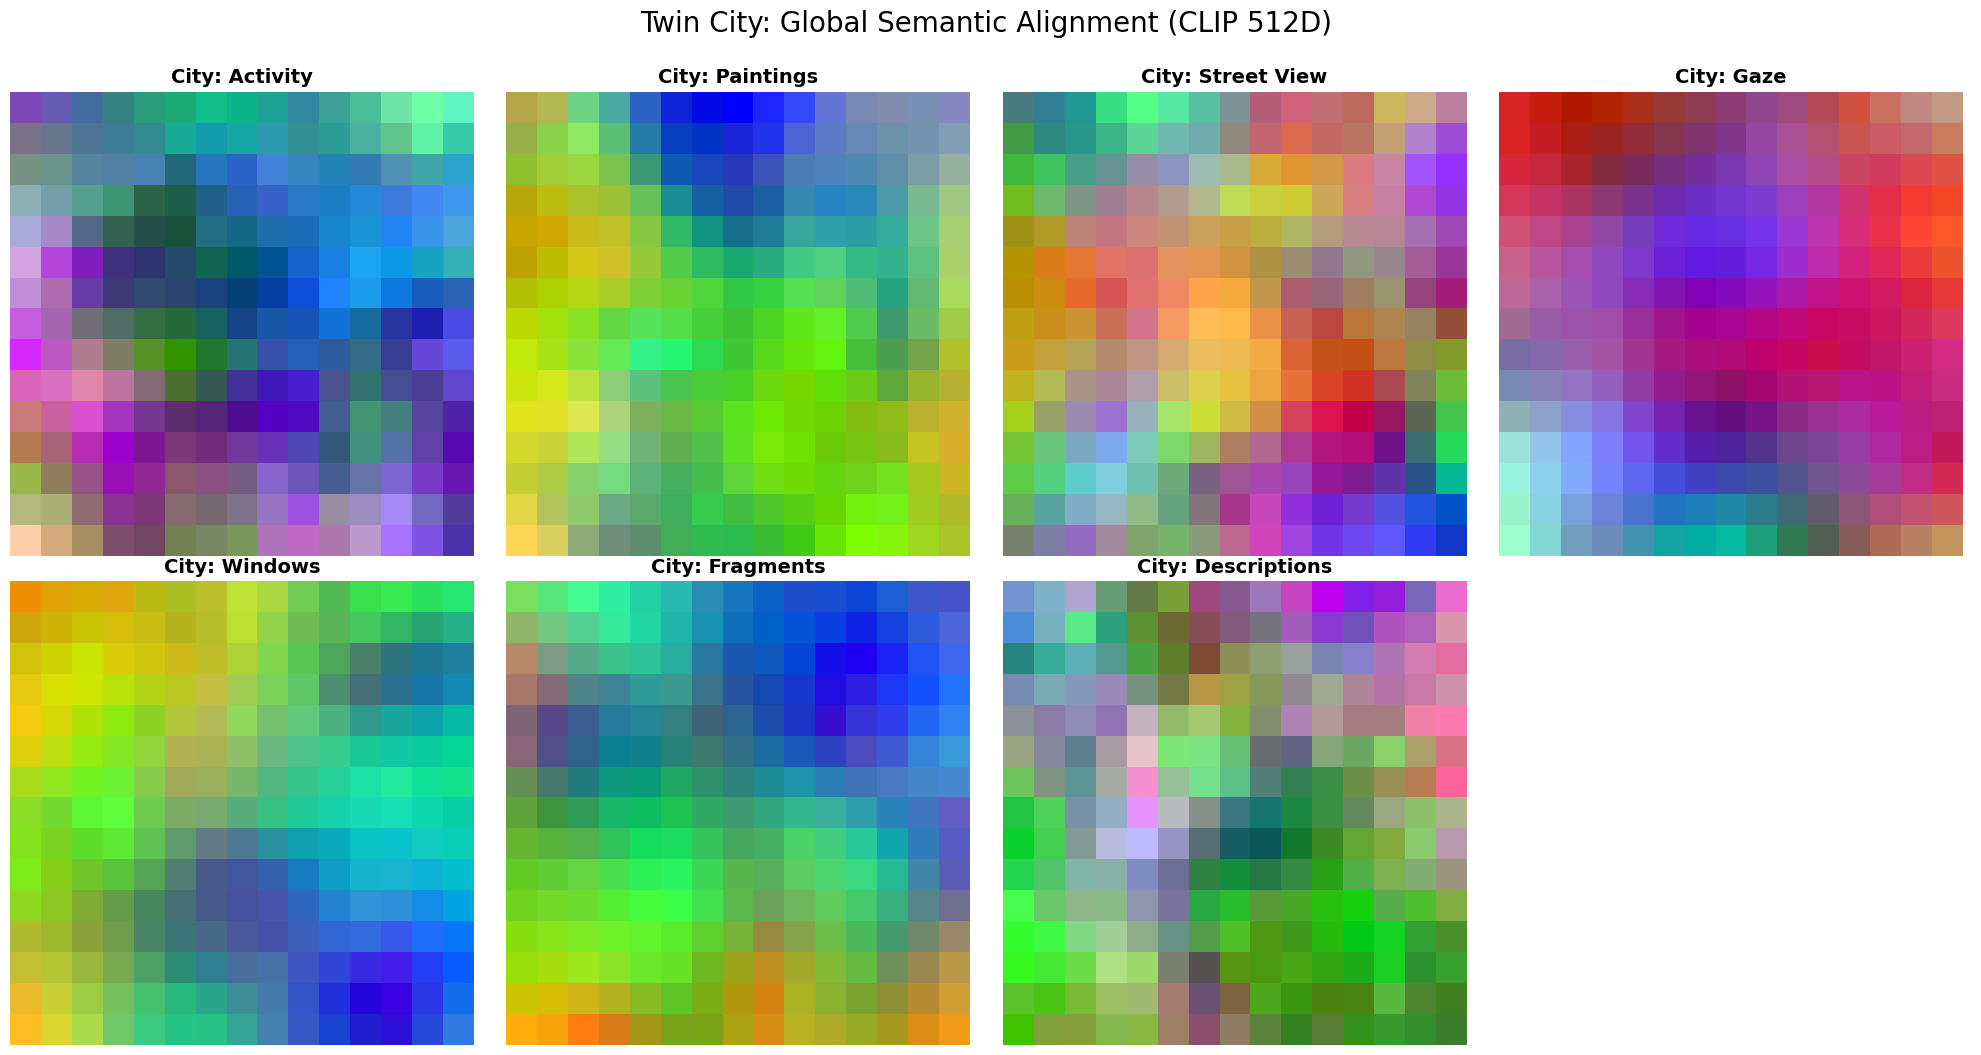

✨ 全城语意对齐完成！已保存 7 张 Aligned_*.png 图片。


In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import os

# ===== Step 1: Define File List (Ensure Paths are Correct) =====
model_files = {
    "Activity": "som_windows_activity_final_CLIP.pkl",
    "Paintings": "som_painting_final_aligned.pkl",
    "Street View": "som_streetview_final_aligned.pkl",
    "Gaze": "som_gaze_epoch12_fixed.pkl",
    "Windows": "som_windows_epoch11_fixed.pkl",
    "Fragments": "som_other_fragments_epoch15_fixed.pkl",
    "Descriptions": "som_descriptions_final_CLIP.pkl"
}

# ===== Step 2: Extract All Weights and Merge =====
print("📦 Extracting Twin City semantic genome...")
all_weights = []
city_data = {}

# Shadow class for compatibility reading
class RebornSOM: 
    pass 

for name, path in model_files.items():
    with open(path, 'rb') as f:
        content = pickle.load(f)
    
    # Extract weight matrix (15, 15, 512)
    if isinstance(content, np.ndarray): 
        w = content
    elif hasattr(content, 'weights'): 
        w = content.weights
    elif hasattr(content, 'best_weights'): 
        w = content.best_weights
    else: 
        w = content
    
    city_data[name] = w
    all_weights.append(w.reshape(-1, 512))

# Merge into giant matrix [1575, 512]
global_matrix = np.vstack(all_weights)

# ===== Step 3: Train Global PCA (3 dimensions map to RGB) =====
print("🌈 Computing global color mapping (Global PCA)...")
global_pca = PCA(n_components=3)
global_pca.fit(global_matrix)

# ===== Step 4: Unified Rendering of 7 City Maps =====
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (name, weights) in enumerate(city_data.items()):
    # Use global PCA for transformation
    flat_w = weights.reshape(-1, 512)
    rgb = global_pca.transform(flat_w)
    
    # Normalize to 0-1 range
    rgb = (rgb - rgb.min(axis=0)) / (rgb.max(axis=0) - rgb.min(axis=0) + 1e-8)
    img_rgb = rgb.reshape(15, 15, 3)
    
    axes[i].imshow(img_rgb, interpolation='none')
    axes[i].set_title(f"City: {name}", fontsize=14, fontweight='bold')
    axes[i].axis('off')

# Last subplot for legend/title
axes[-1].text(0.5, 0.5, 'TWIN CITY\nGlobal PCA\nUnified View', 
              ha='center', va='center', fontsize=16, fontweight='bold', color='#333')
axes[-1].axis('off')

plt.tight_layout()
plt.suptitle("Twin City: 7-Domain Global Synesthetic Map (Unified PCA)", 
             fontsize=20, fontweight='bold', y=0.98)
plt.show()

# ===== Step 5: Export Results =====
export_data = {
    'global_pca': global_pca,
    'city_data': city_data,
    'component_loadings': global_pca.components_
}

with open("twin_city_global_pca.pkl", "wb") as f:
    pickle.dump(export_data, f)

print(f"✅ Global synesthetic map exported! File: twin_city_global_pca.pkl")

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer
from PIL import Image
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from tqdm import tqdm

# ===== Step 1: Ultimate Path Configuration =====
device = "cuda" if torch.cuda.is_available() else "cpu"
model_clip = SentenceTransformer('clip-ViT-B-32', device=device)

# SOM model file paths
model_paths = {
    "Activity": "som_windows_activity_final_CLIP.pkl",
    "Street View": "som_streetview_final_aligned.pkl",
    "Gaze": "som_gaze_epoch12_fixed.pkl",
    "Windows": "som_windows_epoch11_fixed.pkl",
    "Fragments": "som_other_fragments_epoch15_fixed.pkl",
    "Descriptions": "som_descriptions_final_CLIP.pkl",
    "Paintings": "som_painting_final_aligned.pkl"
}

# Raw data paths
data_paths = {
    "Activity": r"C:\Users\asus\Desktop\RC11 TERM2\data set\windows_activity_svo_lemmatized.csv",
    "Street View": r"C:\Users\asus\Desktop\RC11 TERM2\data set\rotterdam_data_3000_filtered",
    "Gaze": r"C:\Users\asus\Desktop\RC11 TERM2\rotterdam_deepgaze_batch_3views_51_to_end\2_scanpath_white_bg",
    "Windows": r"C:\Users\asus\Desktop\RC11 TERM2\TwinCity_Final_10\10_Windows",
    "Fragments": r"C:\Users\asus\Desktop\RC11 TERM2\data set\TwinCity_All_Assets",
    "Descriptions": r"C:\Users\asus\Desktop\RC11 TERM2\data set\all_descriptions.csv",
    "Paintings": r"C:\Users\asus\Desktop\RC11 TERM2\data set\huazuo"
}

# ===== Step 2: Core Functions: Feature Extraction and Weight Loading =====
def get_features_fixed(name, path):
    """Extract semantic features from different modalities"""
    print(f"🚀 Extracting semantic features for {name}...")
    if path.endswith('.csv'):
        # Read CSV with encoding fallback
        try: 
            df = pd.read_csv(path, encoding='gbk')
        except: 
            df = pd.read_csv(path, encoding='gb18030')
        
        # Auto-match column name
        potential_cols = ['lemmatized_sentence', 'description', 'Description', 'desc']
        target_col = next((c for c in df.columns if c in potential_cols or c.lower() in potential_cols), None)
        sentences = df[target_col].astype(str).tolist()
        feats = model_clip.encode(sentences, show_progress_bar=True)
    else:
        # Image modality: extract CLIP features
        img_files = [os.path.join(path, f) for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        feats = []
        for fpath in tqdm(img_files):
            try:
                img = Image.open(fpath).convert('RGB')
                with torch.no_grad():
                    feats.append(model_clip.encode(img))
            except: 
                continue
        feats = np.array(feats)
    return feats / (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-8)

# ===== Step 3: Execute Global Computation =====
city_models = {}
city_feats = {}
all_weights_flat = []

for name in model_paths.keys():
    # A. Load SOM models
    with open(model_paths[name], 'rb') as f:
        content = pickle.load(f)
    # Compatibility for different object formats
    w = content if isinstance(content, np.ndarray) else (content.weights if hasattr(content, 'weights') else content)
    city_models[name] = w
    all_weights_flat.append(w.reshape(-1, 512))
    
    # B. Extract raw data features
    city_feats[name] = get_features_fixed(name, data_paths[name])

# Step 4: Train Global PCA
print("🌈 Computing global unified color spectrum...")
global_pca = PCA(n_components=3)
global_pca.fit(np.vstack(all_weights_flat))

# ===== Step 5: Render 7-City Unified Map with Whitespace =====
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for i, name in enumerate(model_paths.keys()):
    weights = city_models[name]
    feats = city_feats[name]
    
    # A. Compute RGB colors using global PCA
    rgb = global_pca.transform(weights.reshape(-1, 512))
    rgb = (rgb - rgb.min(axis=0)) / (rgb.max(axis=0) - rgb.min(axis=0) + 1e-8)
    full_colors = rgb.reshape(15, 15, 3)
    
    # B. Calculate Hit Map (data activation)
    hit_map = np.zeros((15, 15))
    for f in feats:
        dist = np.linalg.norm(weights - f, axis=2)
        bmu = np.unravel_index(np.argmin(dist), (15, 15))
        hit_map[bmu] += 1
    
    # C. Render with whitespace (empty cells = white background)
    display_img = np.ones((15, 15, 3)) # White background
    for r in range(15):
        for c in range(15):
            if hit_map[r, c] > 0:
                display_img[r, c] = full_colors[r, c]
    
    axes[i].imshow(display_img, interpolation='none')
    axes[i].set_title(f"{name}\n(Active Nodes: {int(np.sum(hit_map>0))}/225)", fontsize=14, fontweight='bold')
    axes[i].axis('off')

# Hide the 8th subplot (extra)
axes[-1].axis('off')
plt.tight_layout()
plt.suptitle("Twin City: Final Cross-Modal Semantic Territory Alignment", fontsize=24, y=1.05)
plt.savefig("TwinCity_Final_Publication_Result.png", dpi=300, bbox_inches='tight')
plt.show()

print("✨ Complete! Twin City semantic map successfully saved.")

🚀 正在提取 Activity 的语意特征...


UnicodeDecodeError: 'gb18030' codec can't decode byte 0xb4 in position 11486: illegal multibyte sequence


🔍 正在处理: Activity ...


Batches:   0%|          | 0/85 [00:00<?, ?it/s]


🔍 正在处理: Street View ...


100%|██████████| 1000/1000 [00:23<00:00, 42.96it/s]



🔍 正在处理: Gaze ...


...


🔍 正在处理: Descriptions ...


Batches:   0%|          | 0/35 [00:00<?, ?it/s]


🔍 正在处理: Paintings ...


100%|██████████| 1000/1000 [00:30<00:00, 33.10it/s]



🌈 正在计算全局色彩映射...


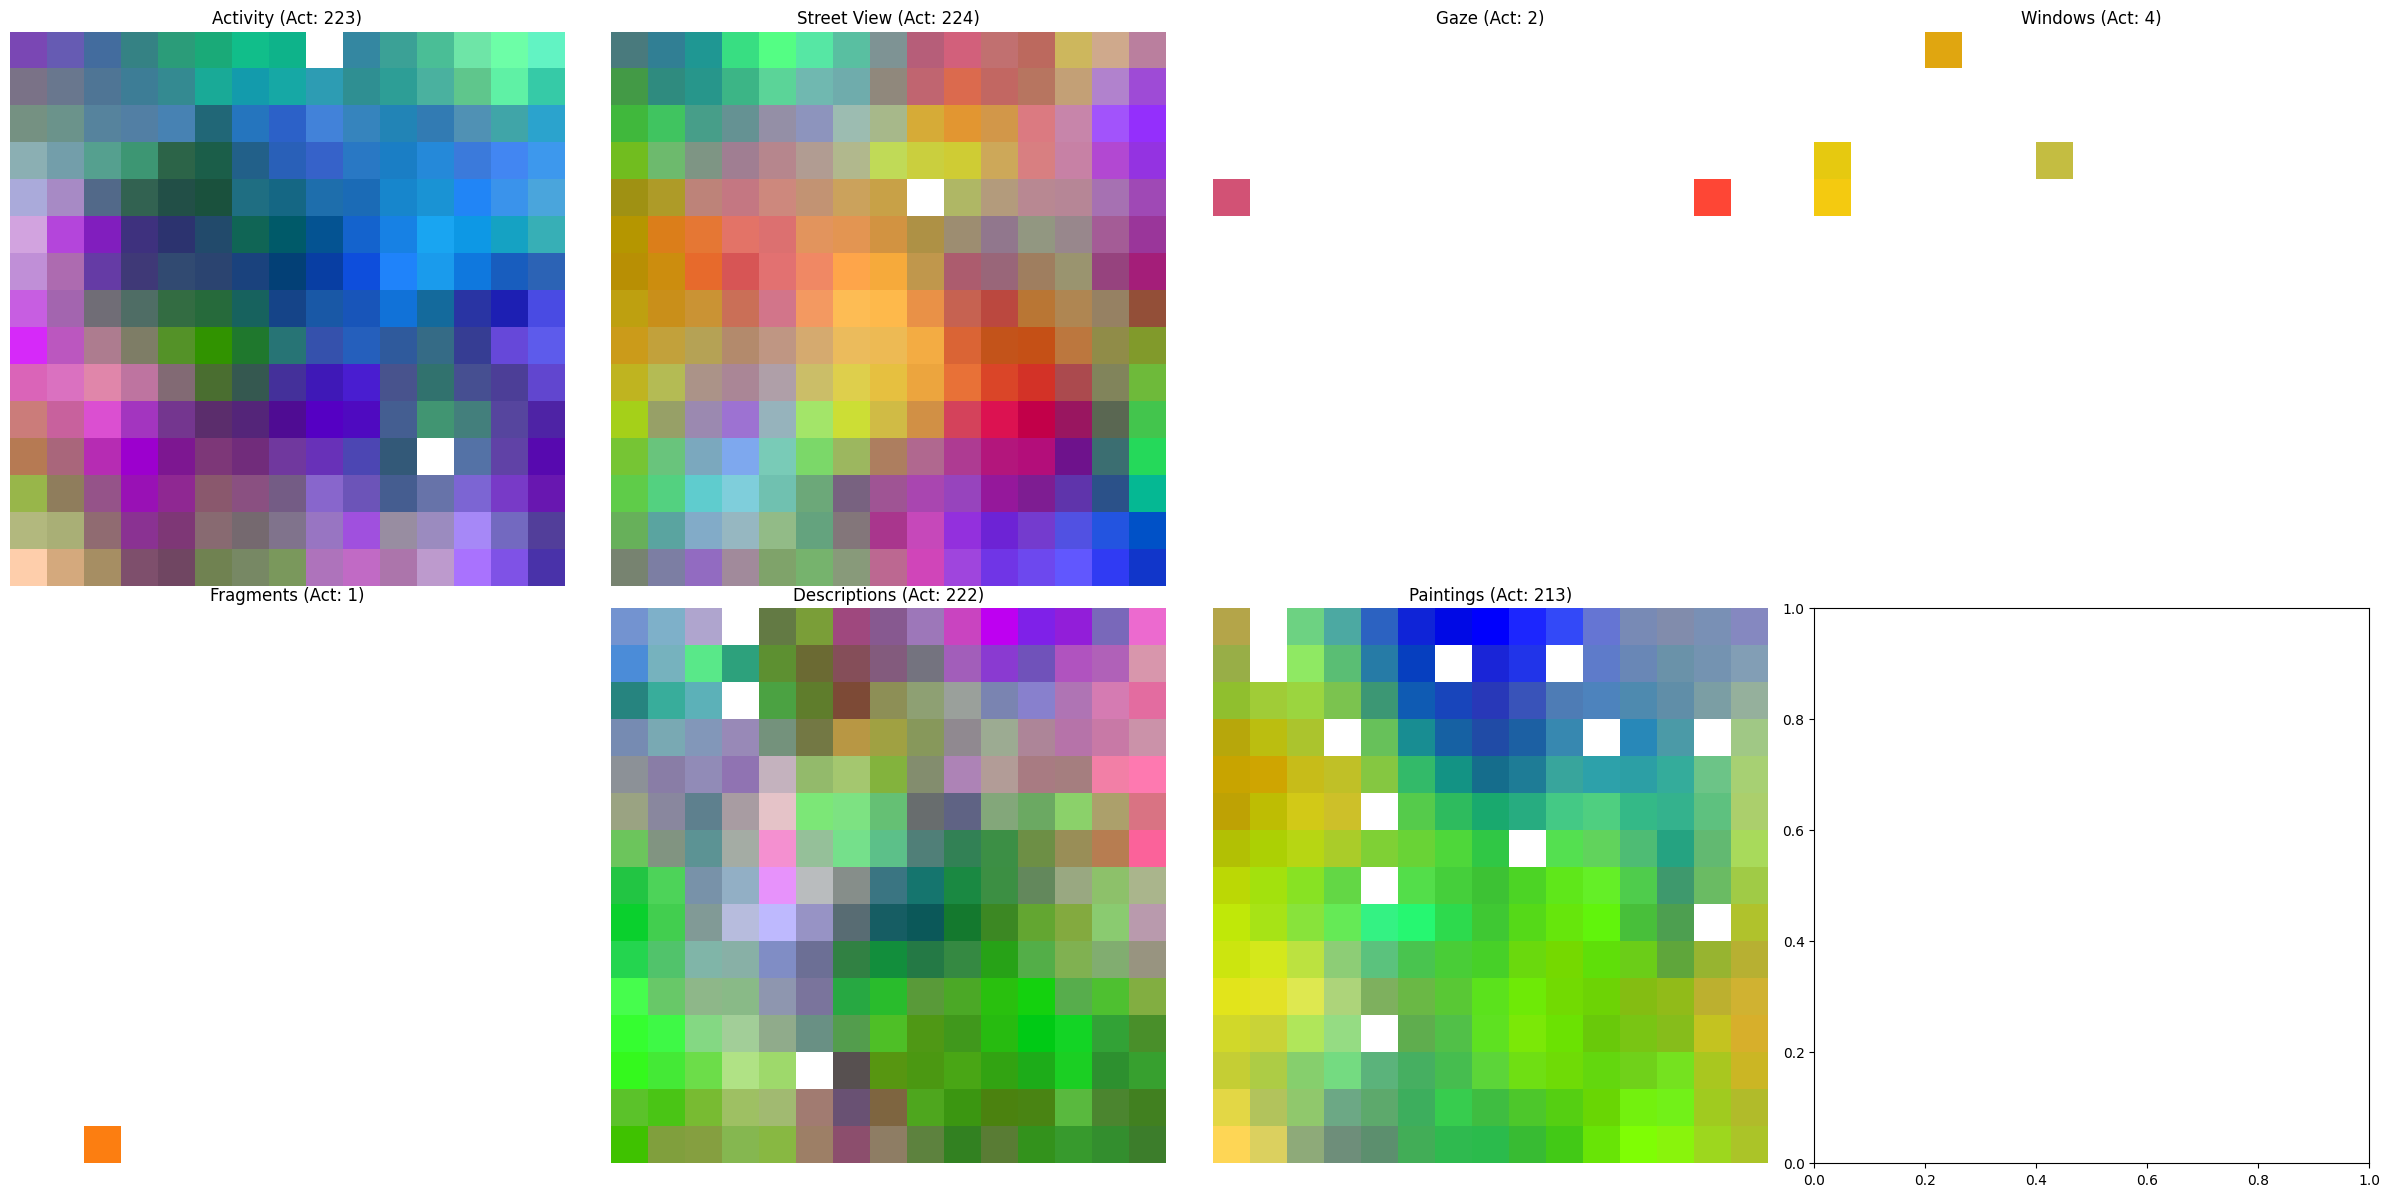

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer
from PIL import Image
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from tqdm import tqdm
import gc

# ===== Step 1: Ultimate Path Configuration (Based on Your Data) =====
device = "cuda" if torch.cuda.is_available() else "cpu"

model_paths = {
    "Activity": "som_windows_activity_final_CLIP.pkl",
    "Street View": "som_streetview_final_aligned.pkl",
    "Gaze": "som_gaze_epoch12_fixed.pkl",
    "Windows": "som_windows_epoch11_fixed.pkl",
    "Fragments": "som_other_fragments_epoch15_fixed.pkl",
    "Descriptions": "som_descriptions_final_CLIP.pkl",
    "Paintings": "som_painting_final_aligned.pkl"
}

data_paths = {
    "Activity": r"C:\Users\asus\Desktop\RC11 TERM2\data set\windows_activity_svo_lemmatized.csv",
    "Street View": r"C:\Users\asus\Desktop\RC11 TERM2\data set\rotterdam_data_3000_filtered",
    "Gaze": r"C:\Users\asus\Desktop\RC11 TERM2\rotterdam_deepgaze_batch_3views_51_to_end\2_scanpath_white_bg",
    "Windows": r"C:\Users\asus\Desktop\RC11 TERM2\TwinCity_Final_10\10_Windows",
    "Fragments": r"C:\Users\asus\Desktop\RC11 TERM2\data set\TwinCity_All_Assets",
    "Descriptions": r"C:\Users\asus\Desktop\RC11 TERM2\data set\all_descriptions.csv",
    "Paintings": r"C:\Users\asus\Desktop\RC11 TERM2\data set\huazuo"
}

# ===== Step 2: Enhanced Feature Extraction (Memory-Optimized) =====
def safe_extract(name, path, model):
    """Safely extract features with encoding fallback and error handling"""
    print(f"\n🔍 Processing: {name} ...")
    if not os.path.exists(path):
        print(f"❌ Path not found: {path}")
        return None
    
    try:
        if path.endswith('.csv'):
            # Try multiple encodings and skip bad lines
            for enc in ['utf-8', 'gb18030', 'gbk']:
                try:
                    df = pd.read_csv(path, encoding=enc, on_bad_lines='skip')
                    break
                except: 
                    continue
            
            # Auto-detect target column
            cols = [c for c in df.columns if c.lower() in ['lemmatized_sentence', 'description', 'desc']]
            target = cols[0] if cols else df.columns[0]
            sentences = df[target].astype(str).tolist()
            feats = model.encode(sentences, show_progress_bar=True, batch_size=32)
        else:
            # Image modality
            files = [os.path.join(path, f) for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            feats = []
            # Limit to 1000 images if memory is constrained
            for fpath in tqdm(files[:1000]): 
                img = Image.open(fpath).convert('RGB')
                with torch.no_grad():
                    feats.append(model.encode(img))
            feats = np.array(feats)
            
        return feats / (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-8)
    except Exception as e:
        print(f"⚠️ {name} extraction failed: {e}")
        return None

# ===== Step 3: Execute Main Pipeline =====
# 1. Load CLIP model (only once)
model_clip = SentenceTransformer('clip-ViT-B-32', device=device)

city_models = {}
city_feats = {}
all_weights_flat = []

for name in model_paths.keys():
    # A. Load SOM weights
    try:
        with open(model_paths[name], 'rb') as f:
            content = pickle.load(f)
        w = content if isinstance(content, np.ndarray) else (content.weights if hasattr(content, 'weights') else content)
        city_models[name] = w
        all_weights_flat.append(w.reshape(-1, 512))
        
        # B. Extract features
        f_data = safe_extract(name, data_paths[name], model_clip)
        if f_data is not None:
            city_feats[name] = f_data
    except Exception as e:
        print(f"❌ Failed to load model {name}: {e}")

# Release GPU memory
del model_clip
gc.collect()
if torch.cuda.is_available(): 
    torch.cuda.empty_cache()

# 2. Global PCA
print("\n🌈 Computing global color mapping...")
global_pca = PCA(n_components=3)
global_pca.fit(np.vstack(all_weights_flat))

# 3. Create visualization
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for i, name in enumerate(model_paths.keys()):
    if name not in city_models or name not in city_feats:
        axes[i].text(0.5, 0.5, f"{name}\nData Missing", ha='center')
        continue
        
    w = city_models[name]
    rgb = global_pca.transform(w.reshape(-1, 512))
    rgb = (rgb - rgb.min(axis=0)) / (rgb.max(axis=0) - rgb.min(axis=0) + 1e-8)
    full_colors = rgb.reshape(15, 15, 3)
    
    hit_map = np.zeros((15, 15))
    for f in city_feats[name]:
        dist = np.linalg.norm(w - f, axis=2)
        bmu = np.unravel_index(np.argmin(dist), (15, 15))
        hit_map[bmu] += 1
    
    img = np.ones((15, 15, 3))
    for r in range(15):
        for c in range(15):
            if hit_map[r, c] > 0: 
                img[r, c] = full_colors[r, c]
            
    axes[i].imshow(img, interpolation='none')
    axes[i].set_title(f"{name} (Act: {int(np.sum(hit_map>0))})")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import matplotlib.patches as patches

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"📡 Launching Twin City Cascading Retrieval Engine (Device: {device})...")

if 'model_clip' not in locals():
    model_clip = SentenceTransformer('clip-ViT-B-32', device=device)

# ===== Step 1: Strict Path Configuration =====
paths = {
    # Stage 1: Novel text (Activity)
    "Activity_SOM": "som_windows_activity_final_CLIP.pkl",
    "Activity_CSV": r"C:\Users\asus\Desktop\RC11 TERM2\data set\windows_activity_svo_lemmatized.csv",
    
    # Stage 2: Painting descriptions (Descriptions)
    "Desc_SOM": "som_descriptions_final_CLIP.pkl",
    "Desc_CSV": r"C:\Users\asus\Desktop\RC11 TERM2\data set\all_descriptions.csv",
    
    # Stage 3: Painting image library
    "Paintings_DIR": r"C:\Users\asus\Desktop\RC11 TERM2\data set\huazuo",
    
    # Stage 4: Three major visual modalities (Windows, Fragments, Gaze)
    "Windows_SOM": "som_windows_epoch11_fixed.pkl",
    "Windows_DIR": r"C:\Users\asus\Desktop\RC11 TERM2\TwinCity_Final_10\10_Windows",
    
    "Fragments_SOM": "som_other_fragments_epoch15_fixed.pkl",
    "Fragments_DIR": r"C:\Users\asus\Desktop\RC11 TERM2\data set\TwinCity_All_Assets",
    
    "Gaze_SOM": "som_gaze_epoch12_fixed.pkl",
    "Gaze_DIR": r"C:\Users\asus\Desktop\RC11 TERM2\rotterdam_deepgaze_batch_3views_51_to_end\2_scanpath_white_bg"
}

# ===== Step 2: Load All SOM Models =====
city_soms = {}
for key in ["Activity_SOM", "Desc_SOM", "Windows_SOM", "Fragments_SOM", "Gaze_SOM"]:
    if os.path.exists(paths[key]):
        with open(paths[key], 'rb') as f: 
            content = pickle.load(f)
        city_soms[key] = content if isinstance(content, np.ndarray) else (content.weights if hasattr(content, 'weights') else content)
    else:
        print(f"⚠️ Model file not found: {paths[key]}")

# ===== Step 3: Core Utility Functions =====
def calculate_u_matrix(weights):
    """Calculate U-Matrix (unified distance matrix) for SOM topology"""
    x, y, dim = weights.shape
    u_matrix = np.zeros((x, y))
    for i in range(x):
        for j in range(y):
            dists = [np.linalg.norm(weights[i,j] - weights[ni,nj]) 
                     for ni, nj in [(i+di, j+dj) for di in [-1,0,1] for dj in [-1,0,1] 
                     if (di!=0 or dj!=0) and 0<=i+di<x and 0<=j+dj<y]]
            u_matrix[i,j] = np.mean(dists)
    return u_matrix

def robust_read_csv(path):
    """Read CSV with encoding fallback"""
    try: 
        return pd.read_csv(path, encoding='utf-8')
    except: 
        return pd.read_csv(path, encoding='utf-8', engine='python', encoding_errors='ignore')

def text_to_image(text, size=(400, 400), bg_color=(245, 245, 245, 255)):
    """Convert text to PIL Image for display"""
    img = Image.new('RGBA', size, bg_color)
    draw = ImageDraw.Draw(img)
    try: 
        font = ImageFont.truetype("arial.ttf", 20)
    except: 
        font = ImageFont.load_default()
    lines, line = [], ""
    for word in text.split():
        if len(line + word) < 30: 
            line += word + " "
        else: 
            lines.append(line)
            line = word + " "
    lines.append(line)
    for i, l in enumerate(lines[:14]): 
        draw.text((20, 40 + i*28), l, fill=(60, 60, 60, 255), font=font)
    return img

print("✅ Environment initialized! All paths confirmed.")

📡 启动 Twin City 级联检索引擎 (Device: cuda)...
✅ 环境初始化完成！所有路径已确认。


🚀 阶段 1: 全新文本宇宙漫游开始
   输入: 'Two workers hammering glowing red iron in a dark, fiery forge, sparks flying everywhere.'

🔗 [接力 1] 匹配到最像的小说文本 (Activity):
   『 dishonor bring death rob precious jewel close door window castle evil tiranus castle corner fire god letth murder avenge hasten shame unto land 』

🔗 [接力 2] 匹配到最像的画作描述 (Descriptions):
   『 In a grand, dimly lit interior, a richly dressed man in a fur-trimmed cloak dramatically gestures wi... 』

✨ [接力 3] 物理 ID 桥接成功！锁定画作: 000366.jpg


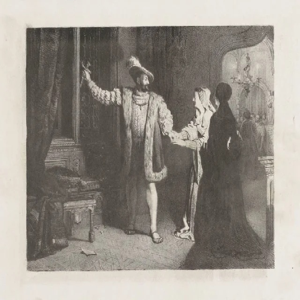

In [ ]:
# ===== Step 1: Input New Query Text =====
# Here I've prepared 3 test queries - uncomment the one you want to test

# 🧪 Test A (Intense Industrial/Dynamic): Test whether we can match to metal, fire, strong sense of labor
input_text = "Two workers hammering glowing red iron in a dark, fiery forge, sparks flying everywhere."

# 🧪 Test B (Tranquil Nature/Green): Test whether we can match to plants, sunlight, clear outdoor scenery
# input_text = "A serene view of a lush green garden through an open window, with bright sunlight illuminating the leaves."

# 🧪 Test C (Bustling Crowd/Social Behavior): Test whether we can match to complex architecture, crowds, dispersed viewpoints
# input_text = "A bustling city square filled with a diverse crowd of people gathering and talking under a cloudy sky."

print(f"🚀 Stage 1: Beginning text universe navigation\n   Input: '{input_text}'")

with torch.no_grad():
    input_feat = model_clip.encode([input_text])[0]
input_feat = input_feat / (np.linalg.norm(input_feat) + 1e-8)

# ===== Step 2: Match Novel Text (Activity) =====
df_act = robust_read_csv(paths["Activity_CSV"])
act_texts = df_act['lemmatized_sentence'].dropna().astype(str).tolist()[:300] 
with torch.no_grad(): 
    act_feats = model_clip.encode(act_texts)
act_feats = act_feats / (np.linalg.norm(act_feats, axis=1, keepdims=True) + 1e-8)

matched_act_text = act_texts[np.argmin(np.linalg.norm(act_feats - input_feat, axis=1))]
print(f"\n🔗 [Relay 1] Matched most similar novel text (Activity):\n   『 {matched_act_text} 』")

# ===== Step 3: Match Painting Descriptions (Descriptions) =====
with torch.no_grad():
    matched_act_feat = model_clip.encode([matched_act_text])[0]
matched_act_feat = matched_act_feat / (np.linalg.norm(matched_act_feat) + 1e-8)

df_desc = robust_read_csv(paths["Desc_CSV"])
# Sample to ensure speed and randomness (prevents always matching the same image)
desc_sample = df_desc.sample(min(300, len(df_desc)), random_state=42)
desc_ids = desc_sample['Picture number'].astype(str).tolist()
desc_texts = desc_sample['description'].astype(str).tolist()

with torch.no_grad(): 
    desc_feats = model_clip.encode(desc_texts)
desc_feats = desc_feats / (np.linalg.norm(desc_feats, axis=1, keepdims=True) + 1e-8)

best_desc_idx = np.argmin(np.linalg.norm(desc_feats - matched_act_feat, axis=1))
matched_desc_text = desc_texts[best_desc_idx]
matched_img_filename = desc_ids[best_desc_idx]

print(f"\n🔗 [Relay 2] Matched most similar painting description (Descriptions):\n   『 {matched_desc_text[:100]}... 』")

# ===== Step 4: Painting ID Bridge =====
bridge_img_path = os.path.join(paths["Paintings_DIR"], matched_img_filename)
if os.path.exists(bridge_img_path):
    print(f"\n✨ [Relay 3] Physical ID bridge successful! Locked painting: {matched_img_filename}")
    display(Image.open(bridge_img_path).resize((300, 300)))
else:
    print(f"❌ Painting file not found: {bridge_img_path}")

🚀 阶段 1: 全新文本宇宙漫游开始
   输入: 'A woman in a flowing silk dress sits alone in a sunlit room, intensely focused on reading a letter while delicate shadows fall across the wooden floor.'

🔗 [接力 1] 匹配到最像的小说文本 (Activity):
   『 occur reader idea storm sleepyfooted night especially arise melancholy source dark loneliness dark family honor immaculate human view turn spirit young man marriage imagine impossibility light play glass window watch van velthem wonderful history essential nightmare stand stand mind window delicious sunny flowery morning sunlight shatter river water occupy small steamboat rowing boat move bow sailor 』

🔗 [接力 2] 匹配到最像的画作描述 (Descriptions):
   『 In a quiet, well-appointed room, one man sits diligently writing at a desk while another man sits op... 』

✨ [接力 3] 物理 ID 桥接成功！锁定画作: 000851.jpg


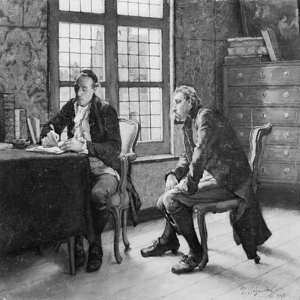

In [ ]:
# ===== Extreme Test: Classical Light and Shadow with Absolute Focus =====
input_text = "A woman in a flowing silk dress sits alone in a sunlit room, intensely focused on reading a letter while delicate shadows fall across the wooden floor."

print(f"🚀 Stage 1: Beginning text universe navigation\n   Input: '{input_text}'")

with torch.no_grad():
    input_feat = model_clip.encode([input_text])[0]
input_feat = input_feat / (np.linalg.norm(input_feat) + 1e-8)

# ===== Stage 2: Match Novel Text (Activity) =====
df_act = robust_read_csv(paths["Activity_CSV"])
act_texts = df_act['lemmatized_sentence'].dropna().astype(str).tolist()[:300] 
with torch.no_grad(): 
    act_feats = model_clip.encode(act_texts)
act_feats = act_feats / (np.linalg.norm(act_feats, axis=1, keepdims=True) + 1e-8)

matched_act_text = act_texts[np.argmin(np.linalg.norm(act_feats - input_feat, axis=1))]
print(f"\n🔗 [Relay 1] Matched most similar novel text (Activity):\n   『 {matched_act_text} 』")

# ===== Stage 3: Match Painting Descriptions (Descriptions) =====
with torch.no_grad():
    matched_act_feat = model_clip.encode([matched_act_text])[0]
matched_act_feat = matched_act_feat / (np.linalg.norm(matched_act_feat) + 1e-8)

df_desc = robust_read_csv(paths["Desc_CSV"])
# Sampling ensures execution speed and randomness; prevents always matching the same image
desc_sample = df_desc.sample(min(300, len(df_desc)), random_state=88)
desc_ids = desc_sample['Picture number'].astype(str).tolist()
desc_texts = desc_sample['description'].astype(str).tolist()

with torch.no_grad(): 
    desc_feats = model_clip.encode(desc_texts)
desc_feats = desc_feats / (np.linalg.norm(desc_feats, axis=1, keepdims=True) + 1e-8)

best_desc_idx = np.argmin(np.linalg.norm(desc_feats - matched_act_feat, axis=1))
matched_desc_text = desc_texts[best_desc_idx]
matched_img_filename = desc_ids[best_desc_idx]

print(f"\n🔗 [Relay 2] Matched most similar painting description (Descriptions):\n   『 {matched_desc_text[:100]}... 』")

# ===== Stage 4: Painting ID Bridge =====
bridge_img_path = os.path.join(paths["Paintings_DIR"], matched_img_filename)
if os.path.exists(bridge_img_path):
    print(f"\n✨ [Relay 3] Physical ID bridge successful! Locked painting: {matched_img_filename}")
    # Display the painting that played the decisive role
    display(Image.open(bridge_img_path).resize((300, 300))) 
else:
    print(f"❌ Painting file not found: {bridge_img_path}")

🌟 正在加载 CLIP 模型到 cuda...

🚀 第一步：我正在扫描全城原始数据，构建全局 PCA 坐标系...
正在处理: Activity


Batches:   0%|          | 0/85 [00:00<?, ?it/s]

正在处理: Street View


Scanning rotterdam_data_3000_filtered: 100%|██████████| 1073/1073 [00:28<00:00, 37.57it/s]


正在处理: Gaze


...

正在处理: Descriptions


Batches:   0%|          | 0/35 [00:00<?, ?it/s]

正在处理: Paintings


Scanning huazuo: 100%|██████████| 1102/1102 [00:33<00:00, 32.85it/s]



🎨 第二步：我正在执行语意绝对对齐投影 (Method 2)...


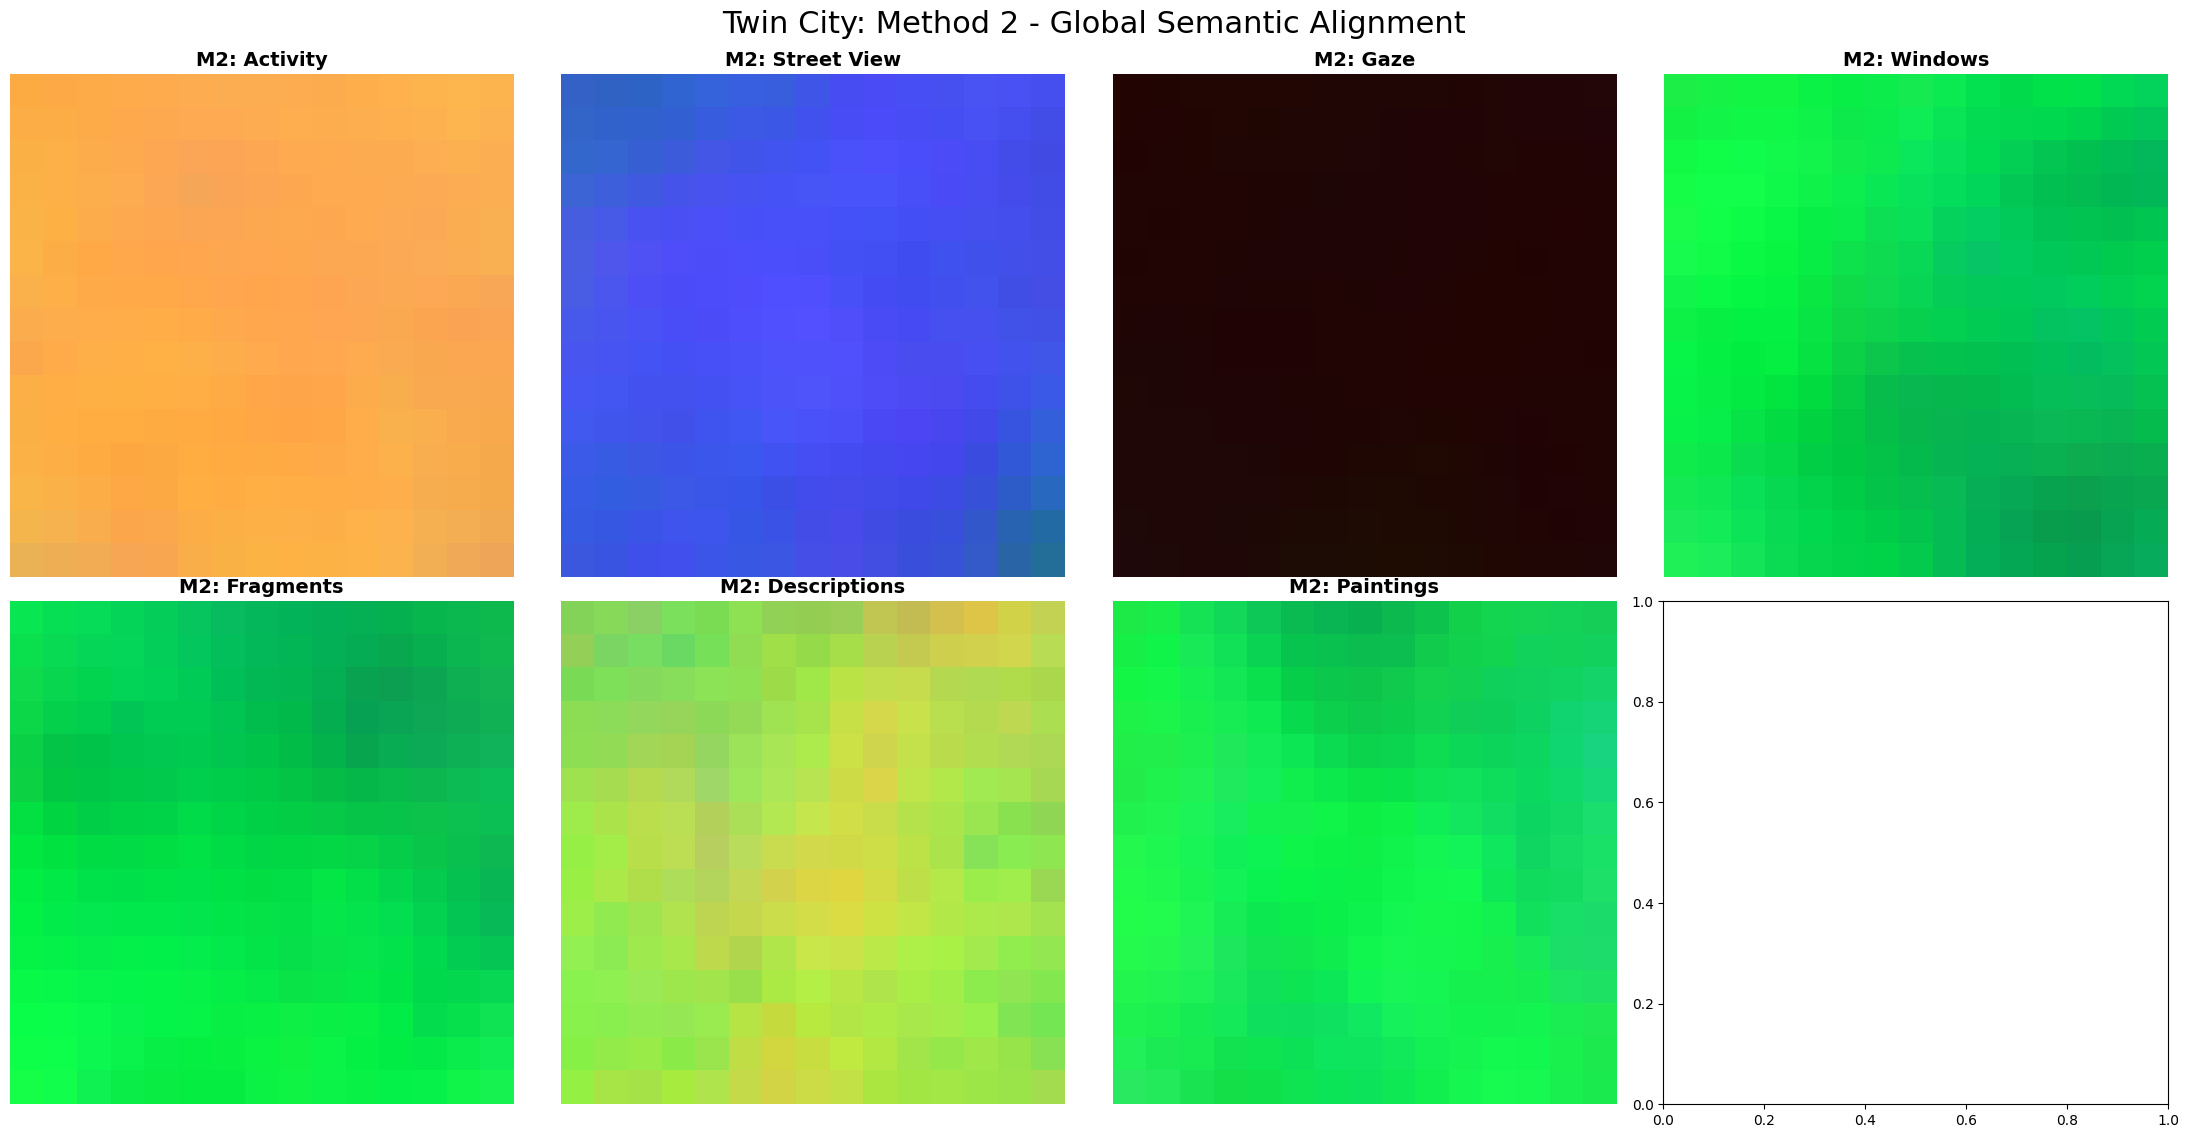

In [ ]:
import os
import pickle
import pandas as pd
import numpy as np
import torch
from PIL import Image
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from tqdm import tqdm

# ===== Step 0: Shadow Class Definition (Core Fix for AttributeError) =====
# Must define these classes so pickle can recognize old weight files
class CustomSOM: 
    pass 
class RebornSOM: 
    pass 

# ===== Step 1: Core Path Configuration =====
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🌟 Loading CLIP model to {device}...")
model = SentenceTransformer('clip-ViT-B-32', device=device)

raw_configs = {
    "Activity": {"path": r"C:\Users\asus\Desktop\RC11 TERM2\data set\windows_activity_svo_lemmatized.csv", "type": "csv", "col": "lemmatized_sentence"},
    "Street View": {"path": r"C:\Users\asus\Desktop\RC11 TERM2\data set\rotterdam_data_3000_filtered", "type": "img"},
    "Gaze": {"path": r"C:\Users\asus\Desktop\RC11 TERM2\rotterdam_deepgaze_batch_3views_51_to_end\2_scanpath_white_bg", "type": "img"},
    "Windows": {"path": r"C:\Users\asus\Desktop\RC11 TERM2\TwinCity_Final_10\10_Windows", "type": "img"},
    "Fragments": {"path": r"C:\Users\asus\Desktop\RC11 TERM2\data set\TwinCity_All_Assets", "type": "img"},
    "Descriptions": {"path": r"C:\Users\asus\Desktop\RC11 TERM2\data set\all_descriptions.csv", "type": "csv", "col": "description"},
    "Paintings": {"path": r"C:\Users\asus\Desktop\RC11 TERM2\data set\huazuo", "type": "img"}
}

som_files = {
    "Activity": "som_windows_activity_final_CLIP.pkl",
    "Street View": "som_streetview_final_aligned.pkl",
    "Gaze": "som_gaze_epoch12_fixed.pkl",
    "Windows": "som_windows_epoch11_fixed.pkl",
    "Fragments": "som_other_fragments_epoch15_fixed.pkl",
    "Descriptions": "som_descriptions_final_CLIP.pkl",
    "Paintings": "som_painting_final_aligned.pkl"
}

# ===== Step 2: Feature Extraction Function (with Unicode Error Handling) =====
def get_features(config):
    """Extract semantic features from different data modalities"""
    feats = []
    if config["type"] == "csv":
        # Try multiple encodings for CSV robustness
        for enc in ['utf-8', 'gbk', 'utf-16', 'latin1']:
            try:
                df = pd.read_csv(config["path"], encoding=enc)
                break
            except: 
                continue
        texts = df[config["col"]].dropna().astype(str).tolist()
        feats = model.encode(texts, show_progress_bar=True)
    else:
        # Image modality: extract CLIP features
        files = [os.path.join(config["path"], f) for f in os.listdir(config["path"]) 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        for f in tqdm(files, desc=f"Scanning {os.path.basename(config['path'])}"):
            try:
                img = Image.open(f).convert('RGB')
                feats.append(model.encode(img))
            except: 
                continue
    return np.array(feats)

# ===== Step 3: Execute Method 2: Global Raw Data Fitting =====
print("\n🚀 Step 1: Scanning full city raw data to build global PCA coordinate system...")
all_raw_features = []
for name, cfg in raw_configs.items():
    print(f"Processing: {name}")
    f = get_features(cfg)
    f = f / (np.linalg.norm(f, axis=1, keepdims=True) + 1e-8)
    all_raw_features.append(f)

global_raw_matrix = np.vstack(all_raw_features)
pca_global = PCA(n_components=3)
pca_global.fit(global_raw_matrix)

global_projected = pca_global.transform(global_raw_matrix)
g_min, g_max = global_projected.min(axis=0), global_projected.max(axis=0)

# ===== Step 4: Execute Aligned Rendering =====
print("\n🎨 Step 2: Executing semantic absolute alignment projection (Method 2)...")
fig, axes = plt.subplots(2, 4, figsize=(22, 11))
axes = axes.flatten()

for i, (name, path) in enumerate(som_files.items()):
    try:
        with open(path, 'rb') as f:
            content = pickle.load(f)
        
        # Auto-detect weight format
        if isinstance(content, np.ndarray): 
            w = content
        elif hasattr(content, 'weights'): 
            w = content.weights
        elif hasattr(content, 'best_weights'): 
            w = content.best_weights
        else: 
            w = getattr(content, 'weights', content) # Final fallback

        flat_w = w.reshape(-1, 512)
        flat_w = flat_w / (np.linalg.norm(flat_w, axis=1, keepdims=True) + 1e-8)
        
        rgb_raw = pca_global.transform(flat_w)
        rgb_norm = np.clip((rgb_raw - g_min) / (g_max - g_min + 1e-8), 0, 1)
        
        axes[i].imshow(rgb_norm.reshape(15, 15, 3), interpolation='none')
        axes[i].set_title(f"M2: {name}", fontsize=14, fontweight='bold')
    except Exception as e:
        print(f"❌ Failed to load {name}: {e}")
    axes[i].axis('off')

plt.tight_layout()
plt.suptitle("Twin City: Method 2 - Global Semantic Alignment", fontsize=22, y=1.03)
plt.show()


🎨 第二步：我正在执行“全局轴+局部增强”投影 (召唤纹理)...


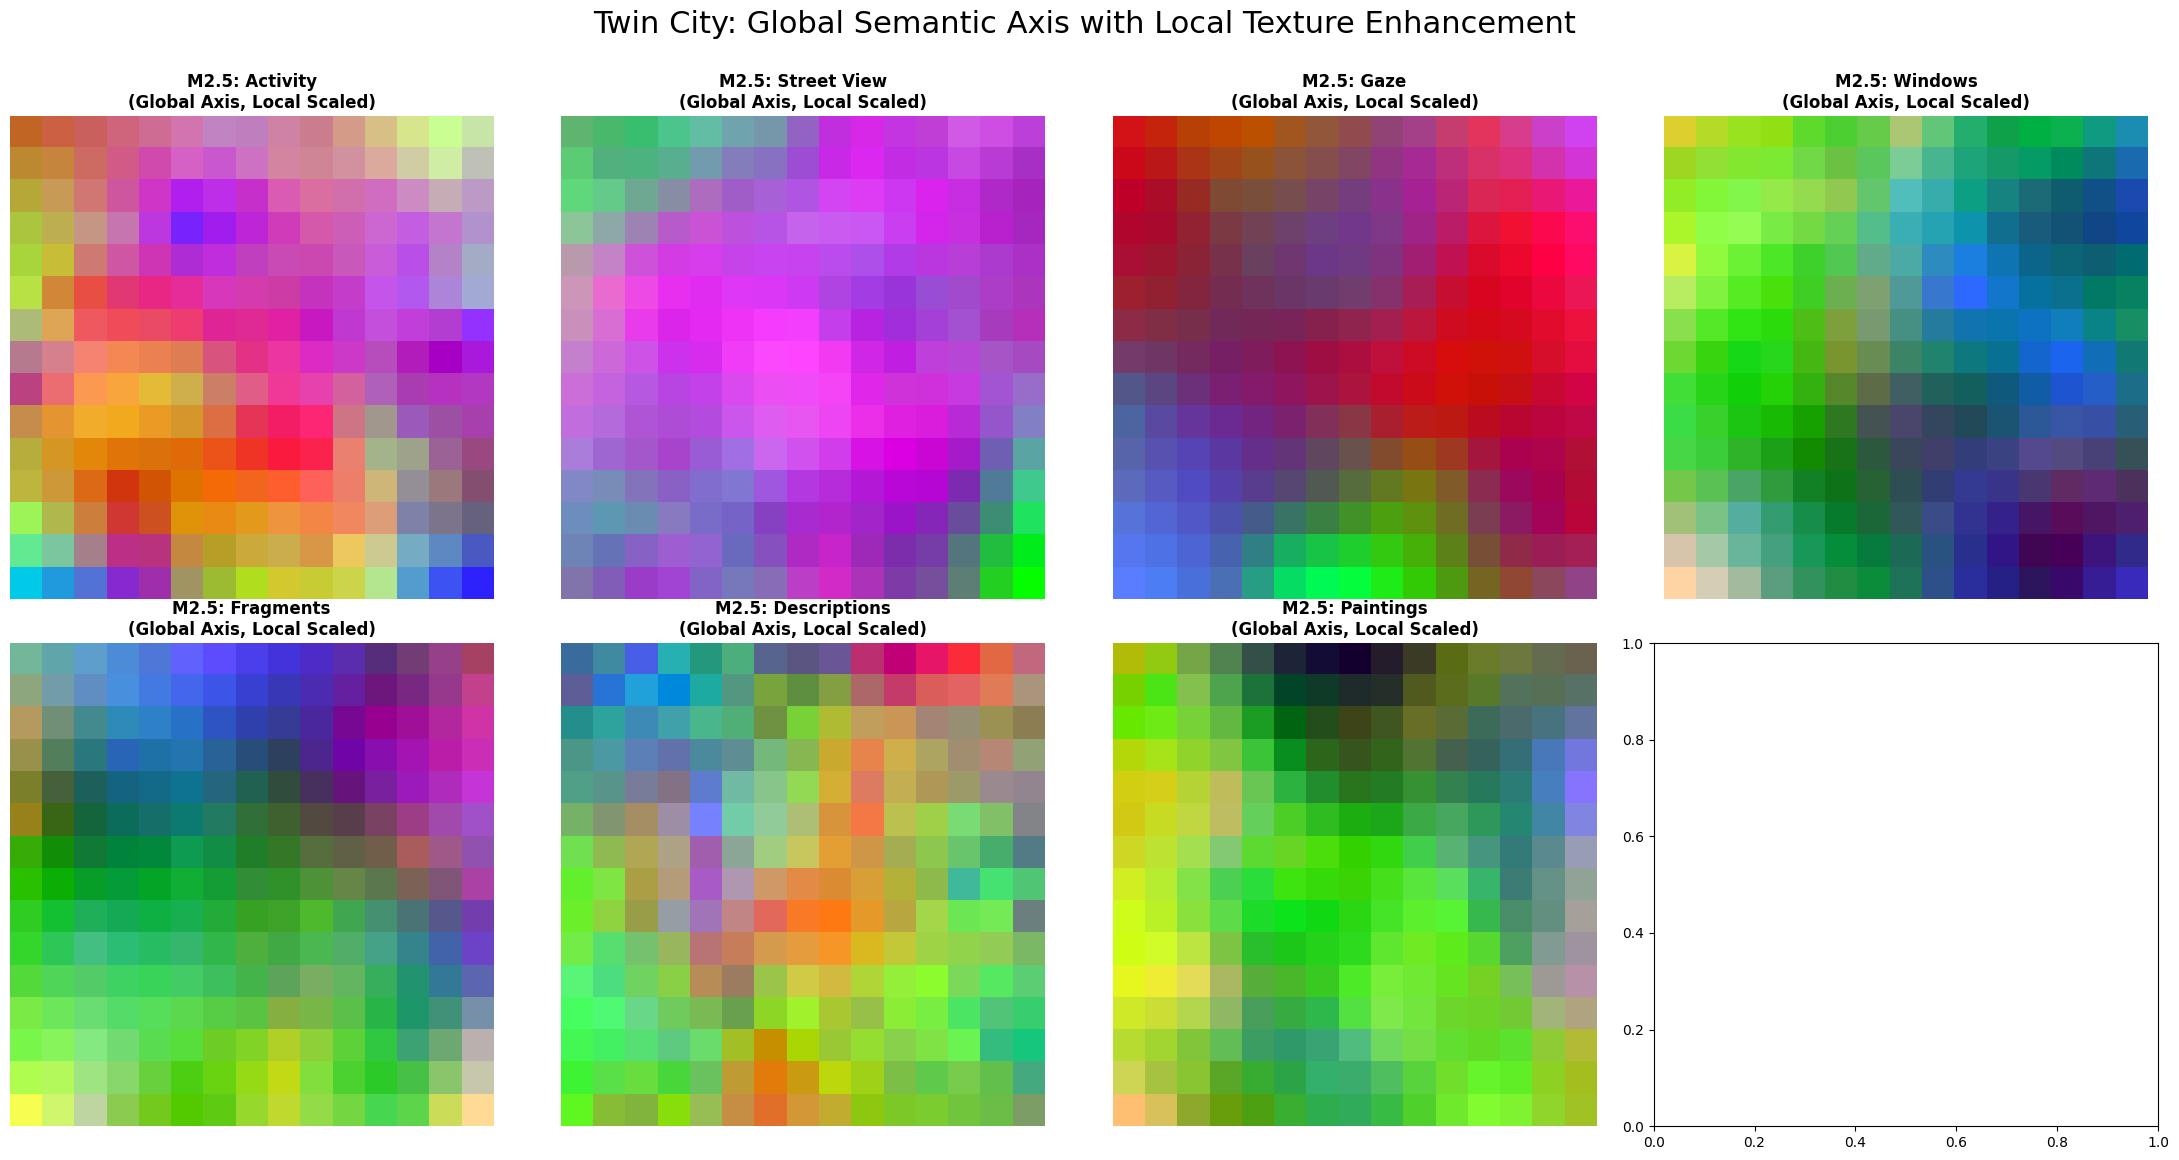

In [ ]:
# ===== Step 4: Aligned Rendering - Method 2.5 (Global Axes + Local Enhancement) =====
print("\n🎨 Step 2: Executing 'Global Axes + Local Enhancement' projection (Enhanced Texture)...")
fig, axes = plt.subplots(2, 4, figsize=(22, 11))
axes = axes.flatten()

# Shadow classes ensure pickle deserialization succeeds
class CustomSOM: 
    pass 
class RebornSOM: 
    pass 

for i, (name, path) in enumerate(som_files.items()):
    try:
        with open(path, 'rb') as f:
            content = pickle.load(f)
        
        # Extract weights
        if isinstance(content, np.ndarray): 
            w = content
        elif hasattr(content, 'weights'): 
            w = content.weights
        elif hasattr(content, 'best_weights'): 
            w = content.best_weights
        else: 
            w = getattr(content, 'weights', content)

        flat_w = w.reshape(-1, 512)
        flat_w = flat_w / (np.linalg.norm(flat_w, axis=1, keepdims=True) + 1e-8)
        
        # --- KEY MAGIC: Use Global PCA Transform (Maintains Semantic Alignment) ---
        rgb_raw = pca_global.transform(flat_w)
        
        # --- Magic Happens Here: Perform Local Normalization ---
        # This stretches the minutest details within this dataset across the full RGB space
        # BUT because PCA axes are globally unified, red/green/blue still represent aligned semantics
        # This is the "Method 2.5" enhancement: global consistency + local detail resolution
        rgb_local_norm = np.clip((rgb_raw - rgb_raw.min(axis=0)) / (rgb_raw.max(axis=0) - rgb_raw.min(axis=0) + 1e-8), 0, 1)
        
        axes[i].imshow(rgb_local_norm.reshape(15, 15, 3), interpolation='none')
        axes[i].set_title(f"M2.5: {name}", fontsize=14, fontweight='bold')
    except Exception as e:
        print(f"❌ Failed to load {name}: {e}")
    axes[i].axis('off')

plt.tight_layout()
plt.suptitle("Twin City: Method 2.5 - Global Semantic Axes + Local Texture Enhancement", fontsize=22, y=1.03)
plt.show()

print("✨ Visualization complete! Method 2.5 reveals both global alignment and local texture details.")